# 23. Real-Time Macro & Monetary Policy Nowcasting

In [1]:
from functools import lru_cache
from itertools import permutations, product
from pathlib import Path
import re

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from cycler import cycler
from IPython.display import display
from matplotlib.colors import ListedColormap
from scipy.optimize import minimize
from scipy.stats import norm, wasserstein_distance
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.dynamic_factor_mq import DynamicFactorMQ

from quantfinlab.dataio.macro import macro_availability_table
from quantfinlab.fixed_income import load_par_yields_csv
from quantfinlab.macro.indicators import expanding_zscore
from quantfinlab.macro.indicators import expanding_zscore
from quantfinlab.macro.indicators import expanding_zscore
from quantfinlab.macro.indicators import expanding_zscore
from quantfinlab.macro.indicators import expanding_zscore
from quantfinlab.ml.evaluation import forecast_metrics
from quantfinlab.ml.probabilistic import gaussian_nll, interval_coverage, interval_width

pd.set_option("display.max_columns", 24)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
palette = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
           "#9614fa", "#DC143C", "#7BC8F6", "#0072B2", "#04D8B2",
           "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({"figure.figsize": (6, 3), "figure.dpi": 200, "savefig.dpi": 300,
                     "axes.grid": True, "grid.alpha": 0.20, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titlesize": 12,
                     "axes.labelsize": 12, "xtick.labelsize": 9,
                     "ytick.labelsize": 9, "legend.fontsize": 7})
rng = np.random.default_rng(23)

In [2]:
ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data"

FRED_PATH = DATA / "fred_md_qd_vintages.parquet"
ALFRED_PATH = DATA / "alfred_realtime.parquet"
ALFRED_CATALOG_PATH = DATA / "alfred_series_catalog.parquet"
PHILLY_VINTAGE_PATH = DATA / "philly_realtime_vintages.parquet"
PHILLY_RELEASE_PATH = DATA / "philly_first_second_third.parquet"
GDPNOW_FORECAST_PATH = DATA / "gdpnow_forecasts.parquet"
GDPNOW_CONTRIBUTION_PATH = DATA / "gdpnow_contributions.parquet"
GDPNOW_TRACK_PATH = DATA / "gdpnow_track_record.parquet"
GDPNOW_CALENDAR_PATH = DATA / "gdpnow_release_dates.parquet"
SPF_PATH = DATA / "spf_forecasts.parquet"
MPT_PATH = DATA / "atlanta_mpt.parquet"
HIGH_FREQUENCY_PATH = DATA / "macro_high_frequency.parquet"
TREASURY_PATH = DATA / "us_treasury_yields.csv"

required = [FRED_PATH, ALFRED_PATH, ALFRED_CATALOG_PATH, PHILLY_VINTAGE_PATH,
            PHILLY_RELEASE_PATH, GDPNOW_FORECAST_PATH, GDPNOW_CONTRIBUTION_PATH,
            GDPNOW_TRACK_PATH, GDPNOW_CALENDAR_PATH, SPF_PATH, MPT_PATH,
            HIGH_FREQUENCY_PATH, TREASURY_PATH]
assert all(path.exists() for path in required)

TRAIN_START = pd.Timestamp("2003-01-01")
SCORE_START = pd.Timestamp("2014-07-01")
GDP_DAYS = (60, 45, 30, 15, 7, 1)
MONTHLY_DAYS = (20, 10, 5, 1)
TARGETS = ("real_gdp", "headline_cpi", "core_cpi", "headline_pce",
           "core_pce", "payroll", "unemployment")

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")
con.execute(f"CREATE VIEW fred_vintages AS SELECT * FROM read_parquet('{FRED_PATH.as_posix()}')")
fred_file = pq.ParquetFile(FRED_PATH)
fred_series_ids = tuple(row[0] for row in con.execute(
    "SELECT DISTINCT series_id FROM fred_vintages ORDER BY series_id").fetchall())
representative_fred = con.execute("""
    SELECT panel, vintage_date, observation_date, series_id, value, transformation
    FROM fred_vintages
    WHERE vintage_date = (SELECT max(vintage_date) FROM fred_vintages)
      AND series_id IN ('INDPRO', 'PAYEMS', 'CPIAUCSL', 'FEDFUNDS')
    QUALIFY row_number() OVER (PARTITION BY panel, series_id ORDER BY observation_date DESC) <= 2
    ORDER BY panel, series_id, observation_date
""").fetchdf()

fred_setup = pd.DataFrame({
    "value": [fred_file.metadata.num_rows, fred_file.num_row_groups,
              len(fred_series_ids), min(GDP_DAYS), max(GDP_DAYS), SCORE_START.date()]},
    index=["Parquet rows", "Parquet row groups", "Unique source series",
           "Nearest GDP horizon (business days)", "Earliest GDP horizon (business days)",
           "Primary pseudo-OOS start"])
display(fred_setup, representative_fred)

,value
Parquet rows,31986747
Parquet row groups,423
Unique source series,305
Nearest GDP horizon (business days),1
Earliest GDP horizon (business days),60
Primary pseudo-OOS start,2014-07-01


,panel,vintage_date,observation_date,series_id,value,transformation
0,MD,2026-07-01,2026-05-01,CPIAUCSL,333.9790,6
1,MD,2026-07-01,2026-06-01,CPIAUCSL,332.5680,6
2,MD,2026-07-01,2026-05-01,FEDFUNDS,3.6300,2
3,MD,2026-07-01,2026-06-01,FEDFUNDS,3.6300,2
4,MD,2026-07-01,2026-05-01,INDPRO,102.5606,5
5,MD,2026-07-01,2026-06-01,INDPRO,102.6395,5
6,MD,2026-07-01,2026-05-01,PAYEMS,"158,927.0000",5
7,MD,2026-07-01,2026-06-01,PAYEMS,"158,984.0000",5
8,QD,2026-07-01,2026-03-01,CPIAUCSL,328.1137,6
9,QD,2026-07-01,2026-06-01,CPIAUCSL,332.9847,6


In [3]:
activity_ids = {"RPI", "W875RX1", "CMRMTSPLx", "RETAILx", "INDPRO", "CUMFNS",
                "IPFPNSS", "IPFINAL", "IPCONGD", "IPDCONGD", "IPNCONGD", "IPBUSEQ",
                "IPMAT", "IPDMAT", "IPNMAT", "IPMANSICS", "IPB51222S", "SRVPRD"}
labor_ids = {"PAYEMS", "CE16OV", "CLF16OV", "UNRATE", "UEMPMEAN", "UEMPLT5",
             "UEMP5TO14", "UEMP15T26", "UEMP27OV", "UEMP15OV", "CLAIMSx", "HWI",
             "HWIURATIO", "AWHMAN", "AWOTMAN", "MANEMP", "DMANEMP", "NDMANEMP",
             "USGOOD", "USCONS", "USTPU", "USTRADE", "USWTRADE", "USFIRE", "USGOVT"}
housing_ids = {"HOUST", "HOUSTNE", "HOUSTMW", "HOUSTS", "HOUSTW", "PERMIT",
               "PERMITNE", "PERMITMW", "PERMITS", "PERMITW"}
spending_ids = {"ACOGNO", "AMDMNOx", "ANDENOx", "AMDMUOx", "BUSINVx", "ISRATIOx",
                "DPCERA3M086SBEA", "CMRMTSPLx", "RETAILx"}
price_ids = {"CPIAUCSL", "CPIULFSL", "CPIAPPSL", "CPITRNSL", "CPIMEDSL",
             "CUSR0000SA0L2", "CUSR0000SA0L5", "CUSR0000SAC", "CUSR0000SAD",
             "CUSR0000SAS", "PCEPI", "PPICMM", "WPSFD49207", "WPSFD49502",
             "WPSID61", "WPSID62", "OILPRICEx"}

def fred_family(series_id):
    name = str(series_id)
    if name in activity_ids or name.startswith("IP"):
        return "Output and activity"
    if name in labor_ids or name.startswith(("CES", "UEMP")):
        return "Labor"
    if name in housing_ids or name.startswith(("HOUST", "PERMIT")):
        return "Housing"
    if name in spending_ids or any(token in name for token in ("INV", "ORDER", "RETAIL")):
        return "Spending and inventories"
    if name in price_ids or name.startswith(("CPI", "PPI", "WPS", "DPC", "DND", "DDUR", "DSER")):
        return "Prices"
    if any(token in name for token in ("GS", "TB", "FFM", "AAA", "BAA", "CP3", "FEDFUNDS")):
        return "Rates and credit"
    if any(token in name for token in ("S&P", "VIX", "EX", "TWEX")):
        return "Markets and FX"
    return "Money and other"

series_metadata = con.execute("""
    SELECT panel, series_id, any_value(transformation) AS transformation,
           any_value(factor_group) AS factor_group,
           min(observation_date) AS first_observation,
           max(observation_date) AS last_observation,
           count(DISTINCT vintage_date) AS vintage_count
    FROM fred_vintages
    GROUP BY panel, series_id
    ORDER BY panel, series_id
""").fetchdf()
series_metadata["family"] = series_metadata["series_id"].map(fred_family)

fred_audit = con.execute("""
    WITH latest AS (
        SELECT panel, max(vintage_date) AS vintage_date
        FROM fred_vintages GROUP BY panel
    ), edge AS (
        SELECT f.panel, count(*) AS observations,
               count(DISTINCT f.series_id) AS series,
               count(DISTINCT f.observation_date) AS periods,
               min(f.observation_date) AS first_observation,
               max(f.observation_date) AS last_observation
        FROM fred_vintages f
        JOIN latest l USING (panel, vintage_date)
        WHERE f.observation_date >= f.vintage_date - INTERVAL 12 MONTH
        GROUP BY f.panel
    ), totals AS (
        SELECT panel, count(*) AS rows, count(DISTINCT series_id) AS series,
               count(DISTINCT vintage_date) AS vintages,
               min(vintage_date) AS first_vintage, max(vintage_date) AS last_vintage,
               count(*) - count(DISTINCT (vintage_date, observation_date, series_id)) AS duplicates
        FROM fred_vintages GROUP BY panel
    )
    SELECT t.*, e.observations / (e.series * e.periods)::DOUBLE AS ragged_edge_density,
           e.first_observation AS edge_start, e.last_observation AS edge_end
    FROM totals t JOIN edge e USING (panel)
    ORDER BY panel
""").fetchdf().set_index("panel")

family_coverage = series_metadata.groupby(["panel", "family"]).agg(
    series=("series_id", "nunique"), median_vintages=("vintage_count", "median"),
    first_observation=("first_observation", "min"),
    last_observation=("last_observation", "max")).sort_index()
assert series_metadata["series_id"].nunique() == 305
assert fred_audit["duplicates"].eq(0).all()
assert series_metadata["transformation"].notna().all()
display(fred_audit, family_coverage)

,rows,series,vintages,first_vintage,last_vintage,duplicates,ragged_edge_density,edge_start,edge_end
panel,,,,,,,,,
MD,26055347,144,324,1999-08-01,2026-07-01,0,0.9782,2025-07-01,2026-06-01
QD,5931400,259,99,2018-05-01,2026-07-01,0,0.9582,2025-09-01,2026-06-01


series  median_vintages first_observation last_observation
panel family                                                                              
MD    Housing                       10         324.0000        1959-01-01       2026-06-01
      Labor                         30         324.0000        1959-01-01       2026-06-01
      Markets and FX                10         324.0000        1959-01-01       2026-06-01
      Money and other               26         294.0000        1959-01-01       2026-06-01
      Output and activity           19         324.0000        1959-01-01       2026-06-01
      Prices                        24         312.0000        1959-01-01       2026-06-01
      Rates and credit              17         324.0000        1959-01-01       2026-06-01
      Spending and inventories       8         324.0000        1959-01-01       2026-06-01
QD    Housing                       11          99.0000        1959-03-01       2026-06-01
      Labor                         28          99.0000        1959-03-01       2026-06-01
      Markets and FX                10          99.0000        1959-03-01       2026-06-01
      Money and other              141          99.0000        1959-03-01       2026-06-01
      Output and activity           18          99.0000        1959-03-01       2026-06-01
      Prices                        23          99.0000        1959-03-01       2026-06-01
      Rates and credit              21          99.0000        1959-03-01       2026-06-01
      Spending and inventories       7          99.0000        1959-03-01       2026-06-01

In [4]:
@lru_cache(maxsize=256)
def fred_panel_asof(vintage_date, frequency="MD", series_ids=()):
    asof = pd.Timestamp(vintage_date)
    panel_name = str(frequency).upper()
    month_start = asof.to_period("M").start_time
    vintage = con.execute(
        "SELECT max(vintage_date) FROM fred_vintages WHERE panel = ? AND vintage_date < ?",
        [panel_name, month_start]).fetchone()[0]
    assert vintage is not None
    parameters = [panel_name, vintage]
    series_clause = ""
    if series_ids:
        series_clause = f" AND series_id IN ({', '.join('?' for _ in series_ids)})"
        parameters.extend(series_ids)
    source = con.execute(f"""
        SELECT observation_date, series_id, value, transformation, factor_group
        FROM fred_vintages
        WHERE panel = ? AND vintage_date = ? {series_clause}
        ORDER BY observation_date, series_id
    """, parameters).fetchdf()
    values = source.pivot(index="observation_date", columns="series_id", values="value").sort_index()
    values.attrs["vintage_date"] = pd.Timestamp(vintage)
    values.attrs["available_from"] = pd.Timestamp(vintage) + pd.offsets.MonthBegin(1)
    values.attrs["transformation"] = source.groupby("series_id")["transformation"].first().to_dict()
    values.attrs["factor_group"] = source.groupby("series_id")["factor_group"].first().to_dict()
    return values

accessor_checks = []
for date, frequency in [("2001-09-17", "MD"), ("2008-10-15", "MD"),
                        ("2020-04-15", "MD"), ("2024-05-20", "QD")]:
    known = fred_panel_asof(date, frequency, ("INDPRO", "PAYEMS", "CPIAUCSL"))
    accessor_checks.append({"as_of": pd.Timestamp(date), "panel": frequency,
                            "snapshot": known.attrs["vintage_date"],
                            "available_from": known.attrs["available_from"],
                            "series": known.shape[1], "observations": known.notna().sum().sum(),
                            "latest_known_observation": known.apply(pd.Series.last_valid_index).max()})
accessor_checks = pd.DataFrame(accessor_checks)
assert accessor_checks["available_from"].le(accessor_checks["as_of"]).all()
display(accessor_checks)

,as_of,panel,snapshot,available_from,series,observations,latest_known_observation
0,2001-09-17,MD,2001-08-01,2001-09-01,3,1533,2001-07-01
1,2008-10-15,MD,2008-09-01,2008-10-01,3,1788,2008-08-01
2,2020-04-15,MD,2020-03-01,2020-04-01,3,2202,2020-02-01
3,2024-05-20,QD,2024-04-01,2024-05-01,3,783,2024-03-01


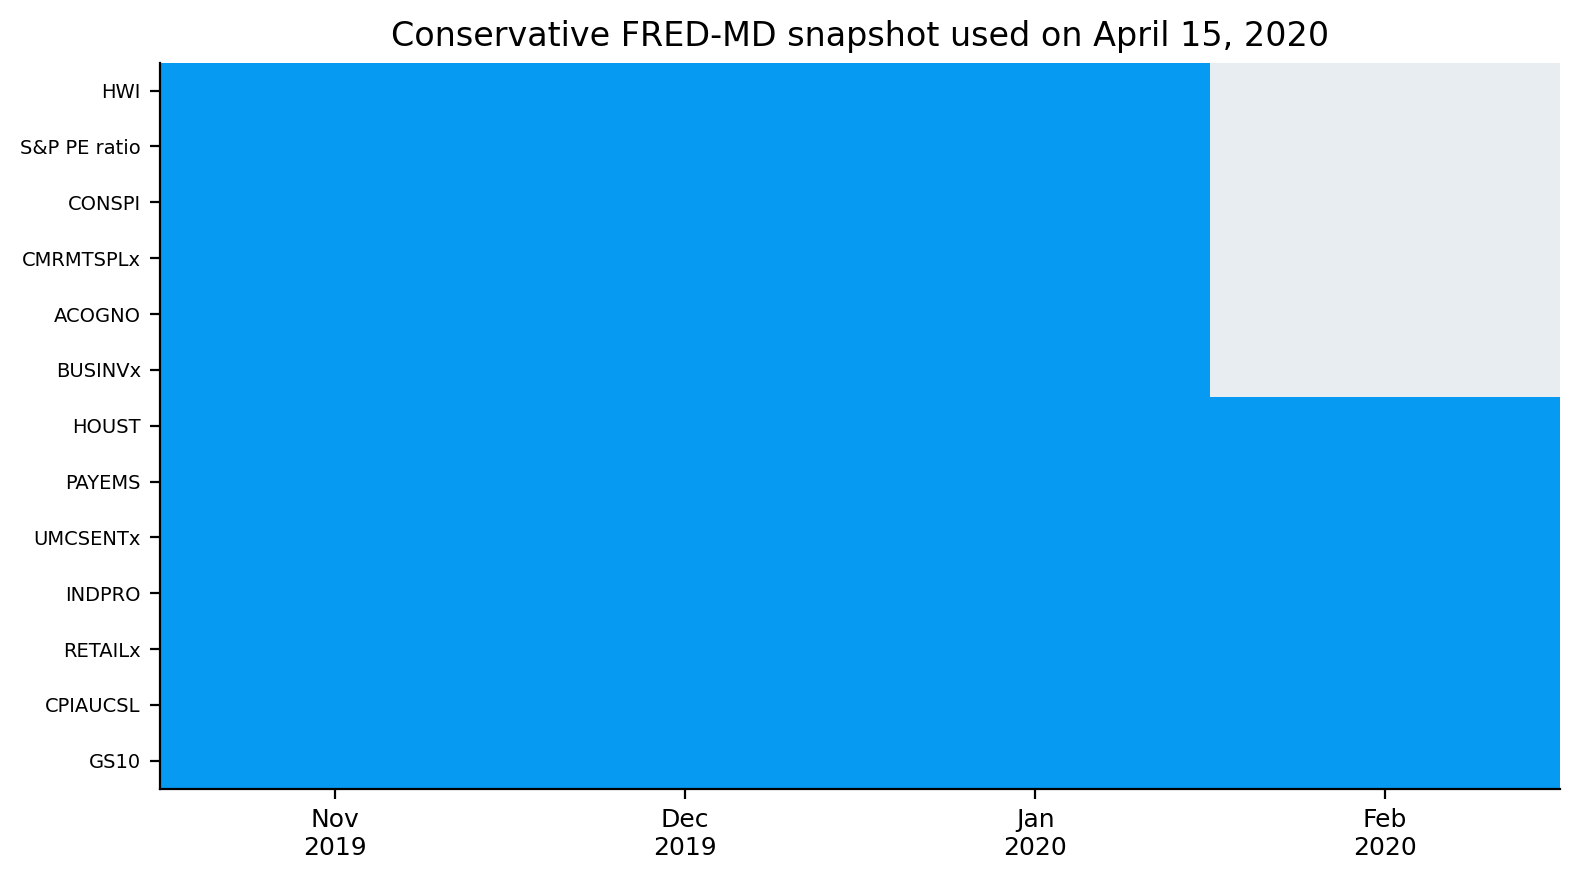

In [5]:
ragged_date = pd.Timestamp("2020-04-15")
ragged_ids = ("S&P PE ratio", "ACOGNO", "BUSINVx", "CMRMTSPLx", "CONSPI", "HWI",
              "CPIAUCSL", "PAYEMS", "INDPRO", "HOUST", "RETAILx", "GS10", "UMCSENTx")
ragged_values = fred_panel_asof(ragged_date, "MD", ragged_ids)
ragged_values = ragged_values.loc["2019-11-01":].tail(4)
ragged_order = sorted(ragged_values.columns, key=lambda name: (
    ragged_values[name].last_valid_index(), fred_family(name), name))
known_matrix = ragged_values[ragged_order].notna().astype(float).T

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.imshow(known_matrix, aspect="auto", interpolation="nearest",
          cmap=ListedColormap(["#E8EDF2", palette[0]]), vmin=0, vmax=1)
ax.set_yticks(np.arange(len(ragged_order)))
ax.set_yticklabels(ragged_order, fontsize=7)
ax.set_xticks(np.arange(len(known_matrix.columns)))
ax.set_xticklabels(known_matrix.columns.strftime("%b\n%Y"), rotation=0)
ax.set_title(f"Conservative FRED-MD snapshot used on {ragged_date:%B %d, %Y}")
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)
plt.tight_layout()
plt.show()

In [6]:
alfred = pd.read_parquet(ALFRED_PATH)
alfred_catalog = pd.read_parquet(ALFRED_CATALOG_PATH)
for name in ["observation_date", "realtime_start", "realtime_end"]:
    alfred[name] = pd.to_datetime(alfred[name])
alfred_catalog[["first_vintage", "last_vintage"]] = alfred_catalog[
    ["first_vintage", "last_vintage"]].apply(pd.to_datetime)
alfred = alfred.sort_values(["series_id", "observation_date", "realtime_start"]).reset_index(drop=True)
alfred_by_series = {series_id: history.reset_index(drop=True)
                    for series_id, history in alfred.groupby("series_id", sort=False)}
assert alfred["series_id"].nunique() == 52
assert not alfred.duplicated(["series_id", "observation_date", "realtime_start"]).any()
assert alfred.loc[alfred["realtime_end"].notna(), "realtime_end"].ge(
    alfred.loc[alfred["realtime_end"].notna(), "realtime_start"]).all()

@lru_cache(maxsize=2048)
def _alfred_asof(date_text, series_ids):
    date = pd.Timestamp(date_text)
    source = pd.concat([alfred_by_series[name] for name in series_ids], ignore_index=True) \
        if series_ids else alfred
    known = source[source["realtime_start"].le(date)
                   & (source["realtime_end"].isna() | source["realtime_end"].ge(date))]
    return known.sort_values(["series_id", "observation_date"]).reset_index(drop=True)

def alfred_asof(as_of, series_ids=()):
    names = tuple(series_ids)
    return _alfred_asof(str(pd.Timestamp(as_of)), names)

def latest_available(as_of, series_ids=()):
    known = alfred_asof(as_of, series_ids)
    last_dates = known.groupby("series_id")["observation_date"].transform("max")
    return known[known["observation_date"].eq(last_dates)].reset_index(drop=True)

def new_releases_between(start, end, series_ids=()):
    releases = alfred[alfred["realtime_start"].gt(pd.Timestamp(start))
                      & alfred["realtime_start"].le(pd.Timestamp(end))]
    if series_ids:
        releases = releases[releases["series_id"].isin(series_ids)]
    return releases.sort_values(["realtime_start", "series_id", "observation_date"]).reset_index(drop=True)

alfred_coverage = alfred_catalog.groupby("category").agg(
    series=("series_id", "nunique"), first_vintage=("first_vintage", "min"),
    last_vintage=("last_vintage", "max"), median_vintages=("vintage_count", "median"),
    oldest_observation=("observation_start", "min")).sort_index()
display(alfred_coverage)

,series,first_vintage,last_vintage,median_vintages,oldest_observation
category,,,,,
business_investment,4,1997-03-06,2026-08-26,521.0000,1958-02-01
consumption,5,1979-11-19,2026-08-26,323.0000,1959-01-01
housing,4,1960-07-21,2026-08-25,471.5000,1959-01-01
income,3,1966-01-18,2026-08-26,566.0000,1946-01-01
inflation,11,1972-07-21,2026-08-26,197.0000,1947-01-01
inventories,4,1996-11-15,2026-08-14,159.0000,1980-12-01
labor,9,1955-05-06,2026-08-27,798.0000,1939-01-01
policy_financial,5,1996-12-03,2026-08-03,358.0000,1953-04-01
production,4,1927-01-26,2026-08-18,369.5000,1919-01-01


In [7]:
information_dates = [pd.Timestamp("2008-09-15"), pd.Timestamp("2020-04-03"),
                     pd.Timestamp("2022-06-10"), pd.Timestamp("2025-08-08")]
information_ids = ("PAYEMS", "CPIAUCSL", "PCEPI", "INDPRO", "UNRATE")
information_rows = []
for date in information_dates:
    known = latest_available(date, information_ids)
    assert known["realtime_start"].le(date).all()
    assert (known["realtime_end"].isna() | known["realtime_end"].ge(date)).all()
    current = alfred_asof(alfred["realtime_start"].max(), information_ids)
    comparison = known.merge(
        current[["series_id", "observation_date", "value"]],
        on=["series_id", "observation_date"], how="left", suffixes=("_realtime", "_revised"))
    for row in comparison.itertuples():
        information_rows.append({"as_of": date, "series": row.series_id,
                                 "latest_observation": row.observation_date,
                                 "known_then": row.value_realtime,
                                 "known_now": row.value_revised,
                                 "revision": row.value_revised - row.value_realtime})
information_comparison = pd.DataFrame(information_rows)
display(information_comparison.set_index(["as_of", "series"]))

latest_observation   known_then    known_now  revision
as_of      series                                                         
2008-09-15 CPIAUCSL         2008-07-01     219.1810     219.0160   -0.1650
           INDPRO           2008-08-01     110.3034      98.1111  -12.1923
           PAYEMS           2008-08-01 137,473.0000 137,211.0000 -262.0000
           PCEPI            2008-07-01     123.0870      90.2450  -32.8420
           UNRATE           2008-08-01       6.1000       6.1000    0.0000
2020-04-03 CPIAUCSL         2020-02-01     259.0500     259.2500    0.2000
           INDPRO           2020-02-01     109.6035     101.3735   -8.2300
           PAYEMS           2020-03-01 151,786.0000 150,895.0000 -891.0000
           PCEPI            2020-02-01     110.7840     104.5730   -6.2110
           UNRATE           2020-03-01       4.4000       4.4000    0.0000
2022-06-10 CPIAUCSL         2022-05-01     291.4740     291.2980   -0.1760
           INDPRO           2022-04-01     105.5973     101.4400   -4.1573
           PAYEMS           2022-05-01 151,682.0000 151,924.0000  242.0000
           PCEPI            2022-04-01     121.3230     114.8120   -6.5110
           UNRATE           2022-05-01       3.6000       3.6000    0.0000
2025-08-08 CPIAUCSL         2025-06-01     321.5000     321.4350   -0.0650
           INDPRO           2025-06-01     104.0071     101.4785   -2.5286
           PAYEMS           2025-07-01 159,539.0000 158,542.0000 -997.0000
           PCEPI            2025-06-01     126.5550     126.7430    0.1880
           UNRATE           2025-07-01       4.2000       4.3000    0.1000

events  series first_date  last_date
family              release_type                                       
Business investment First release    2233       4 1997-03-06 2026-08-26
                    Revision        17059       4 1997-03-26 2026-08-26
Consumption         First release    3059       5 1979-11-19 2026-08-26
                    Revision        26785       5 1979-12-18 2026-08-26
Housing             First release    2667       4 1960-07-21 2026-08-25
                    Revision         8819       4 1960-08-18 2026-08-25
Income              First release    2589       3 1966-01-18 2026-08-26
                    Revision        32414       3 1966-02-17 2026-08-26
Inflation           First release    9094      11 1972-07-21 2026-08-26
                    Revision        26578      11 1973-05-22 2026-08-26
Inventories         First release    1789       4 1996-11-15 2026-08-14
                    Revision        19587       4 1996-12-13 2026-08-14
Labor               First release   12417       9 1955-05-06 2026-08-27
                    Revision        30153       9 1955-06-07 2026-08-27
Policy and markets  First release    3868       5 1996-12-03 2026-08-03
                    Revision          777       4 1997-12-10 2026-02-02
Production          First release    3412       4 1927-01-26 2026-08-18
                    Revision        61763       4 1927-04-28 2026-08-18
Trade               First release    1058       3 1991-12-04 2026-08-04
                    Revision         8288       3 1992-02-28 2026-08-26

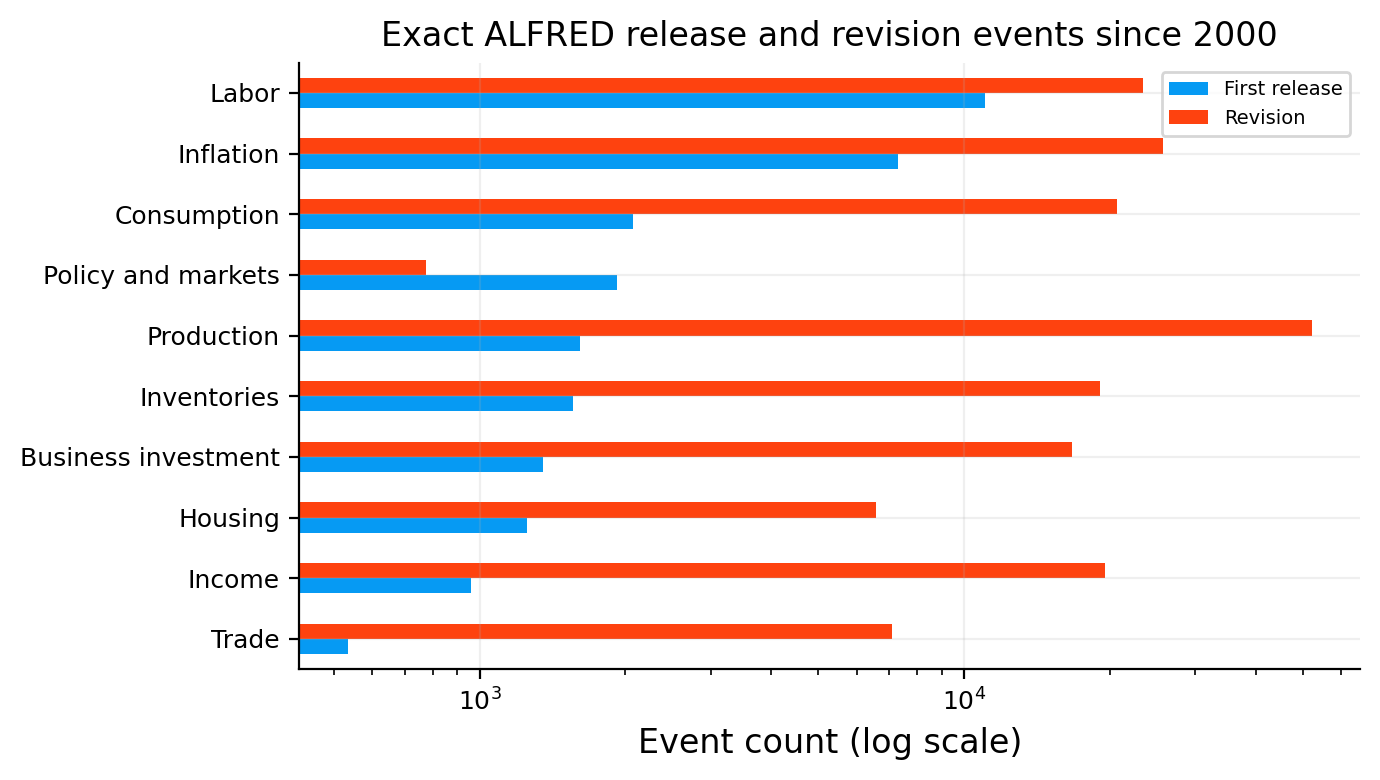

In [8]:
first_seen = alfred.groupby(["series_id", "observation_date"])["realtime_start"].transform("min")
release_calendar = alfred[["series_id", "category", "observation_date", "value",
                           "realtime_start"]].rename(columns={"realtime_start": "release_date"}).copy()
release_calendar["release_type"] = np.where(
    release_calendar["release_date"].eq(first_seen), "First release", "Revision")
release_calendar["family"] = release_calendar["category"].replace({
    "business_investment": "Business investment", "consumption": "Consumption",
    "housing": "Housing", "income": "Income", "inflation": "Inflation",
    "inventories": "Inventories", "labor": "Labor", "policy_financial": "Policy and markets",
    "production": "Production", "trade": "Trade"})
assert not release_calendar.duplicated(
    ["series_id", "observation_date", "release_date"]).any()

event_audit = release_calendar.groupby(["family", "release_type"]).agg(
    events=("series_id", "size"), series=("series_id", "nunique"),
    first_date=("release_date", "min"), last_date=("release_date", "max")).sort_index()
display(event_audit)

event_counts = release_calendar.query("release_date >= '2000-01-01'").groupby(
    ["family", "release_type"]).size().unstack(fill_value=0)
event_counts = event_counts.sort_values("First release")
ax = event_counts.plot(kind="barh", figsize=(7, 4), color=[palette[0], palette[1]])
ax.set_title("Exact ALFRED release and revision events since 2000")
ax.set_xscale("log")
ax.set_xlabel("Event count (log scale)")
ax.set_ylabel("")
ax.legend(title="")
plt.tight_layout()
plt.show()

In [9]:
philly_vintages = pd.read_parquet(PHILLY_VINTAGE_PATH)
philly_releases = pd.read_parquet(PHILLY_RELEASE_PATH)
for frame in [philly_vintages, philly_releases]:
    frame["observation_date"] = pd.to_datetime(frame["observation_date"])
philly_vintages["vintage_date"] = pd.to_datetime(philly_vintages["vintage_date"])

philly_names = {"ROUTPUT": "real_gdp", "RCON": "real_consumption",
                "RINVBF": "business_fixed_investment", "RINVRESID": "residential_investment",
                "REX": "real_exports", "RIMP": "real_imports", "RCONM": "monthly_real_consumption",
                "PCPI": "headline_cpi", "PCPIX": "core_cpi", "PCONX": "core_pce_quarterly",
                "EMPLOY": "payroll", "H": "aggregate_hours", "IPT": "industrial_production",
                "IPM": "manufacturing_production", "HSTARTS": "housing_starts"}
release_series = {"PCPI": "CPIAUCSL", "PCPIX": "CPILFESL", "PCONX": "PCEPILFE",
                  "EMPLOY": "PAYEMS", "H": "AWHI", "IPT": "INDPRO",
                  "IPM": "IPMAN", "HSTARTS": "HOUST"}

first_vintage = philly_vintages.groupby(["variable", "observation_date"])[
    "vintage_date"].min().rename("rtdsm_vintage").reset_index()
alfred_first_dates = release_calendar.query("release_type == 'First release'").set_index(
    ["series_id", "observation_date"])["release_date"]
first_vintage["exact_release_date"] = [
    alfred_first_dates.get((release_series.get(variable, ""), observation_date), pd.NaT)
    for variable, observation_date in first_vintage[["variable", "observation_date"]].itertuples(index=False)]
first_vintage["usable_date"] = first_vintage["exact_release_date"].fillna(
    first_vintage["rtdsm_vintage"])

philly_coverage = philly_vintages.assign(
    target=philly_vintages["variable"].map(philly_names)).groupby("target").agg(
        observations=("observation_date", "nunique"), vintages=("vintage_date", "nunique"),
        first_observation=("observation_date", "min"), last_observation=("observation_date", "max"),
        first_vintage=("vintage_date", "min"), last_vintage=("vintage_date", "max"))
philly_coverage["exact_day_match"] = first_vintage.assign(
    target=first_vintage["variable"].map(philly_names)).groupby("target")[
        "exact_release_date"].apply(lambda x: x.notna().mean())
assert set(philly_names) == set(philly_vintages["variable"].unique())
display(philly_coverage)

,observations,vintages,first_observation,last_observation,first_vintage,last_vintage,exact_day_match
target,,,,,,,
aggregate_hours,751,660,1964-01-01,2026-07-01,1971-09-01,2026-08-01,1.0000
business_fixed_investment,318,244,1947-01-01,2026-04-01,1965-12-31,2026-09-30,0.0000
core_cpi,834,334,1957-01-01,2026-07-01,1998-11-01,2026-08-01,1.0000
core_pce_quarterly,270,368,1959-01-01,2026-04-01,1996-02-01,2026-09-01,1.0000
headline_cpi,954,334,1947-01-01,2026-07-01,1998-11-01,2026-08-01,1.0000
housing_starts,955,703,1947-01-01,2026-07-01,1968-02-01,2026-08-01,0.8492
industrial_production,1291,766,1919-01-01,2026-07-01,1962-11-01,2026-08-01,1.0000
manufacturing_production,1291,766,1919-01-01,2026-07-01,1962-11-01,2026-08-01,0.5074
monthly_real_consumption,811,335,1959-01-01,2026-07-01,1998-11-01,2026-09-01,0.0000


,frequency,observations,first_observation,last_observation,first_release_date,last_release_date,revision_mae
target,,,,,,,
core_cpi,monthly,332,1998-10-01,2026-07-01,1998-11-17,2026-08-12,0.4585
core_pce,monthly,810,1959-02-01,2026-07-01,2000-08-01,2026-08-26,0.5631
headline_cpi,monthly,332,1998-10-01,2026-07-01,1998-11-17,2026-08-12,0.9030
headline_pce,monthly,810,1959-02-01,2026-07-01,2000-08-01,2026-08-26,0.5292
payroll,monthly,739,1964-11-01,2026-07-01,1964-12-04,2026-08-07,84.8539
real_gdp,quarterly,241,1965-07-01,2026-04-01,1965-11-01,2026-07-30,1.5003
unemployment,monthly,942,1948-01-01,2026-07-01,1960-03-15,2026-08-07,0.0694


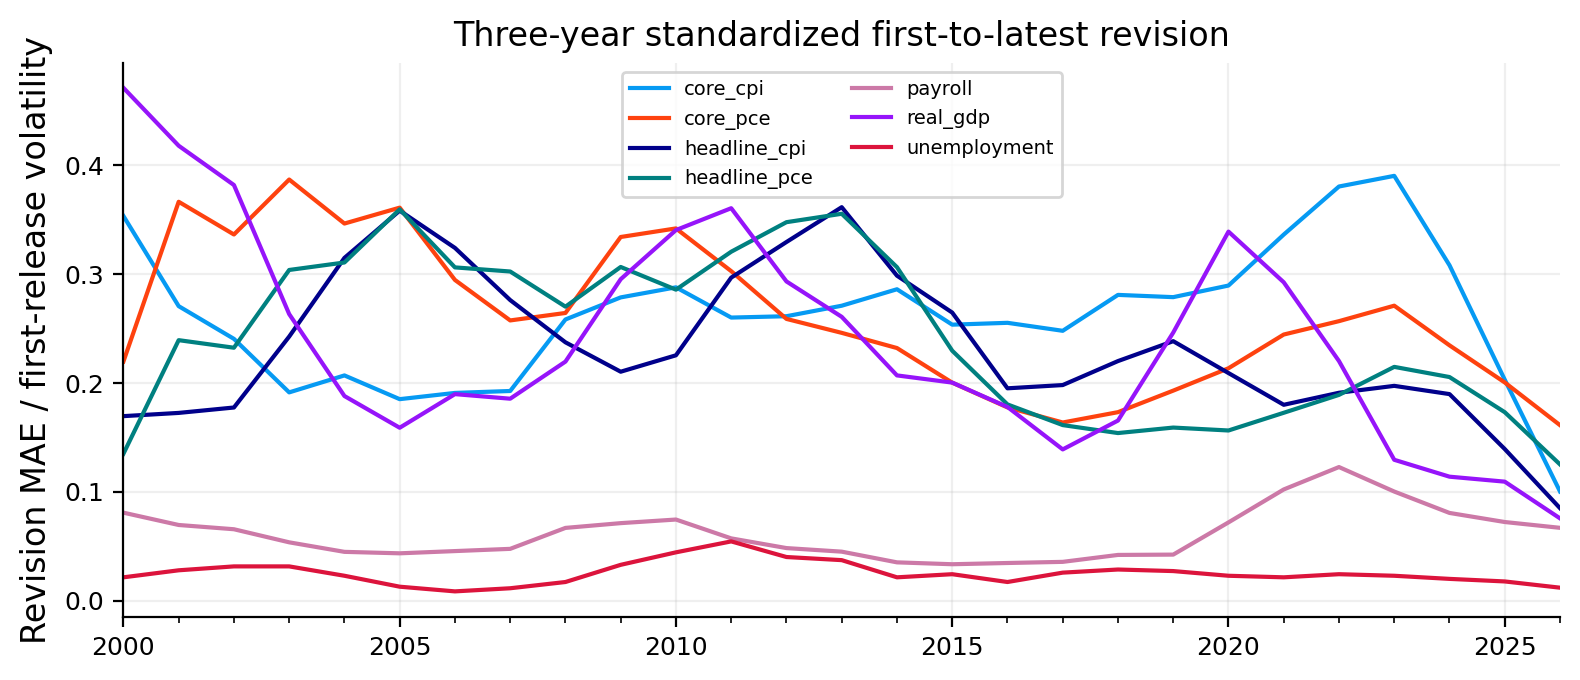

In [10]:
release_wide = philly_releases.pivot_table(
    index=["variable", "measure", "observation_date", "observation_frequency"],
    columns="release", values="value", aggfunc="last").reset_index()

gdp_dates = pd.read_parquet(GDPNOW_TRACK_PATH)[
    ["target_quarter", "bea_release_date"]].drop_duplicates("target_quarter")
gdp_dates["target_quarter"] = pd.to_datetime(gdp_dates["target_quarter"])
gdp_dates["target_quarter"] = gdp_dates["target_quarter"].dt.to_period("Q").dt.start_time
gdp_dates["bea_release_date"] = pd.to_datetime(gdp_dates["bea_release_date"])

truth_frames = []
for variable, target, measure in [("ROUTPUT", "real_gdp", "published"),
                                  ("PCPI", "headline_cpi", "published"),
                                  ("PCPIX", "core_cpi", "published"),
                                  ("EMPLOY", "payroll", "level_change")]:
    truth = release_wide.query("variable == @variable and measure == @measure").copy()
    truth["target"] = target
    truth = truth.merge(first_vintage.query("variable == @variable")[[
        "observation_date", "usable_date", "rtdsm_vintage", "exact_release_date"]],
        on="observation_date", how="left")
    truth["release_date"] = truth["usable_date"]
    truth["release_source"] = np.where(truth["exact_release_date"].notna(),
                                       "ALFRED exact validity start", "RTDSM vintage label")
    if variable == "ROUTPUT":
        truth = truth.merge(gdp_dates, left_on="observation_date", right_on="target_quarter", how="left")
        use_gdp_date = truth["bea_release_date"].notna()
        truth.loc[use_gdp_date, "release_date"] = truth.loc[use_gdp_date, "bea_release_date"]
        truth.loc[use_gdp_date, "release_source"] = "BEA advance date in GDPNow track record"
    truth_frames.append(truth)

def alfred_first_growth(series_id, target):
    first = alfred[alfred["series_id"].eq(series_id)].sort_values("realtime_start").drop_duplicates(
        ["observation_date"], keep="first")
    rows = []
    for row in first.itertuples():
        known = alfred_asof(row.realtime_start, (series_id,)).set_index("observation_date")["value"]
        earlier = known.loc[known.index < row.observation_date]
        if earlier.empty or row.value <= 0 or earlier.iloc[-1] <= 0:
            continue
        growth = 1200 * np.log(row.value / earlier.iloc[-1])
        rows.append({"observation_date": row.observation_date, "first": growth,
                     "release_date": row.realtime_start})
    out = pd.DataFrame(rows)
    current = alfred_asof(alfred["realtime_start"].max(), (series_id,)).set_index(
        "observation_date")["value"]
    latest = 1200 * np.log(current / current.shift(1))
    out["most_recent"] = out["observation_date"].map(latest)
    out["target"] = target
    out["observation_frequency"] = "monthly"
    out["release_source"] = "ALFRED exact validity start"
    return out

truth_frames.extend([alfred_first_growth("PCEPI", "headline_pce"),
                     alfred_first_growth("PCEPILFE", "core_pce")])

unemployment = alfred[alfred["series_id"].eq("UNRATE")].sort_values("realtime_start").drop_duplicates(
    "observation_date", keep="first")[["observation_date", "value", "realtime_start"]]
unemployment = unemployment.rename(columns={"value": "first", "realtime_start": "release_date"})
unemployment["most_recent"] = unemployment["observation_date"].map(
    alfred_asof(alfred["realtime_start"].max(), ("UNRATE",)).set_index("observation_date")["value"])
unemployment["target"] = "unemployment"
unemployment["observation_frequency"] = "monthly"
unemployment["release_source"] = "ALFRED exact validity start"
truth_frames.append(unemployment)

truth_columns = ["target", "observation_date", "observation_frequency", "release_date",
                 "release_source", "first", "second", "third", "most_recent"]
target_truth = pd.concat(truth_frames, ignore_index=True).reindex(columns=truth_columns)
target_truth = target_truth.dropna(subset=["first", "release_date"]).sort_values(
    ["target", "observation_date"]).reset_index(drop=True)
target_truth["revision"] = target_truth["most_recent"] - target_truth["first"]
assert set(target_truth["target"]) == set(TARGETS)
assert target_truth["release_date"].ge(target_truth["observation_date"]).all()

truth_coverage = target_truth.groupby("target").agg(
    frequency=("observation_frequency", "first"), observations=("first", "size"),
    first_observation=("observation_date", "min"), last_observation=("observation_date", "max"),
    first_release_date=("release_date", "min"), last_release_date=("release_date", "max"),
    revision_mae=("revision", lambda x: x.abs().mean())).sort_index()
display(truth_coverage)

revision_plot = target_truth.query("release_date >= '2000-01-01'").groupby(
    [target_truth["release_date"].dt.to_period("Y"), "target"])["revision"].apply(
        lambda x: x.abs().mean()).unstack()
revision_scale = target_truth.query("release_date >= '2000-01-01'").groupby("target")["first"].std(ddof=1)
revision_plot = revision_plot.div(revision_scale, axis=1)
revision_plot.index = revision_plot.index.to_timestamp()
ax = revision_plot.rolling(3, min_periods=1).mean().plot(figsize=(8, 3.5))
ax.set_title("Three-year standardized first-to-latest revision")
ax.set_xlabel("")
ax.set_ylabel("Revision MAE / first-release volatility")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

In [11]:
target_settings = pd.DataFrame({
    "frequency": ["quarterly", "monthly", "monthly", "monthly", "monthly", "monthly", "monthly"],
    "unit": ["annualized q/q %", "annualized m/m %", "annualized m/m %",
             "annualized m/m %", "annualized m/m %", "thousands", "percent"],
    "horizons": [GDP_DAYS, MONTHLY_DAYS, MONTHLY_DAYS, MONTHLY_DAYS,
                 MONTHLY_DAYS, MONTHLY_DAYS, MONTHLY_DAYS],
    "minimum_training_observations": [24, 60, 60, 60, 60, 60, 60]}, index=TARGETS)

evaluation_rows = []
for row in target_truth.query("observation_date >= @TRAIN_START").itertuples():
    horizons = GDP_DAYS if row.target == "real_gdp" else MONTHLY_DAYS
    for horizon in horizons:
        evaluation_rows.append({"target": row.target, "observation_date": row.observation_date,
                                "release_date": row.release_date,
                                "evaluation_date": row.release_date - pd.offsets.BDay(horizon),
                                "horizon": horizon, "actual": row.first})
evaluation_grid = pd.DataFrame(evaluation_rows).sort_values(
    ["evaluation_date", "target", "observation_date", "horizon"]).reset_index(drop=True)
evaluation_grid["scored"] = evaluation_grid["release_date"].ge(SCORE_START)
evaluation_grid["period"] = np.select(
    [evaluation_grid["release_date"].lt("2020-01-01"),
     evaluation_grid["release_date"].between("2020-01-01", "2021-12-31")],
    ["Pre-COVID", "COVID"], default="Post-COVID")
assert not evaluation_grid.duplicated(["target", "observation_date", "horizon"]).any()

evaluation_design = target_settings.copy()
evaluation_design["training_rows"] = evaluation_grid.groupby("target")["scored"].apply(lambda x: (~x).sum())
evaluation_design["scored_rows"] = evaluation_grid.groupby("target")["scored"].sum()
display(evaluation_design)

,frequency,unit,horizons,minimum_training_observations,training_rows,scored_rows
real_gdp,quarterly,annualized q/q %,"(60, 45, 30, 15, 7, 1)",24,270,282
headline_cpi,monthly,annualized m/m %,"(20, 10, 5, 1)",60,548,576
core_cpi,monthly,annualized m/m %,"(20, 10, 5, 1)",60,548,576
headline_pce,monthly,annualized m/m %,"(20, 10, 5, 1)",60,548,584
core_pce,monthly,annualized m/m %,"(20, 10, 5, 1)",60,548,584
payroll,monthly,thousands,"(20, 10, 5, 1)",60,548,576
unemployment,monthly,percent,"(20, 10, 5, 1)",60,548,580


n    MAE   RMSE  Spearman IC  Directional Accuracy    Bias
target       horizon model                                                                     
core_cpi     1       ar1           144 1.2993 1.8510       0.5644                0.9722 -0.3928
                     last_release  144 1.4206 1.9319       0.5374                0.9583  0.0037
                     rolling_mean  144 1.3894 2.0924       0.4608                0.9653 -0.0778
             5       ar1           144 1.2993 1.8510       0.5644                0.9722 -0.3928
                     last_release  144 1.4206 1.9319       0.5374                0.9583  0.0037
...                                ...    ...    ...          ...                   ...     ...
unemployment 10      last_release  145 0.2400 0.9178       0.9549                1.0000  0.0152
                     rolling_mean  145 0.9401 1.7046       0.5384                1.0000  0.2426
             20      ar1           145 0.3604 1.2235       0.9335                1.0000  0.0310
                     last_release  145 0.3559 1.2320       0.9388                1.0000  0.0069
                     rolling_mean  145 0.9795 1.7569       0.4938                1.0000  0.2558

[90 rows x 6 columns]

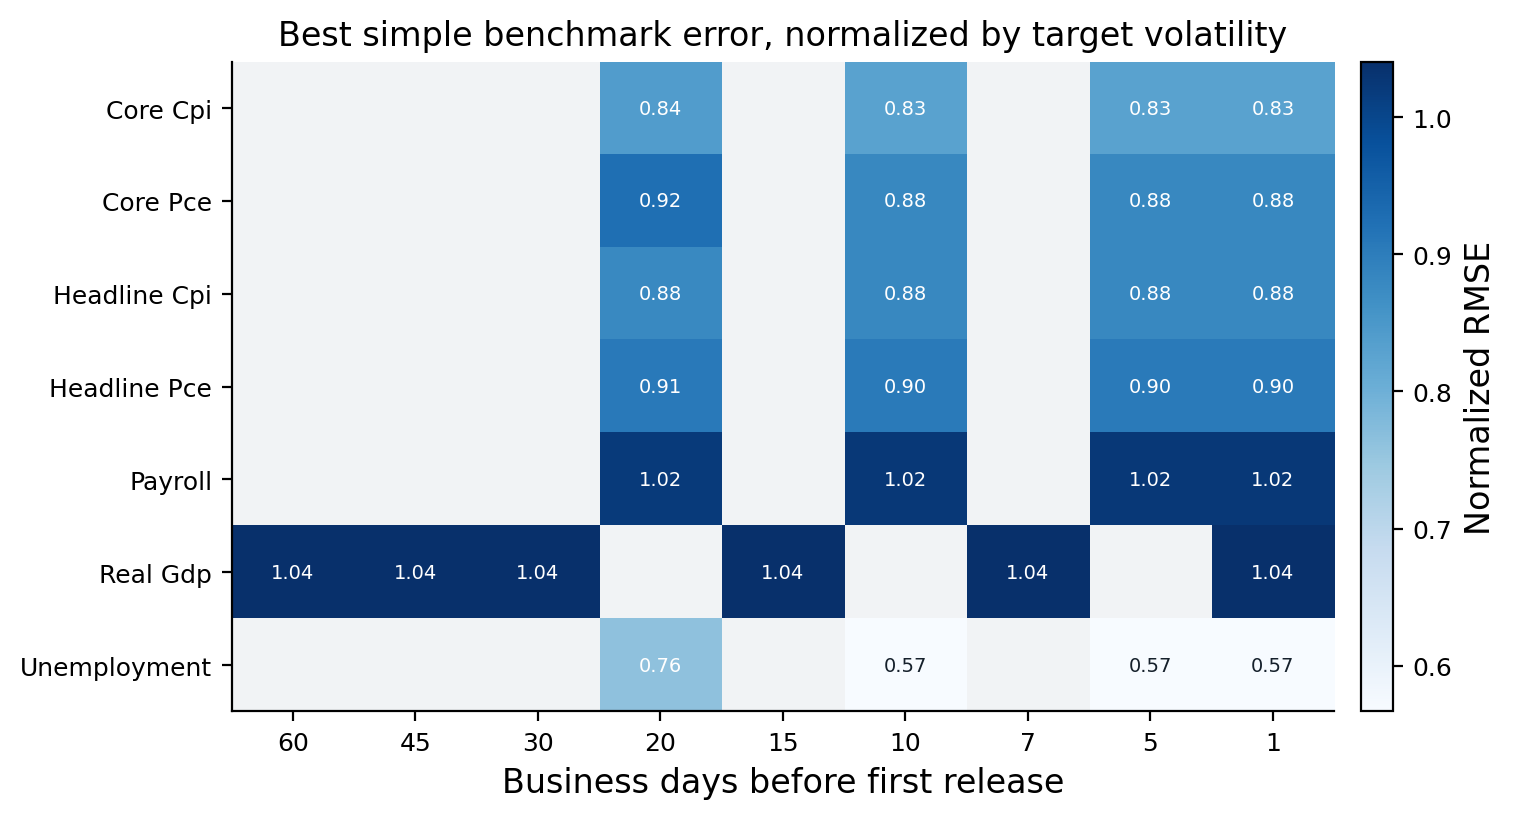

In [12]:
baseline_rows = []
for row in evaluation_grid.itertuples():
    history = target_truth[target_truth["target"].eq(row.target)
                           & target_truth["release_date"].lt(row.evaluation_date)].sort_values(
                               "observation_date")["first"].dropna()
    last_release = history.iloc[-1]
    rolling_mean = history.tail(24 if row.target != "real_gdp" else 12).mean()
    lagged = pd.concat([history.rename("y"), history.shift(1).rename("lag")], axis=1).dropna()
    if len(lagged) >= 20:
        ar = LinearRegression().fit(lagged[["lag"]], lagged["y"])
        ar1 = float(ar.predict(pd.DataFrame({"lag": [last_release]}))[0])
    else:
        ar1 = rolling_mean
    baseline_rows.append({"target": row.target, "observation_date": row.observation_date,
                          "release_date": row.release_date, "evaluation_date": row.evaluation_date,
                          "horizon": row.horizon, "period": row.period, "actual": row.actual,
                          "last_release": last_release, "rolling_mean": rolling_mean, "ar1": ar1})
baseline_forecasts = pd.DataFrame(baseline_rows)

baseline_scores = []
for (target, horizon), sample in baseline_forecasts.query("release_date >= @SCORE_START").groupby(
        ["target", "horizon"]):
    scores = forecast_metrics(sample, y_col="actual",
                              prediction_cols=["last_release", "rolling_mean", "ar1"]).reset_index()
    scores["target"] = target
    scores["horizon"] = horizon
    baseline_scores.append(scores)
baseline_scores = pd.concat(baseline_scores, ignore_index=True)
display(baseline_scores.sort_values(["target", "horizon", "RMSE"]).set_index(
    ["target", "horizon", "model"]))

baseline_plot = baseline_scores.pivot_table(index="horizon", columns="target", values="RMSE", aggfunc="min")
baseline_scale = baseline_forecasts.query("release_date >= @SCORE_START").groupby("target")["actual"].std(ddof=1)
baseline_plot = baseline_plot.div(baseline_scale, axis=1)
baseline_heat = baseline_plot.T.reindex(columns=sorted(baseline_plot.index, reverse=True))
fig, ax = plt.subplots(figsize=(8, 4.2))
cmap = plt.get_cmap("Blues").copy()
cmap.set_bad("#F1F3F5")
image = ax.imshow(np.ma.masked_invalid(baseline_heat.to_numpy()), aspect="auto", cmap=cmap)
for row in range(len(baseline_heat.index)):
    for column in range(len(baseline_heat.columns)):
        value = baseline_heat.iloc[row, column]
        if np.isfinite(value):
            ax.text(column, row, f"{value:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if value > 0.72 else "#15202B")
ax.set_xticks(np.arange(len(baseline_heat.columns)))
ax.set_xticklabels(baseline_heat.columns)
ax.set_yticks(np.arange(len(baseline_heat.index)))
ax.set_yticklabels([name.replace("_", " ").title() for name in baseline_heat.index])
ax.set_title("Best simple benchmark error, normalized by target volatility")
ax.set_xlabel("Business days before first release")
ax.set_ylabel("")
ax.grid(False)
colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label("Normalized RMSE")
plt.tight_layout()
plt.show()

In [13]:
gdp_blocks = {
    "consumption": ("PCEC96", "RSAFS", "RSFSXMV", "TOTALSA", "DSPIC96"),
    "residential": ("HOUST", "PERMIT", "TLRESCONS", "HSN1F"),
    "business": ("DGORDER", "NEWORDER", "ANXAVS", "TLNRESCONS", "IPMAN"),
    "inventories": ("BUSINV", "MNFCTRIMSA", "WHLSLRIMSA", "RETAILIMSA"),
    "net_exports": ("EXPGS", "IMPGS", "BOPGSTB"),
    "common_activity": ("INDPRO", "TCU", "AWHI", "PAYEMS", "FEDFUNDS")}
gdp_series = tuple(dict.fromkeys(series_id for names in gdp_blocks.values() for series_id in names))
level_difference_ids = {"TCU", "FEDFUNDS", "BOPGSTB"}

def completed_quarter_signal(known, series_id, quarter):
    values = known[known["series_id"].eq(series_id)].sort_values("observation_date").set_index(
        "observation_date")["value"].groupby(level=0).last()
    current_months = pd.period_range(quarter.start_time, quarter.end_time, freq="M").to_timestamp()
    previous_months = pd.period_range(quarter.start_time - pd.DateOffset(months=3),
                                      quarter.start_time - pd.DateOffset(months=1),
                                      freq="M").to_timestamp()
    observed_months = int(values.reindex(current_months).notna().sum())
    completed = values.copy()
    for month in current_months:
        if month in completed.index and pd.notna(completed.loc[month]):
            continue
        prior = completed[completed.index < month].dropna()
        if prior.empty:
            continue
        if series_id in level_difference_ids or (prior.tail(24) <= 0).any():
            forecast = prior.iloc[-1]
        else:
            growth = np.log(prior).diff().dropna().tail(18)
            growth = growth.clip(growth.quantile(0.10), growth.quantile(0.90))
            forecast = prior.iloc[-1] * np.exp(growth.median())
        completed.loc[month] = forecast
        completed = completed.sort_index()
    current_mean = completed.reindex(current_months).mean()
    previous_mean = completed.reindex(previous_months).mean()
    if series_id in level_difference_ids or current_mean <= 0 or previous_mean <= 0:
        signal = current_mean - previous_mean
    else:
        signal = 400 * np.log(current_mean / previous_mean)
    return signal, observed_months

gdp_rows = []
gdp_grid = evaluation_grid[evaluation_grid["target"].eq("real_gdp")]
for row in gdp_grid.itertuples():
    known = alfred_asof(row.evaluation_date, gdp_series)
    quarter = row.observation_date.to_period("Q")
    record = {"observation_date": row.observation_date, "release_date": row.release_date,
              "evaluation_date": row.evaluation_date, "horizon": row.horizon,
              "actual": row.actual}
    for series_id in gdp_series:
        signal, observed = completed_quarter_signal(known, series_id, quarter)
        record[series_id] = signal
        record[f"{series_id}_known"] = observed
    gdp_rows.append(record)
gdp_features = pd.DataFrame(gdp_rows)

block_coverage = []
for block, names in gdp_blocks.items():
    known_columns = [f"{name}_known" for name in names]
    block_coverage.append({"block": block, "series": len(names),
                           "mean_signal_coverage": gdp_features[list(names)].notna().mean().mean(),
                           "minimum_signal_coverage": gdp_features[list(names)].notna().mean().min(),
                           "mean_observed_months": gdp_features[known_columns].mean().mean(),
                           "fully_observed_rows": gdp_features[known_columns].eq(3).all(axis=1).mean()})
block_coverage = pd.DataFrame(block_coverage).set_index("block")
display(block_coverage)

,series,mean_signal_coverage,minimum_signal_coverage,mean_observed_months,fully_observed_rows
block,,,,,
consumption,5,0.9130,0.5652,1.4482,0.0000
residential,4,0.9090,0.6359,1.4203,0.0000
business,5,0.8123,0.6359,1.1996,0.0000
inventories,4,0.6630,0.5507,0.6495,0.0000
net_exports,3,0.9940,0.9909,0.4112,0.0000
common_activity,5,1.0000,1.0000,1.9873,0.3261


In [14]:
component_variables = {"consumption": "RCON", "residential": "RINVRESID",
                       "business": "RINVBF", "exports": "REX", "imports": "RIMP"}
component_weights = {"consumption": 0.68, "residential": 0.04, "business": 0.14,
                     "exports": 0.12, "imports": -0.15, "common_activity": 1.00}
component_features = {"consumption": list(gdp_blocks["consumption"]),
                      "residential": list(gdp_blocks["residential"]),
                      "business": list(gdp_blocks["business"]),
                      "exports": list(gdp_blocks["net_exports"]),
                      "imports": list(gdp_blocks["net_exports"]),
                      "common_activity": list(gdp_blocks["common_activity"])
                      + ["BUSINV", "BOPGSTB"]}

component_truth = release_wide.query("measure == 'published'").copy()
component_truth = component_truth[component_truth["variable"].isin(
    ["ROUTPUT", *component_variables.values()])]
component_truth["component"] = component_truth["variable"].replace(
    {value: key for key, value in component_variables.items()} | {"ROUTPUT": "real_gdp"})
component_truth = component_truth.pivot_table(
    index="observation_date", columns="component", values="first", aggfunc="last").reset_index()

gdp_design = gdp_features.merge(component_truth, on="observation_date", how="left")
weighted_components = sum(component_weights[name] * gdp_design[name]
                          for name in component_variables)
gdp_design["common_activity"] = gdp_design["real_gdp"] - weighted_components

def ridge_nowcast(training, current, features, target, alpha=4.0, minimum=20):
    usable = [name for name in features if training[name].notna().mean() >= 0.65
              and pd.notna(current[name])]
    sample = training[[target, *usable]].dropna(subset=[target])
    if len(sample) < minimum or len(usable) == 0:
        prediction = sample[target].tail(12).mean()
        sigma = sample[target].tail(24).std(ddof=1)
        return prediction, sigma, pd.Series(dtype=float)
    medians = sample[usable].median()
    x = sample[usable].fillna(medians)
    scale = x.std(ddof=0).replace(0, 1)
    z = (x - medians) / scale
    model = Ridge(alpha=alpha).fit(z, sample[target])
    point = ((current[usable] - medians) / scale).to_frame().T
    prediction = float(model.predict(point)[0])
    residual = sample[target] - model.predict(z)
    coefficients = pd.Series(model.coef_ / scale, index=usable)
    return prediction, residual.std(ddof=1), coefficients

latest_row = gdp_design.iloc[-1]
latest_training = gdp_design[(gdp_design["horizon"].eq(latest_row["horizon"]))
                             & gdp_design["release_date"].lt(latest_row["evaluation_date"])]
coefficient_rows = []
for component, names in component_features.items():
    features = [*names, *[f"{name}_known" for name in names]]
    _, _, coefficients = ridge_nowcast(
        latest_training, latest_row, features, component, alpha=5.0, minimum=20)
    for name, coefficient in coefficients.sort_values(key=abs, ascending=False).head(4).items():
        coefficient_rows.append({"component": component, "series": name,
                                 "coefficient": coefficient})
bridge_specification = pd.DataFrame({
    "target": [component_variables.get(name, "ROUTPUT residual") for name in component_features],
    "economic_prior_weight": [component_weights[name] for name in component_features],
    "predictors": [", ".join(component_features[name]) for name in component_features]},
    index=component_features)
display(bridge_specification, pd.DataFrame(coefficient_rows).set_index(["component", "series"]))

,target,economic_prior_weight,predictors
consumption,RCON,0.6800,"PCEC96, RSAFS, RSFSXMV, TOTALSA, DSPIC96"
residential,RINVRESID,0.0400,"HOUST, PERMIT, TLRESCONS, HSN1F"
business,RINVBF,0.1400,"DGORDER, NEWORDER, ANXAVS, TLNRESCONS, IPMAN"
exports,REX,0.1200,"EXPGS, IMPGS, BOPGSTB"
imports,RIMP,-0.1500,"EXPGS, IMPGS, BOPGSTB"
common_activity,ROUTPUT residual,1.0000,"INDPRO, TCU, AWHI, PAYEMS, FEDFUNDS, BUSINV, B..."


coefficient
component       series                      
consumption     PCEC96                0.5772
                RSFSXMV_known        -0.2425
                RSAFS_known          -0.2425
                RSAFS                 0.2245
residential     PERMIT_known         -3.2993
                HOUST_known          -3.2993
                HSN1F_known           1.8870
                TLRESCONS_known       0.3673
business        IPMAN_known          -1.3015
                ANXAVS_known          0.5557
                NEWORDER              0.3104
                IPMAN                 0.2997
exports         BOPGSTB_known        -3.7038
                EXPGS                 0.3589
                IMPGS                 0.2216
                EXPGS_known          -0.1277
imports         BOPGSTB_known        -1.6788
                IMPGS_known          -0.8426
                EXPGS_known          -0.8426
                IMPGS                 0.4054
common_activity FEDFUNDS             -0.2935
                TCU                   0.1259
                BUSINV               -0.0784
                BOPGSTB_known        -0.0546

In [15]:
bridge_rows = []
bridge_component_rows = []
for row in gdp_design.itertuples(index=False):
    current = pd.Series(row._asdict())
    training = gdp_design[gdp_design["horizon"].eq(row.horizon)
                          & gdp_design["release_date"].lt(row.evaluation_date)]
    contributions = {}
    variances = []
    for component, names in component_features.items():
        features = [*names, *[f"{name}_known" for name in names]]
        prediction, sigma, _ = ridge_nowcast(
            training, current, features, component, alpha=5.0, minimum=20)
        contribution = component_weights[component] * prediction
        contributions[component] = contribution
        variances.append(np.square(component_weights[component] * sigma))
        bridge_component_rows.append({"observation_date": row.observation_date,
                                      "evaluation_date": row.evaluation_date,
                                      "horizon": row.horizon, "component": component,
                                      "forecast": prediction, "contribution": contribution})
    bridge_rows.append({"target": "real_gdp", "observation_date": row.observation_date,
                        "release_date": row.release_date, "evaluation_date": row.evaluation_date,
                        "horizon": row.horizon, "actual": row.actual,
                        "bridge": sum(contributions.values()),
                        "bridge_sigma": np.sqrt(np.nansum(variances))})
bridge_forecasts = pd.DataFrame(bridge_rows)
bridge_components = pd.DataFrame(bridge_component_rows)

recent_quarter = bridge_forecasts["observation_date"].max()
recent_bridge = bridge_components[bridge_components["observation_date"].eq(recent_quarter)].pivot_table(
    index="component", columns="horizon", values="contribution").sort_index()
display(recent_bridge)

horizon,1,7,15,30,45,60
component,,,,,,
business,1.1524,0.9845,1.0220,0.8133,0.7554,0.4658
common_activity,0.7291,0.7019,0.7508,0.1475,0.1577,-0.1880
consumption,2.9879,2.9198,2.8312,3.2693,2.5756,2.0765
exports,-0.0438,0.4645,0.3768,0.3791,0.4800,0.5162
imports,-1.6147,-2.1888,-2.0996,-0.6019,-0.8798,-0.9461
residential,-0.1208,-0.1695,-0.3021,-0.1296,0.0983,0.4605


,value
Forecast quarters,61
First forecast date,2011-08-25 00:00:00
Latest forecast date,2026-08-26 00:00:00
Advance-GDP track-record quarters,60
Latest posted source release,2026-12-28 00:00:00


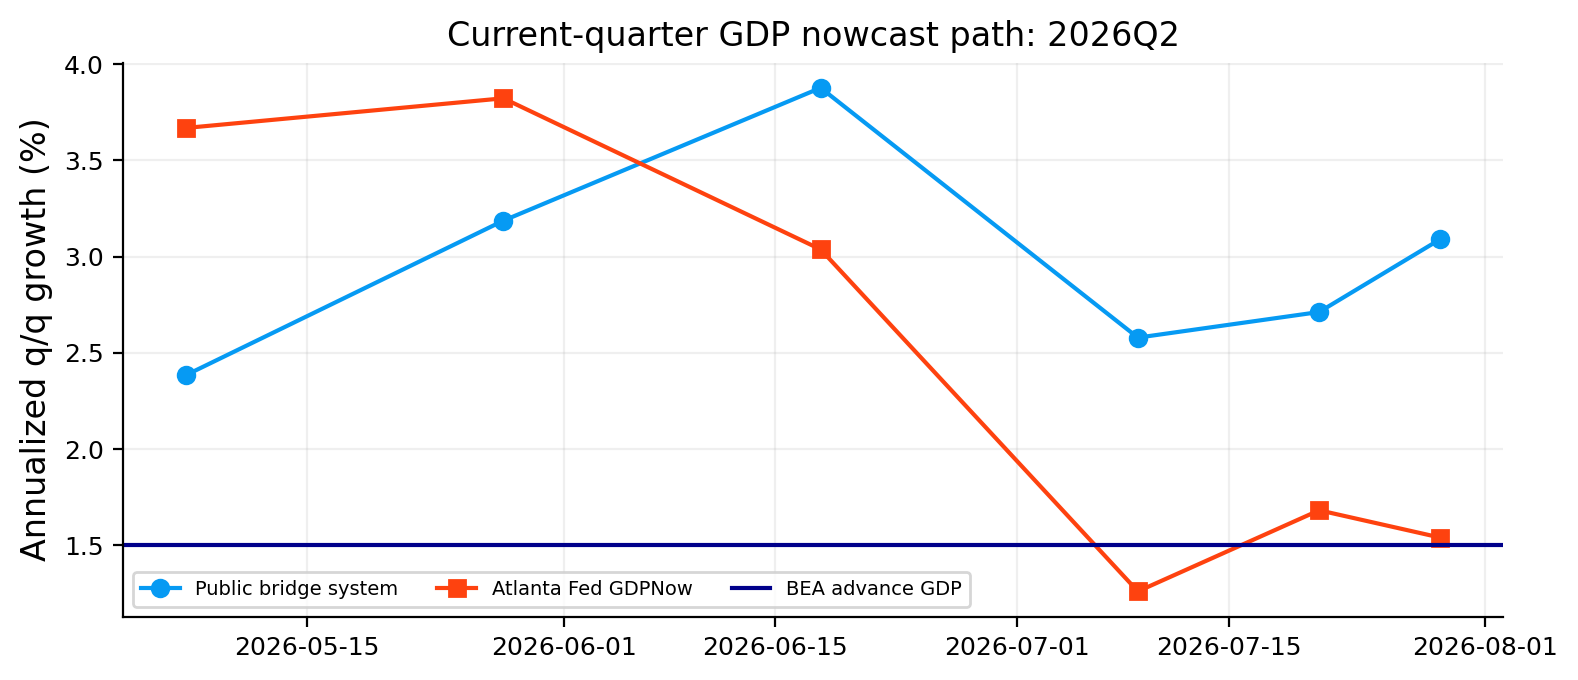

In [16]:
gdpnow_forecasts = pd.read_parquet(GDPNOW_FORECAST_PATH)
gdpnow_contributions = pd.read_parquet(GDPNOW_CONTRIBUTION_PATH)
gdpnow_track = pd.read_parquet(GDPNOW_TRACK_PATH)
gdpnow_calendar = pd.read_parquet(GDPNOW_CALENDAR_PATH)
for frame, names in [(gdpnow_forecasts, ["forecast_date", "target_quarter"]),
                     (gdpnow_contributions, ["forecast_date", "target_quarter"]),
                     (gdpnow_track, ["target_quarter", "bea_release_date"]),
                     (gdpnow_calendar, ["release_date"])]:
    for name in names:
        frame[name] = pd.to_datetime(frame[name])
for frame in [gdpnow_forecasts, gdpnow_contributions, gdpnow_track]:
    frame["target_quarter"] = frame["target_quarter"].dt.to_period("Q").dt.start_time

gdpnow_headline = gdpnow_forecasts[gdpnow_forecasts["component"].eq("GDP Nowcast")].groupby(
    ["forecast_date", "target_quarter"], as_index=False)["forecast_value"].median()
gdpnow_rows = []
for row in bridge_forecasts.itertuples():
    eligible = gdpnow_headline[gdpnow_headline["target_quarter"].eq(row.observation_date)
                               & gdpnow_headline["forecast_date"].le(row.evaluation_date)]
    gdpnow_rows.append({"observation_date": row.observation_date,
                        "evaluation_date": row.evaluation_date,
                        "gdpnow": eligible.iloc[-1]["forecast_value"] if len(eligible) else np.nan,
                        "gdpnow_date": eligible.iloc[-1]["forecast_date"] if len(eligible) else pd.NaT})
gdpnow_aligned = pd.DataFrame(gdpnow_rows)

gdpnow_coverage = pd.DataFrame({
    "value": [gdpnow_headline["target_quarter"].nunique(),
              gdpnow_headline["forecast_date"].min(), gdpnow_headline["forecast_date"].max(),
              gdpnow_track["target_quarter"].nunique(), gdpnow_calendar["release_date"].max()]},
    index=["Forecast quarters", "First forecast date", "Latest forecast date",
           "Advance-GDP track-record quarters", "Latest posted source release"])
display(gdpnow_coverage)

quarters_with_both = gdpnow_aligned.dropna()["observation_date"].unique()
path_quarter = pd.Timestamp(max(quarters_with_both))
path = bridge_forecasts[bridge_forecasts["observation_date"].eq(path_quarter)].merge(
    gdpnow_aligned, on=["observation_date", "evaluation_date"])
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(path["evaluation_date"], path["bridge"], marker="o", label="Public bridge system")
ax.plot(path["evaluation_date"], path["gdpnow"], marker="s", label="Atlanta Fed GDPNow")
ax.axhline(path["actual"].iloc[0], color=palette[2], linewidth=1.5, label="BEA advance GDP")
ax.set_title(f"Current-quarter GDP nowcast path: {path_quarter.to_period('Q')}")
ax.set_ylabel("Annualized q/q growth (%)")
ax.set_xlabel("")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

n    MAE    RMSE  Spearman IC  Directional Accuracy    Bias
horizon model                                                                     
1       last_release  47 4.1840 11.5293       0.1859                0.8723 -0.0296
        ar1           47 3.0574  9.1676       0.2052                0.8936 -0.3146
        bridge        47 1.5735  2.1512       0.5250                0.9574 -0.0173
        gdpnow        47 0.7933  1.2032       0.8694                0.9787  0.1730
7       last_release  47 4.1840 11.5293       0.1859                0.8723 -0.0296
        ar1           47 3.0574  9.1676       0.2052                0.8936 -0.3146
        bridge        47 1.6635  2.3541       0.5838                0.9574  0.2310
        gdpnow        47 0.9383  1.3064       0.8194                0.9787  0.1877
15      last_release  47 4.1840 11.5293       0.1859                0.8723 -0.0296
        ar1           47 3.0574  9.1676       0.2052                0.8936 -0.3146
        bridge        47 1.6837  2.5266       0.4787                0.9149 -0.1741
        gdpnow        47 0.8466  1.3925       0.8593                0.9574  0.1341
30      last_release  47 4.1840 11.5293       0.1859                0.8723 -0.0296
        ar1           47 3.0574  9.1676       0.2052                0.8936 -0.3146
        bridge        47 1.8546  2.6911       0.3366                0.8936 -0.0206
        gdpnow        47 1.3823  2.6628       0.6622                0.9362  0.2767
45      last_release  47 4.1786 11.5291       0.2057                0.8723 -0.0102
        ar1           47 3.0477  9.1671       0.2196                0.8936 -0.3049
        bridge        47 1.6351  2.3629       0.4940                0.8511 -0.0757
        gdpnow        46 1.6955  2.4584       0.6617                0.9130  0.8599
60      last_release  47 4.2046 11.5305       0.1912                0.8723 -0.0368
        ar1           47 3.0488  9.1672       0.2146                0.8936 -0.3060
        bridge        47 2.2489  4.5391       0.2330                0.8298  0.0517
        gdpnow        44 2.0700  3.6824       0.5714                0.9091  1.0085

,observations,RMSE,MAE,bias
component,,,,
consumption,546,3.0346,1.5245,0.0967
residential,546,12.0388,9.2308,1.9902
business,546,7.1858,4.8506,-0.1339
exports,546,12.8195,7.5628,0.3428
imports,546,14.5178,8.2852,-0.3937


evaluation_date,2026-07-21 00:00:00,2026-07-29 00:00:00,change
component,,,
business,0.9845,1.1524,0.1680
common_activity,0.7019,0.7291,0.0272
consumption,2.9198,2.9879,0.0682
exports,0.4645,-0.0438,-0.5084
imports,-2.1888,-1.6147,0.5741
residential,-0.1695,-0.1208,0.0488


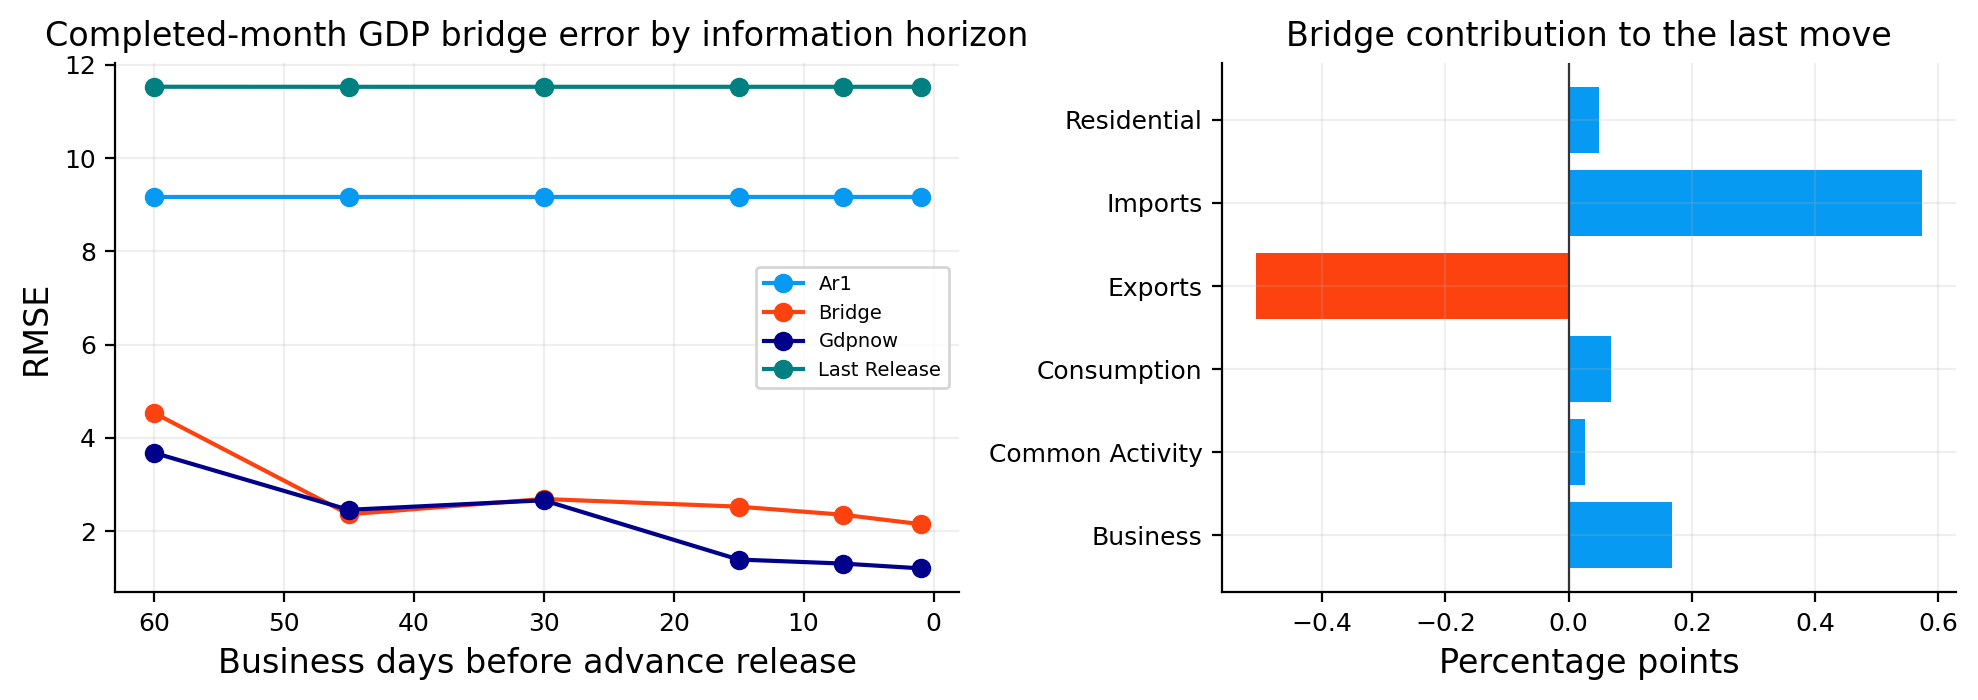

In [17]:
gdp_comparison = bridge_forecasts.merge(
    baseline_forecasts[baseline_forecasts["target"].eq("real_gdp")][
        ["observation_date", "evaluation_date", "horizon", "last_release", "ar1"]],
    on=["observation_date", "evaluation_date", "horizon"], how="left").merge(
        gdpnow_aligned, on=["observation_date", "evaluation_date"], how="left")
gdp_comparison = gdp_comparison.query("release_date >= @SCORE_START")

gdp_score_rows = []
for horizon, sample in gdp_comparison.groupby("horizon"):
    scores = forecast_metrics(sample, y_col="actual",
                              prediction_cols=["last_release", "ar1", "bridge", "gdpnow"]).reset_index()
    scores["horizon"] = horizon
    gdp_score_rows.append(scores)
gdp_scores = pd.concat(gdp_score_rows, ignore_index=True)

component_score_rows = []
for component in component_variables:
    forecasts = bridge_components[bridge_components["component"].eq(component)].merge(
        component_truth[["observation_date", component]], on="observation_date", how="left")
    error = forecasts["forecast"] - forecasts[component]
    component_score_rows.append({"component": component, "observations": error.notna().sum(),
                                 "RMSE": np.sqrt(np.nanmean(np.square(error))),
                                 "MAE": np.nanmean(np.abs(error)), "bias": np.nanmean(error)})
component_scores = pd.DataFrame(component_score_rows).set_index("component")

movement_quarter = path_quarter
movement_source = bridge_components[bridge_components["observation_date"].eq(movement_quarter)]
movement_dates = movement_source["evaluation_date"].drop_duplicates().sort_values().tail(2).tolist()
movement = movement_source[movement_source["evaluation_date"].isin(movement_dates)].pivot_table(
    index="component", columns="evaluation_date", values="contribution")
movement["change"] = movement.iloc[:, -1] - movement.iloc[:, 0]
display(gdp_scores.set_index(["horizon", "model"]), component_scores, movement)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [1.15, 1]})
for model, scores in gdp_scores.groupby("model"):
    axes[0].plot(scores["horizon"], scores["RMSE"], marker="o", label=model.replace("_", " ").title())
axes[0].invert_xaxis()
axes[0].set_title("Completed-month GDP bridge error by information horizon")
axes[0].set_xlabel("Business days before advance release")
axes[0].set_ylabel("RMSE")
axes[0].legend()
colors = [palette[0] if value >= 0 else palette[1] for value in movement["change"]]
axes[1].barh(movement.index.str.replace("_", " ").str.title(), movement["change"], color=colors)
axes[1].axvline(0, color="#333333", linewidth=0.8)
axes[1].set_title("Bridge contribution to the last move")
axes[1].set_xlabel("Percentage points")
plt.tight_layout()
plt.show()

,series_loading,state_order,orientation_anchor
global,25,2,INDPRO
activity,13,1,INDPRO
labor,5,1,PAYEMS
inflation,4,1,CPIULFSL
financial,3,1,GS10


,explained_variance,cumulative_variance
generic_factors,,
1,0.3606,0.3606
2,0.1414,0.5019
3,0.1048,0.6067
4,0.0725,0.6792
5,0.0506,0.7299
6,0.0443,0.7741
7,0.0379,0.8121
8,0.0327,0.8447


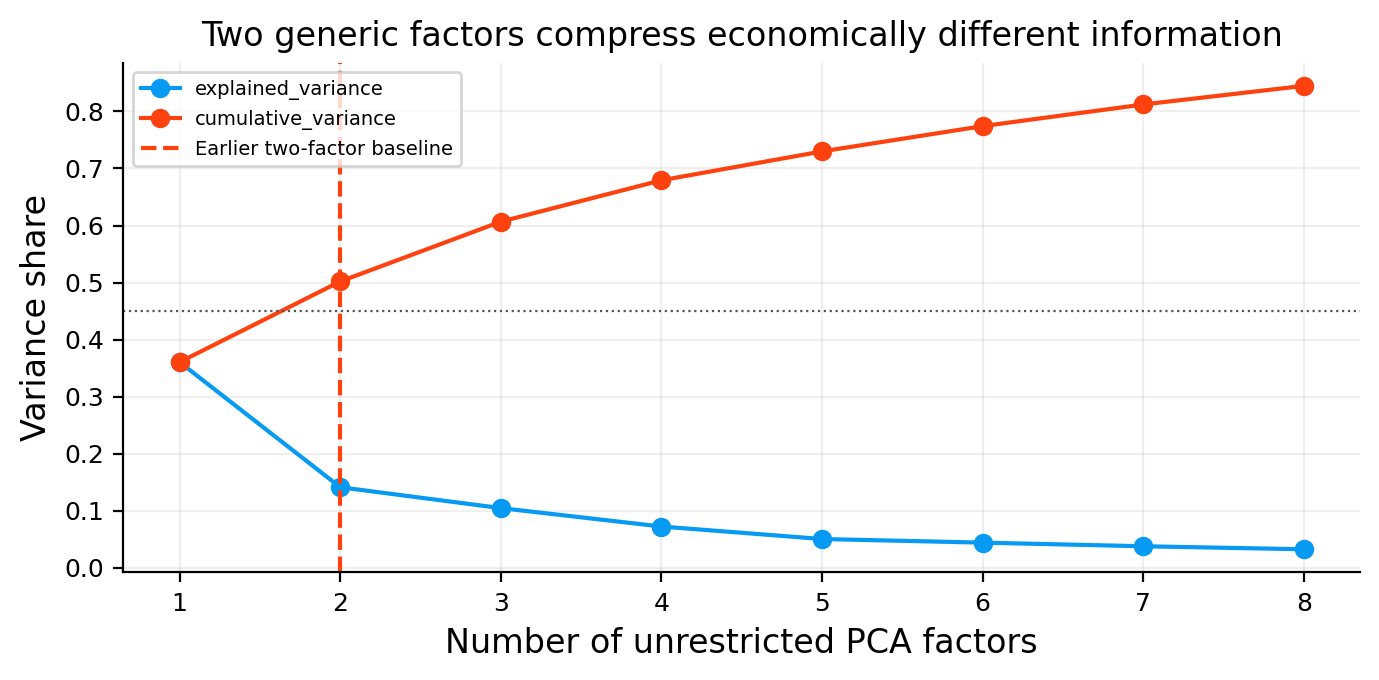

In [18]:
DFM_SERIES = ("RPI", "W875RX1", "CMRMTSPLx", "RETAILx", "INDPRO", "IPFPNSS",
              "CUMFNS", "PAYEMS", "CLAIMSx", "UNRATE", "AWHMAN", "AWOTMAN",
              "HOUST", "PERMIT", "ACOGNO", "AMDMNOx", "ANDENOx", "BUSINVx",
              "CPIAUCSL", "CPIULFSL", "PCEPI", "PPICMM", "GS10", "FEDFUNDS",
              "S&P 500")

def fred_transform(values):
    transformed = {}
    codes = values.attrs["transformation"]
    for name in values:
        x = values[name].astype(float)
        code = int(codes[name])
        if code == 1:
            y = x
        elif code == 2:
            y = x.diff()
        elif code == 3:
            y = x.diff().diff()
        elif code == 4:
            y = np.log(x.where(x > 0))
        elif code == 5:
            y = 100 * np.log(x.where(x > 0)).diff()
        elif code == 6:
            y = 100 * np.log(x.where(x > 0)).diff().diff()
        else:
            y = 100 * x.pct_change(fill_method=None).diff()
        transformed[name] = y
    return pd.DataFrame(transformed)

DFM_FACTOR_MAP = {}
for name in DFM_SERIES:
    family = fred_family(name)
    factors = ["global"]
    if family in {"Output and activity", "Spending and inventories", "Housing"}:
        factors.append("activity")
    elif family == "Labor":
        factors.append("labor")
    elif family == "Prices":
        factors.append("inflation")
    else:
        factors.append("financial")
    DFM_FACTOR_MAP[name] = factors
DFM_FACTOR_ORDERS = {"global": 2, "activity": 1, "labor": 1,
                     "inflation": 1, "financial": 1}
DFM_FACTORS = tuple(DFM_FACTOR_ORDERS)
DFM_ANCHORS = {"global": "INDPRO", "activity": "INDPRO", "labor": "PAYEMS",
               "inflation": "CPIULFSL", "financial": "GS10"}

pre_sample_raw = fred_panel_asof("2014-01-15", "MD", DFM_SERIES)
pre_sample = fred_transform(pre_sample_raw).loc["1999-01-01":"2013-12-01"]
pre_median = pre_sample.median()
pre_mad = (pre_sample - pre_median).abs().median().replace(0, np.nan)
pre_z = ((pre_sample - pre_median) / (1.4826 * pre_mad)).clip(-8, 8)
pre_complete = pre_z.fillna(pre_z.median()).dropna(axis=1)
pca = PCA().fit(pre_complete)
cumvar = pca.explained_variance_ratio_.cumsum()

factor_design = pd.DataFrame({
    "series_loading": [sum(name in factors for factors in DFM_FACTOR_MAP.values())
                       for name in DFM_FACTORS],
    "state_order": list(DFM_FACTOR_ORDERS.values()),
    "orientation_anchor": [DFM_ANCHORS[name] for name in DFM_FACTORS]}, index=DFM_FACTORS)
factor_selection = pd.DataFrame({"explained_variance": pca.explained_variance_ratio_[:8],
                                 "cumulative_variance": cumvar[:8]},
                                index=pd.Index(range(1, 9), name="generic_factors"))
display(factor_design, factor_selection)

ax = factor_selection.plot(y=["explained_variance", "cumulative_variance"], marker="o",
                           figsize=(7, 3.5))
ax.axvline(2, color=palette[1], linestyle="--", label="Earlier two-factor baseline")
ax.axhline(0.45, color="#555555", linewidth=0.8, linestyle=":")
ax.set_title("Two generic factors compress economically different information")
ax.set_xlabel("Number of unrestricted PCA factors")
ax.set_ylabel("Variance share")
ax.legend()
plt.tight_layout()
plt.show()

,ordinary_max_abs_z,robust_max_abs_z,full_sample_capped_share
PAYEMS,93.6053,8.0000,0.0228
UNRATE,65.6530,8.0000,0.0152
CLAIMSx,60.9385,8.0000,0.0190
IPFPNSS,24.3910,8.0000,0.0114
CUMFNS,22.3275,8.0000,0.0114
INDPRO,20.8562,8.0000,0.0152
RPI,18.2080,8.0000,0.0342
RETAILx,16.6326,8.0000,0.0190
CMRMTSPLx,15.8455,8.0000,0.0114
AWOTMAN,10.7443,7.4194,0.0000


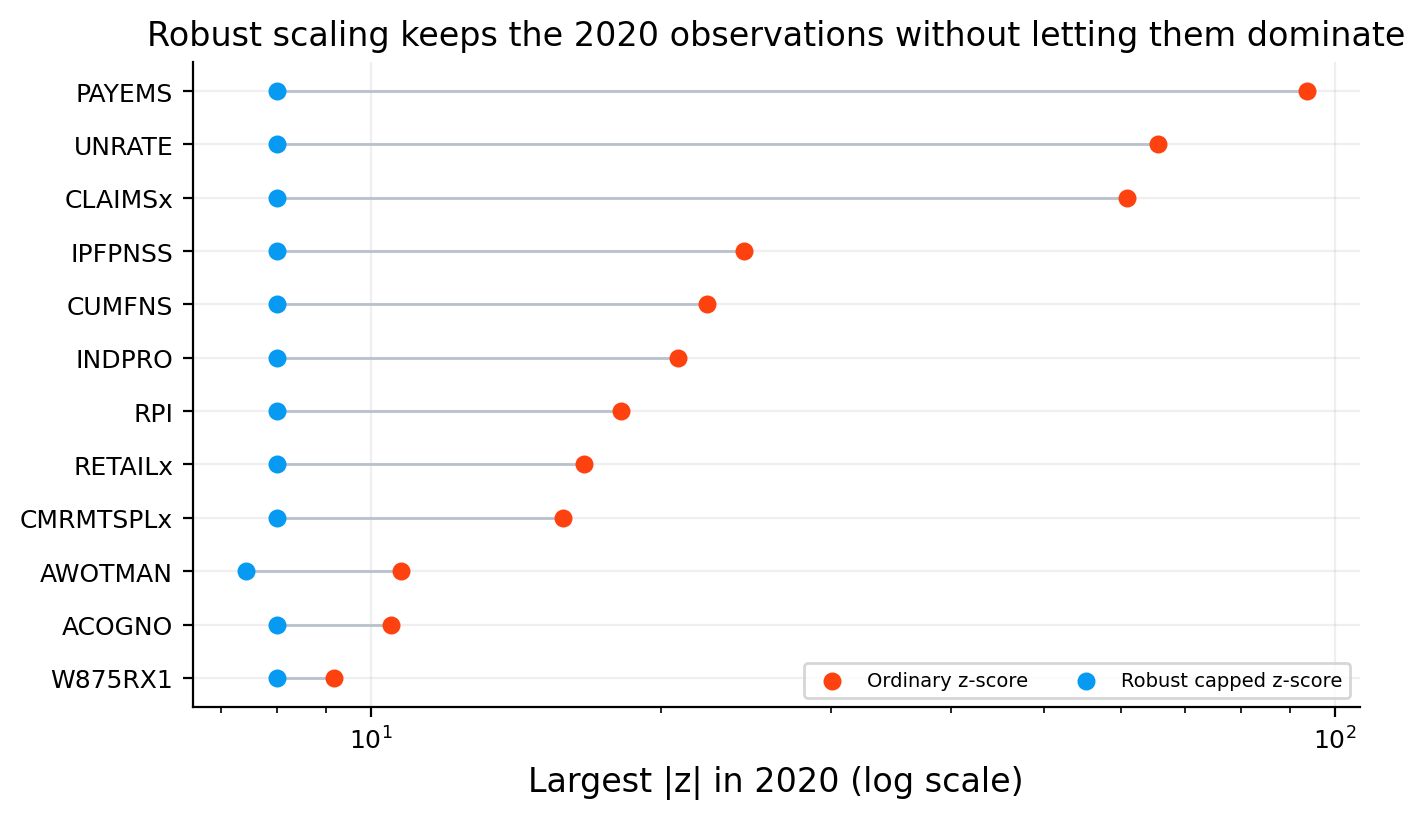

In [19]:
def robust_standardize(values, training_end, cap=8.0):
    training = values.loc[:pd.Timestamp(training_end)]
    location = training.median()
    scale = 1.4826 * (training - location).abs().median()
    scale = scale.where(scale.gt(0) & np.isfinite(scale), training.std(ddof=0))
    scale = scale.where(scale.gt(0) & np.isfinite(scale), 1)
    raw_z = (values - location) / scale
    z = raw_z.clip(-cap, cap)
    capped = raw_z.abs().gt(cap).mean()
    return z, location, scale, capped

pandemic_raw = fred_panel_asof("2021-01-15", "MD", DFM_SERIES)
pandemic_changes = fred_transform(pandemic_raw).loc["1999-01-01":]
ordinary_train = pandemic_changes.loc[:"2019-12-01"]
ordinary_z = (pandemic_changes - ordinary_train.mean()) / ordinary_train.std(ddof=0)
robust_z, _, _, capped_share = robust_standardize(pandemic_changes, "2019-12-01")

shock_comparison = pd.DataFrame({
    "ordinary_max_abs_z": ordinary_z.loc["2020-01-01":"2020-12-01"].abs().max(),
    "robust_max_abs_z": robust_z.loc["2020-01-01":"2020-12-01"].abs().max(),
    "full_sample_capped_share": capped_share}).sort_values("ordinary_max_abs_z", ascending=False)
display(shock_comparison.head(12))

shown_shocks = shock_comparison.head(12).sort_values("ordinary_max_abs_z")
fig, ax = plt.subplots(figsize=(7, 4.2))
positions = np.arange(len(shown_shocks))
for position, row in enumerate(shown_shocks.itertuples()):
    ax.plot([row.robust_max_abs_z, row.ordinary_max_abs_z], [position, position],
            color="#B8C2CC", linewidth=1)
ax.scatter(shown_shocks["ordinary_max_abs_z"], positions, color=palette[1],
           s=30, label="Ordinary z-score", zorder=3)
ax.scatter(shown_shocks["robust_max_abs_z"], positions, color=palette[0],
           s=30, label="Robust capped z-score", zorder=3)
ax.set_xscale("log")
ax.set_yticks(positions)
ax.set_yticklabels(shown_shocks.index)
ax.set_title("Robust scaling keeps the 2020 observations without letting them dominate")
ax.set_xlabel("Largest |z| in 2020 (log scale)")
ax.set_ylabel("")
ax.legend(ncol=2, loc="lower right")
plt.tight_layout()
plt.show()

In [20]:
dfm_series_sql = ", ".join(f"'{name}'" for name in DFM_SERIES)
dfm_archive = con.execute(f"""
    SELECT vintage_date, observation_date, series_id, value, transformation
    FROM fred_vintages
    WHERE panel = 'MD' AND vintage_date >= DATE '2012-01-01'
      AND observation_date >= DATE '1997-01-01'
      AND series_id IN ({dfm_series_sql})
    ORDER BY vintage_date, observation_date, series_id
""").fetchdf()
dfm_vintage_dates = pd.DatetimeIndex(dfm_archive["vintage_date"].drop_duplicates())
dfm_factor_map = DFM_FACTOR_MAP | {"real_gdp": ["global", "activity"]}
dfm_alfred_series = tuple(name for name in DFM_SERIES if name in alfred_by_series)

@lru_cache(maxsize=256)
def dfm_snapshot(vintage_text):
    vintage_date = pd.Timestamp(vintage_text)
    source = dfm_archive[dfm_archive["vintage_date"].eq(vintage_date)]
    values = source.pivot(index="observation_date", columns="series_id", values="value").sort_index()
    values.attrs["vintage_date"] = vintage_date
    values.attrs["transformation"] = source.groupby("series_id")["transformation"].first().to_dict()
    return values

def gdp_vintage(as_of):
    history = target_truth[target_truth["target"].eq("real_gdp")
                           & target_truth["release_date"].le(pd.Timestamp(as_of))
                           & target_truth["observation_date"].ge("2000-01-01")].copy()
    history.index = history["observation_date"].dt.to_period("Q")
    return history["first"]

refit_dates = pd.date_range("2013-01-01", "2025-01-01", freq="2YS")
dfm_regimes = {}
refit_rows = []
for refit_date in refit_dates:
    month_start = refit_date.to_period("M").start_time
    position = dfm_vintage_dates.searchsorted(month_start, side="left") - 1
    raw = dfm_snapshot(str(dfm_vintage_dates[position].date()))
    transformed = fred_transform(raw).loc["2000-01-01":].reindex(columns=DFM_SERIES)
    z, location, scale, capped = robust_standardize(transformed, transformed.index.max())
    z = z.asfreq("MS")
    gdp = gdp_vintage(refit_date)
    gdp_location = gdp.median()
    gdp_scale = 1.4826 * (gdp - gdp_location).abs().median()
    gdp_z = ((gdp - gdp_location) / gdp_scale).to_frame("real_gdp")
    model = DynamicFactorMQ(z, endog_quarterly=gdp_z, factors=dfm_factor_map,
                            factor_orders=DFM_FACTOR_ORDERS, idiosyncratic_ar1=False,
                            standardize=False, obs_cov_diag=True)
    filled = z.interpolate(limit_direction="both").fillna(0)
    initial_model = DynamicFactorMQ(filled, endog_quarterly=gdp_z, factors=dfm_factor_map,
                                    factor_orders=DFM_FACTOR_ORDERS,
                                    idiosyncratic_ar1=False, standardize=False,
                                    obs_cov_diag=True)
    result = model.fit(start_params=initial_model.start_params,
                       maxiter=100, tolerance=1e-4, disp=False)
    fitted_factors = result.factors.filtered[list(DFM_FACTORS)]
    fitted_factors.index = fitted_factors.index.to_timestamp()
    signs = pd.Series(index=DFM_FACTORS, dtype=float)
    for factor, anchor in DFM_ANCHORS.items():
        correlation = fitted_factors[factor].corr(transformed[anchor].reindex(fitted_factors.index))
        signs[factor] = np.sign(correlation) or 1
    dfm_regimes[pd.Timestamp(refit_date)] = {
        "params": result.params.copy(), "location": location, "scale": scale,
        "gdp_location": gdp_location, "gdp_scale": gdp_scale,
        "signs": signs, "iterations": int(result.mle_retvals["iter"]),
        "log_likelihood": result.llf, "last_observation": transformed.index.max()}
    refit_rows.append({"refit_date": refit_date, "snapshot": raw.attrs["vintage_date"],
                       "last_observation": transformed.index.max(),
                       "latest_known_gdp": gdp.index.max(),
                       "iterations": int(result.mle_retvals["iter"]),
                       "log_likelihood": result.llf, "capped_share": capped.mean()})
dfm_refits = pd.DataFrame(refit_rows).set_index("refit_date")

@lru_cache(maxsize=256)
def _dfm_state(vintage_text, regime_text, gdp_cutoff_text):
    vintage_date = pd.Timestamp(vintage_text)
    regime_date = pd.Timestamp(regime_text)
    regime = dfm_regimes[regime_date]
    raw = dfm_snapshot(str(vintage_date.date()))
    transformed = fred_transform(raw).loc["2000-01-01":].reindex(columns=DFM_SERIES)
    z = ((transformed - regime["location"]) / regime["scale"]).clip(-8, 8).asfreq("MS")
    gdp = gdp_vintage(gdp_cutoff_text)
    gdp_z = ((gdp - regime["gdp_location"]) / regime["gdp_scale"]).to_frame("real_gdp")
    model = DynamicFactorMQ(z, endog_quarterly=gdp_z, factors=dfm_factor_map,
                            factor_orders=DFM_FACTOR_ORDERS, idiosyncratic_ar1=False,
                            standardize=False, obs_cov_diag=True)
    result = model.smooth(regime["params"])
    factors = result.factors.filtered[list(DFM_FACTORS)].mul(regime["signs"], axis=1)
    factors.index = factors.index.to_timestamp()
    factors.attrs["snapshot"] = vintage_date
    factors.attrs["regime"] = regime_date
    return factors

def dfm_state(as_of):
    date = pd.Timestamp(as_of)
    month_start = date.to_period("M").start_time
    position = dfm_vintage_dates.searchsorted(month_start, side="left") - 1
    vintage_date = dfm_vintage_dates[position]
    regime_date = max(refit for refit in dfm_regimes if refit <= date)
    gdp_cutoff = target_truth[target_truth["target"].eq("real_gdp")
                              & target_truth["release_date"].le(date)]["release_date"].max()
    return _dfm_state(str(vintage_date.date()), str(regime_date.date()), str(gdp_cutoff.date()))

def dfm_model_asof(as_of, target_end, exact_releases=False):
    date = pd.Timestamp(as_of)
    month_start = date.to_period("M").start_time
    position = dfm_vintage_dates.searchsorted(month_start, side="left") - 1
    regime_date = max(refit for refit in dfm_regimes if refit <= date)
    regime = dfm_regimes[regime_date]
    raw = dfm_snapshot(str(dfm_vintage_dates[position].date())).copy()
    codes = raw.attrs["transformation"]
    if exact_releases:
        exact = alfred_asof(date, dfm_alfred_series).pivot(
            index="observation_date", columns="series_id", values="value")
        raw = raw.reindex(raw.index.union(exact.index))
        raw.update(exact)
        raw.attrs["transformation"] = codes
    transformed = fred_transform(raw).loc["2000-01-01":].reindex(columns=DFM_SERIES)
    z = ((transformed - regime["location"]) / regime["scale"]).clip(-8, 8).asfreq("MS")
    end = pd.Timestamp(target_end).to_period("M").to_timestamp()
    z = z.reindex(pd.date_range(z.index.min(), max(z.index.max(), end), freq="MS"))
    gdp = gdp_vintage(date)
    gdp_z = ((gdp - regime["gdp_location"]) / regime["gdp_scale"]).to_frame("real_gdp")
    model = DynamicFactorMQ(z, endog_quarterly=gdp_z, factors=dfm_factor_map,
                            factor_orders=DFM_FACTOR_ORDERS, idiosyncratic_ar1=False,
                            standardize=False, obs_cov_diag=True)
    return model.smooth(regime["params"]), regime

display(dfm_refits)

,snapshot,last_observation,latest_known_gdp,iterations,log_likelihood,capped_share
refit_date,,,,,,
2013-01-01,2012-12-01,2012-11-01,2012Q3,61,"-4,472.6300",0.0041
2015-01-01,2014-12-01,2014-11-01,2014Q3,50,"-5,328.3632",0.0072
2017-01-01,2016-12-01,2016-11-01,2016Q3,72,"-5,965.6564",0.0071
2019-01-01,2018-12-01,2018-11-01,2018Q3,66,"-6,784.7684",0.0069
2021-01-01,2020-12-01,2020-11-01,2020Q3,29,"-9,054.3481",0.0120
2023-01-01,2022-12-01,2022-11-01,2022Q3,46,"-9,113.6009",0.0125
2025-01-01,2024-12-01,2024-11-01,2024Q3,47,"-9,907.6381",0.0122


n      MAE       RMSE  Spearman IC  Directional Accuracy    Bias
target       horizon model                                                                    
core_cpi     1       dfm    144   1.3222     1.8915       0.5713                0.9653 -0.4643
             5       dfm    144   1.3222     1.8915       0.5713                0.9653 -0.4643
             10      dfm    144   1.3447     1.9249       0.5605                0.9653 -0.4548
             20      dfm    144   1.3615     1.9477       0.4813                0.9653 -0.4804
core_pce     1       dfm    146   1.1590     1.6304       0.5041                0.9726 -0.5203
             5       dfm    146   1.1456     1.6144       0.5171                0.9726 -0.5094
             10      dfm    146   1.1461     1.6149       0.5172                0.9726 -0.5099
             20      dfm    146   1.1770     1.6888       0.3666                0.9726 -0.5121
headline_cpi 1       dfm    144   3.6472     5.0464       0.4393                0.7639 -0.0942
             5       dfm    144   3.6472     5.0464       0.4393                0.7639 -0.0942
             10      dfm    144   3.5716     4.9196       0.3564                0.7778  0.0947
             20      dfm    144   3.8854     5.1199       0.2867                0.7083 -0.1860
headline_pce 1       dfm    146   2.0922     2.9348       0.3625                0.7945 -0.1660
             5       dfm    146   2.0474     2.8386       0.4562                0.8014 -0.1434
             10      dfm    146   2.0529     2.8425       0.4540                0.8014 -0.1465
             20      dfm    146   2.0499     2.7905       0.4259                0.8082 -0.2189
payroll      1       dfm    144 344.9002 1,768.1284      -0.0070                0.9306 12.9402
             5       dfm    144 346.1301 1,779.6472       0.0115                0.9306  5.4705
             10      dfm    144 342.2365 1,799.8746       0.0475                0.9306 14.6882
             20      dfm    144 343.2958 1,800.5155       0.0299                0.9236 13.4263
real_gdp     1       dfm     47   2.6970     6.9600       0.0940                0.8936  0.3715
             7       dfm     47   2.6970     6.9600       0.0940                0.8936  0.3715
             15      dfm     47   2.6970     6.9600       0.0940                0.8936  0.3715
             30      dfm     47   2.7332     6.4508       0.1389                0.9149  0.5042
             45      dfm     47   2.6831     6.2743       0.1951                0.8936  0.2588
             60      dfm     47   2.6846     6.2743       0.1951                0.8936  0.2573
unemployment 1       dfm    145   0.2705     0.8918       0.9421                1.0000  0.0547
             5       dfm    145   0.2608     0.8957       0.9490                1.0000  0.0684
             10      dfm    145   0.2589     0.9025       0.9436                1.0000  0.0530
             20      dfm    145   0.3644     1.1976       0.9304                1.0000  0.0445

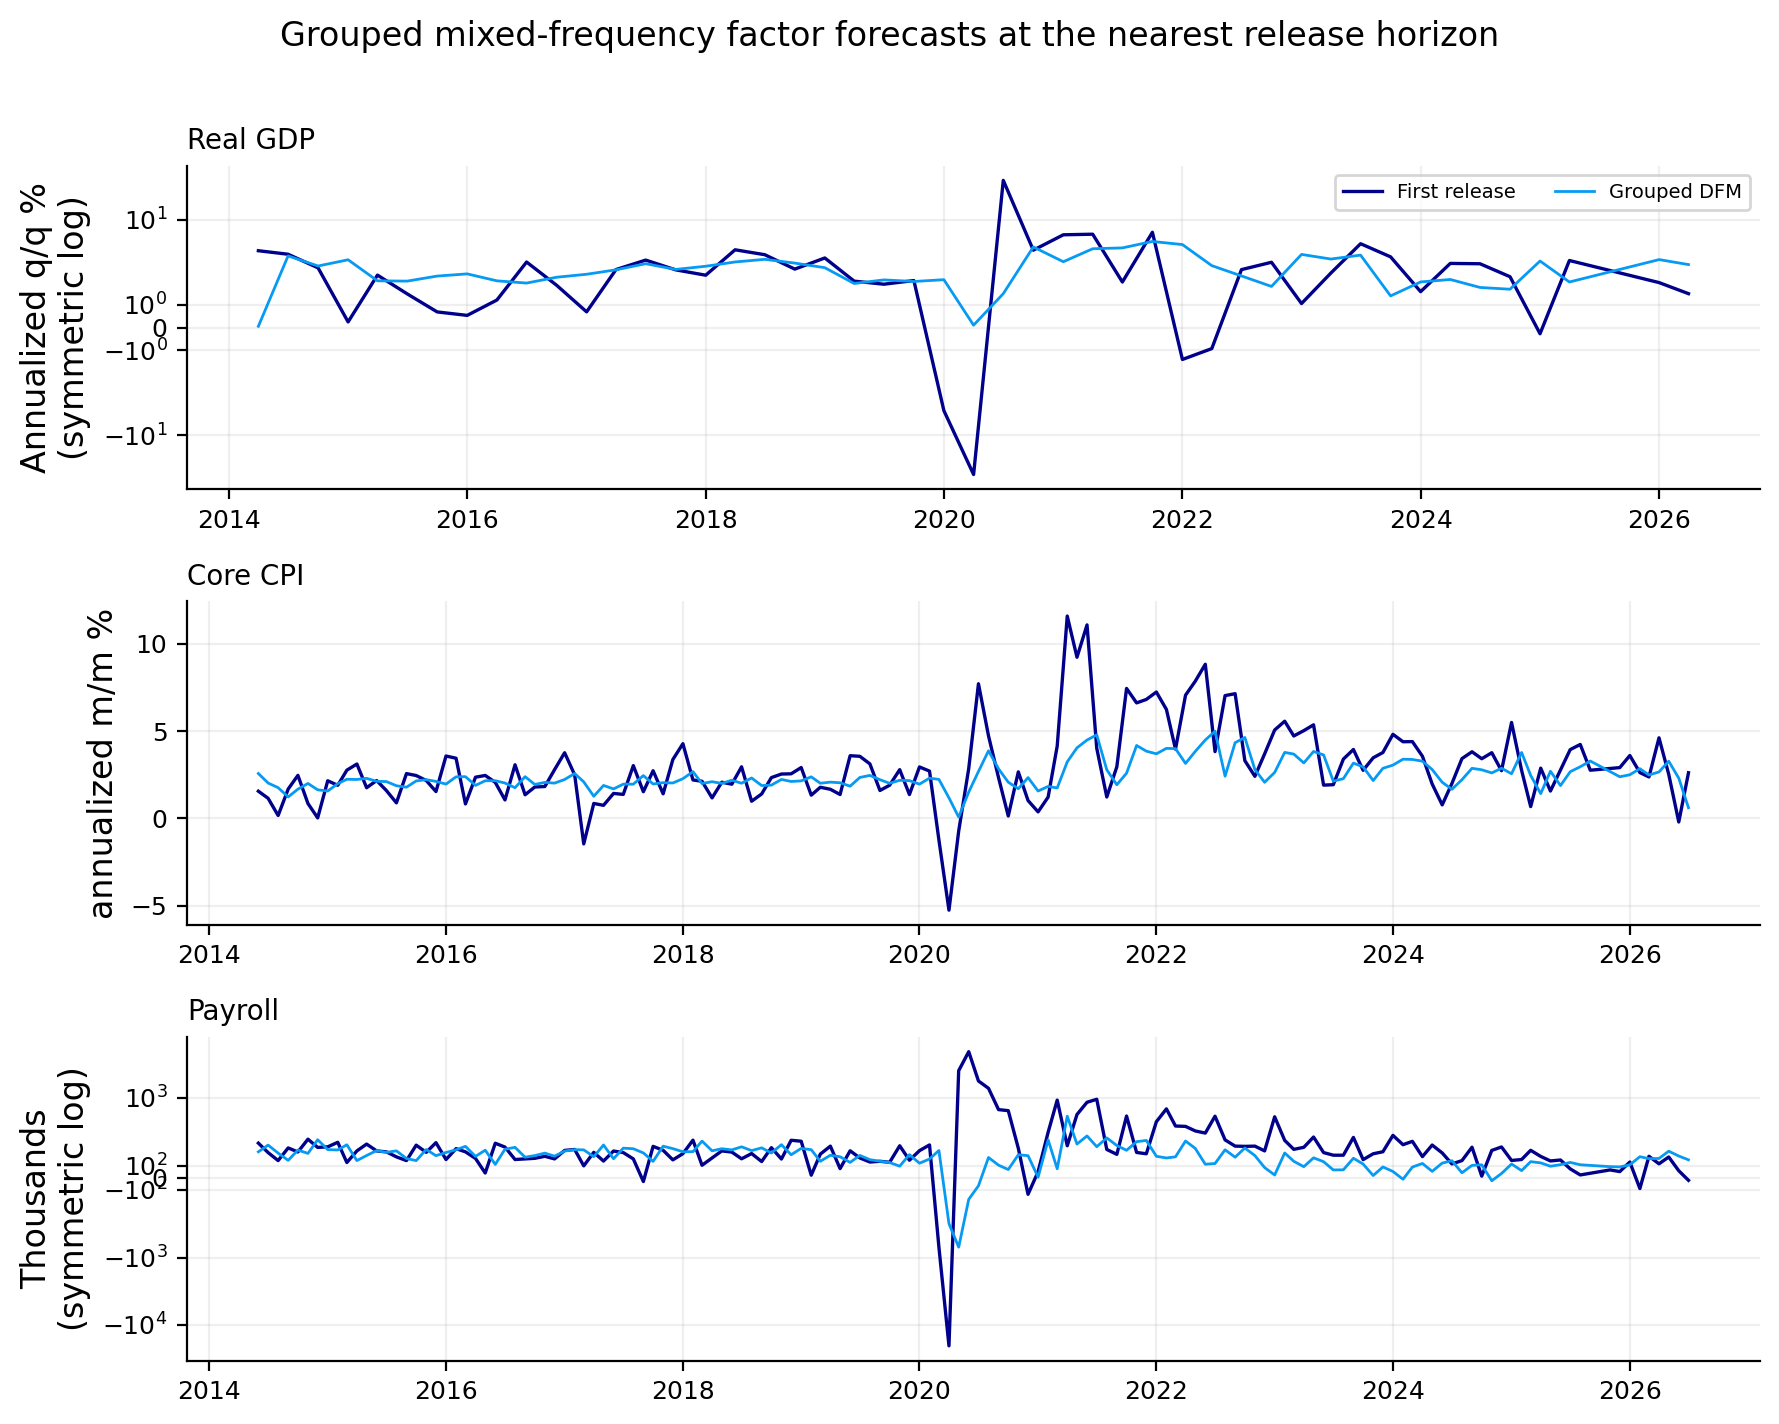

In [21]:
def factor_features(factors, target, observation_date):
    observation_date = pd.Timestamp(observation_date)
    if target == "real_gdp":
        quarter = observation_date.to_period("Q")
        current = factors[factors.index.to_period("Q") == quarter]
        point = current.mean() if len(current) else factors.iloc[-1]
    else:
        eligible = factors.loc[factors.index <= observation_date]
        point = eligible.iloc[-1] if len(eligible) else factors.iloc[-1]
    return point[list(DFM_FACTORS)]

dfm_training_sets = {}

def dfm_training_set(factors, target):
    key = (factors.attrs["snapshot"], factors.attrs["regime"], target)
    if key in dfm_training_sets:
        return dfm_training_sets[key]
    history = target_truth[target_truth["target"].eq(target)
                           & target_truth["observation_date"].ge("2000-01-01")].sort_values(
                               "observation_date").copy()
    if target == "real_gdp":
        quarterly_factors = factors.groupby(factors.index.to_period("Q")).mean()
        periods = history["observation_date"].dt.to_period("Q")
        for name in DFM_FACTORS:
            history[name] = periods.map(quarterly_factors[name])
    else:
        aligned = factors.reindex(pd.DatetimeIndex(history["observation_date"]), method="ffill")
        history[list(DFM_FACTORS)] = aligned.to_numpy()
    history["last_release"] = history["first"].shift(1)
    history = history.rename(columns={"first": "target_value"})
    dfm_training_sets[key] = history
    return history

dfm_rows = []
dfm_feature_names = [*DFM_FACTORS, "last_release"]
for row in evaluation_grid[evaluation_grid["release_date"].ge(SCORE_START)].itertuples():
    factors = dfm_state(row.evaluation_date)
    current = factor_features(factors, row.target, row.observation_date)
    training = dfm_training_set(factors, row.target)
    training = training[training["release_date"].lt(row.evaluation_date)].dropna(
        subset=["target_value", *dfm_feature_names])
    current["last_release"] = training.iloc[-1]["target_value"]
    scaler = StandardScaler().fit(training[dfm_feature_names])
    target_median = training["target_value"].median()
    target_scale = max(1.4826 * (training["target_value"] - target_median).abs().median(), 1e-6)
    sample_weight = 1 / (1 + np.square(
        (training["target_value"] - target_median) / (4 * target_scale)))
    model = Ridge(alpha=5.0).fit(scaler.transform(training[dfm_feature_names]),
                                 training["target_value"], sample_weight=sample_weight)
    current_z = np.clip(scaler.transform(current[dfm_feature_names].to_frame().T), -5, 5)
    prediction = float(model.predict(current_z)[0])
    prediction = float(np.clip(prediction, target_median - 8 * target_scale,
                               target_median + 8 * target_scale))
    residual = training["target_value"] - model.predict(scaler.transform(training[dfm_feature_names]))
    dfm_rows.append({"target": row.target, "observation_date": row.observation_date,
                     "release_date": row.release_date, "evaluation_date": row.evaluation_date,
                     "horizon": row.horizon, "actual": row.actual, "dfm": prediction,
                     "dfm_sigma": residual.tail(60).std(ddof=1)})
dfm_forecasts = pd.DataFrame(dfm_rows)

dfm_score_rows = []
for (target, horizon), sample in dfm_forecasts.groupby(["target", "horizon"]):
    scores = forecast_metrics(sample, y_col="actual", prediction_cols=["dfm"]).reset_index()
    scores["target"] = target
    scores["horizon"] = horizon
    dfm_score_rows.append(scores)
dfm_scores = pd.concat(dfm_score_rows, ignore_index=True)
display(dfm_scores.set_index(["target", "horizon", "model"]))

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=False)
target_names = {"real_gdp": "Real GDP", "core_cpi": "Core CPI", "payroll": "Payroll"}
for ax, target in zip(axes, target_names):
    nearest = dfm_forecasts[dfm_forecasts["target"].eq(target)].sort_values("horizon").drop_duplicates(
        "observation_date", keep="first").sort_values("observation_date").set_index("observation_date")
    ax.plot(nearest.index, nearest["actual"], color=palette[2], linewidth=1.2, label="First release")
    ax.plot(nearest.index, nearest["dfm"], color=palette[0], linewidth=1.0, label="Grouped DFM")
    ax.set_title(target_names[target], loc="left", fontsize=10)
    ax.set_ylabel(target_settings.loc[target, "unit"])
axes[0].set_yscale("symlog", linthresh=3, linscale=0.8)
axes[0].set_ylabel("Annualized q/q %\n(symmetric log)")
axes[2].set_yscale("symlog", linthresh=500, linscale=0.8)
axes[2].set_ylabel("Thousands\n(symmetric log)")
axes[0].legend(ncol=2)
axes[-1].set_xlabel("")
fig.suptitle("Grouped mixed-frequency factor forecasts at the nearest release horizon", y=1.01)
plt.tight_layout()
plt.show()

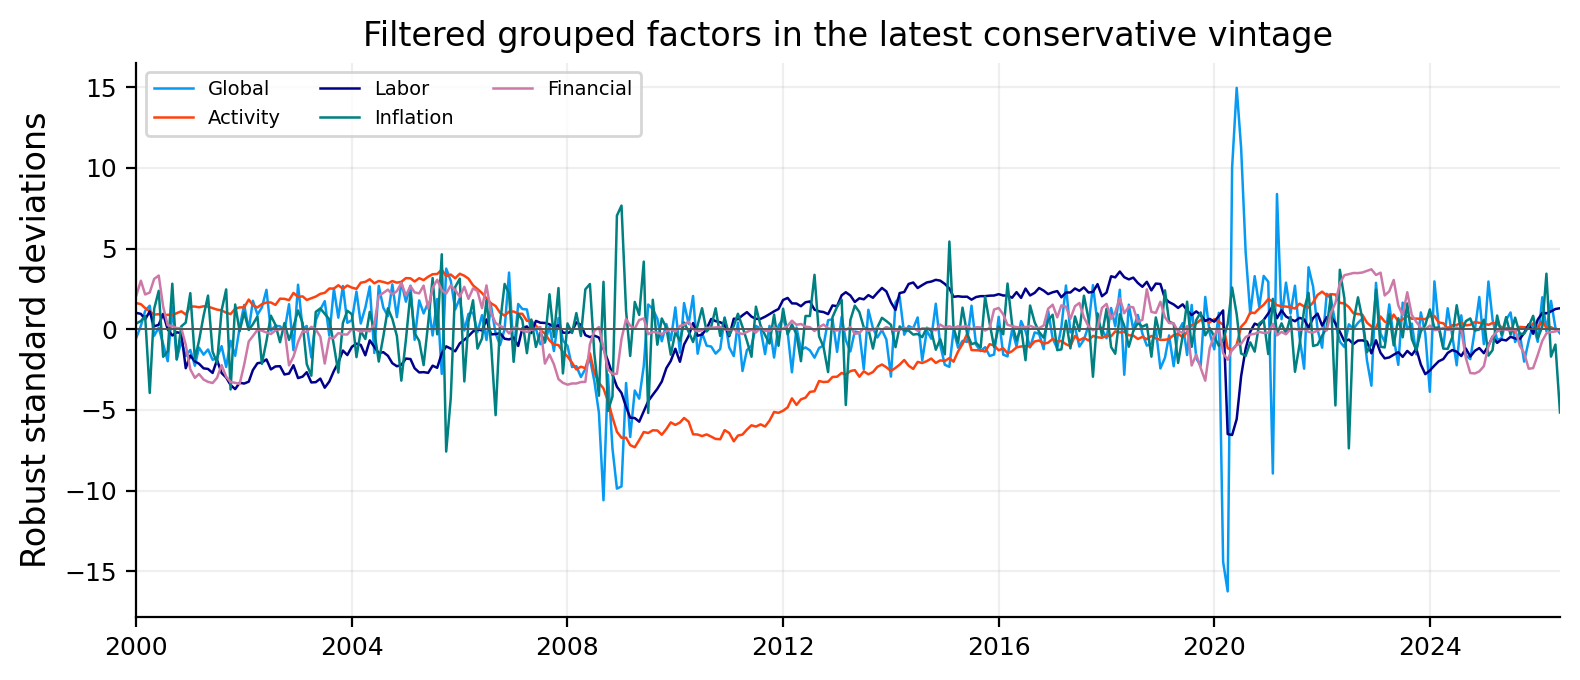

family  loading
factor    series                                
global    CUMFNS    Output and activity   0.5499
          INDPRO    Output and activity   0.5449
          IPFPNSS   Output and activity   0.5099
          PAYEMS                  Labor   0.4934
activity  PERMIT                Housing   0.4192
          HOUST                 Housing   0.3968
          CUMFNS    Output and activity  -0.1492
          INDPRO    Output and activity  -0.1245
labor     AWHMAN                  Labor   0.4146
          PAYEMS                  Labor   0.3209
          UNRATE                  Labor  -0.1213
          AWOTMAN                 Labor   0.0272
inflation CPIAUCSL               Prices   0.7332
          CPIULFSL               Prices   0.7200
          PCEPI                  Prices   0.6004
          PPICMM                 Prices   0.0990
financial FEDFUNDS     Rates and credit   2.1243
          GS10         Rates and credit   0.0938
          S&P 500        Markets and FX   0.0206
          RPI       Output and activity      NaN

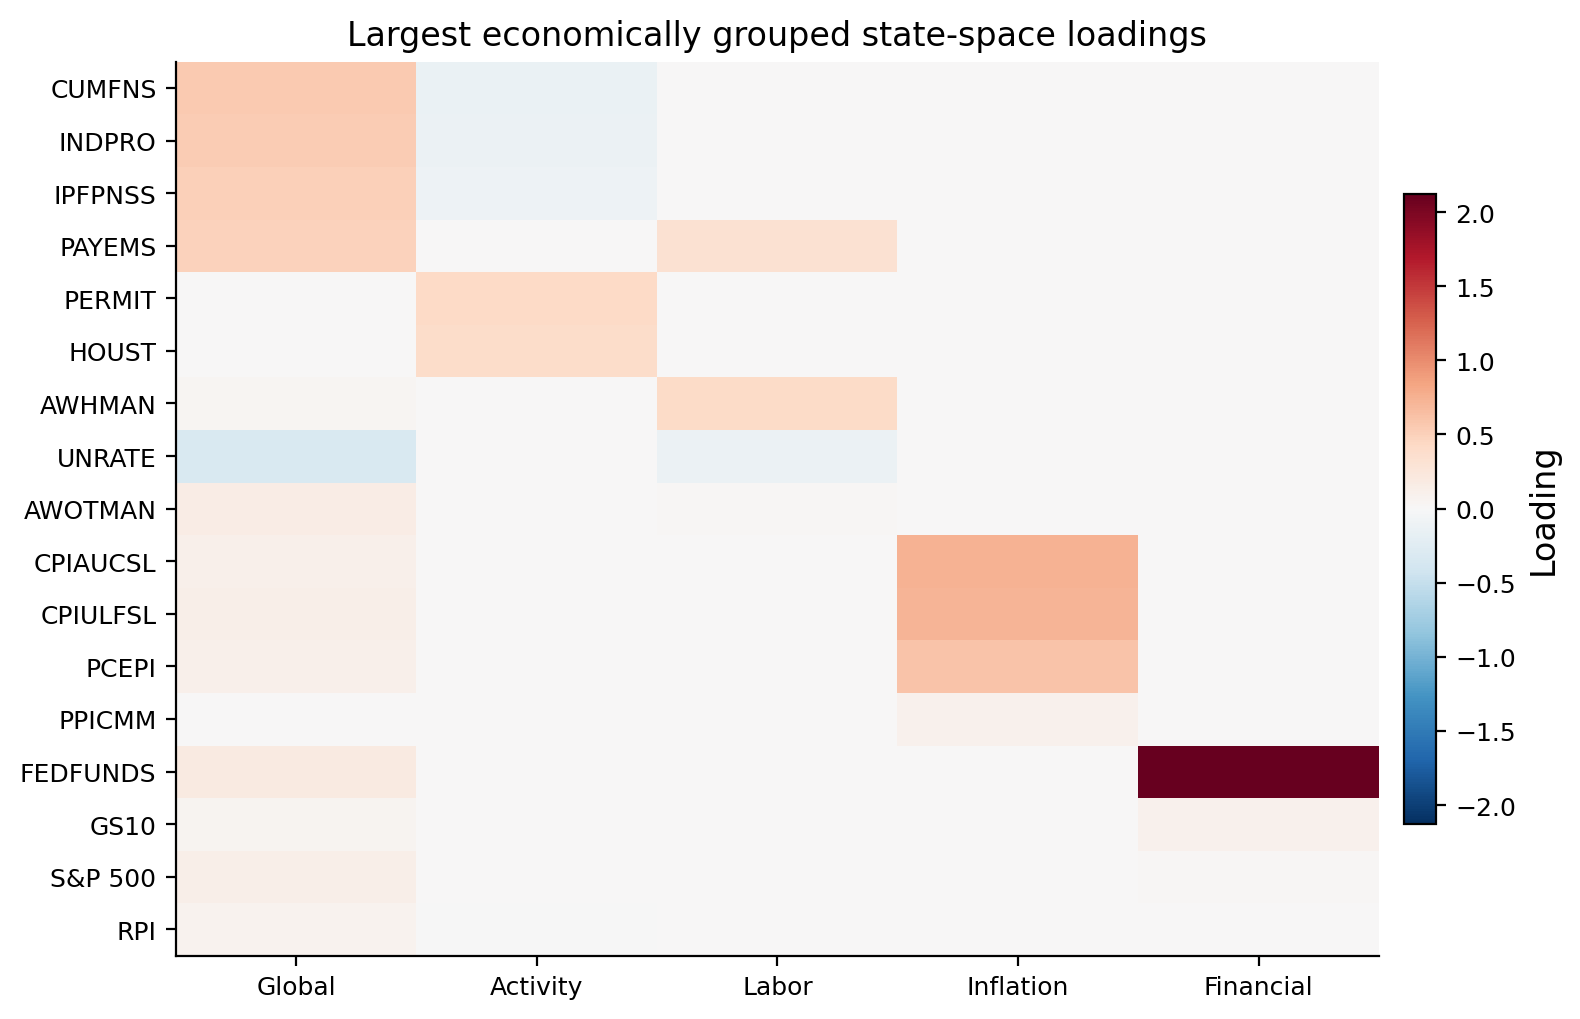

In [22]:
latest_factors = dfm_state(evaluation_grid["evaluation_date"].max())
fig, ax = plt.subplots(figsize=(8, 3.5))
for factor in DFM_FACTORS:
    ax.plot(latest_factors.index, latest_factors[factor], label=factor.title(), linewidth=0.9)
ax.axhline(0, color="#555555", linewidth=0.7)
ax.set_xlim(pd.Timestamp("2000-01-01"), latest_factors.index.max())
ax.set_title("Filtered grouped factors in the latest conservative vintage")
ax.set_xlabel("")
ax.set_ylabel("Robust standard deviations")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

latest_regime = dfm_regimes[latest_factors.attrs["regime"]]
loadings = pd.DataFrame(index=DFM_SERIES, columns=DFM_FACTORS, dtype=float)
for factor in DFM_FACTORS:
    for name in DFM_SERIES:
        loadings.loc[name, factor] = latest_regime["params"].get(
            f"loading.{factor}->{name}", np.nan) * latest_regime["signs"][factor]
loadings["family"] = loadings.index.map(fred_family)

loading_rows = []
for factor in DFM_FACTORS:
    for name, value in loadings[factor].abs().nlargest(4).items():
        loading_rows.append({"factor": factor, "series": name, "family": loadings.loc[name, "family"],
                             "loading": loadings.loc[name, factor]})
loading_table = pd.DataFrame(loading_rows).set_index(["factor", "series"])
display(loading_table)

top_series = pd.Index(pd.concat([loadings[factor].abs().nlargest(4)
                                 for factor in DFM_FACTORS]).index.unique())
loading_heat = loadings.loc[top_series, DFM_FACTORS].fillna(0)
fig, ax = plt.subplots(figsize=(8, 5.2))
limit = loading_heat.abs().to_numpy().max()
image = ax.imshow(loading_heat, aspect="auto", cmap="RdBu_r", vmin=-limit, vmax=limit)
ax.set_xticks(np.arange(len(loading_heat.columns)))
ax.set_xticklabels(loading_heat.columns.str.title())
ax.set_yticks(np.arange(len(loading_heat.index)))
ax.set_yticklabels(loading_heat.index)
ax.set_title("Largest economically grouped state-space loadings")
ax.grid(False)
fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02, label="Loading")
plt.tight_layout()
plt.show()

observations first_date  last_date  median_gap_days
category          series_id    label                                                                                      
breakeven         T10YIE       10-year breakeven inflation                     5919 2003-01-02 2026-08-28           1.0000
                  T5YIE        5-year breakeven inflation                      5919 2003-01-02 2026-08-28           1.0000
financial_control DTWEXBGS     Broad nominal U.S. dollar index                 5174 2006-01-02 2026-08-21           1.0000
                  VIXCLS       CBOE VIX                                        9261 1990-01-02 2026-08-27           1.0000
inflation_input   DCOILBRENTEU Brent crude spot price                          9963 1987-05-20 2026-08-25           1.0000
                  DCOILWTICO   WTI crude spot price challenger                10231 1986-01-02 2026-08-25           1.0000
                  GASREGW      U.S. regular retail gasoline price              1874 1990-08-20 2026-08-24           7.0000
nominal_rate      DGS10        10-year Treasury constant maturity             16149 1962-01-02 2026-08-27           1.0000
                  DGS2         2-year Treasury constant maturity              12557 1976-06-01 2026-08-27           1.0000
                  DGS5         5-year Treasury constant maturity              16149 1962-01-02 2026-08-27           1.0000
policy_rate       DFEDTARL     Federal funds target range lower limit          6465 2008-12-16 2026-08-28           1.0000
                  DFEDTARU     Federal funds target range upper limit          6465 2008-12-16 2026-08-28           1.0000
                  DFF          Effective federal funds rate                   26356 1954-07-01 2026-08-27           1.0000
                  SOFR         Secured Overnight Financing Rate                2099 2018-04-03 2026-08-27           1.0000
real_rate         DFII10       10-year TIPS constant maturity                  5918 2003-01-02 2026-08-27           1.0000
                  DFII5        5-year TIPS constant maturity                   5918 2003-01-02 2026-08-27           1.0000

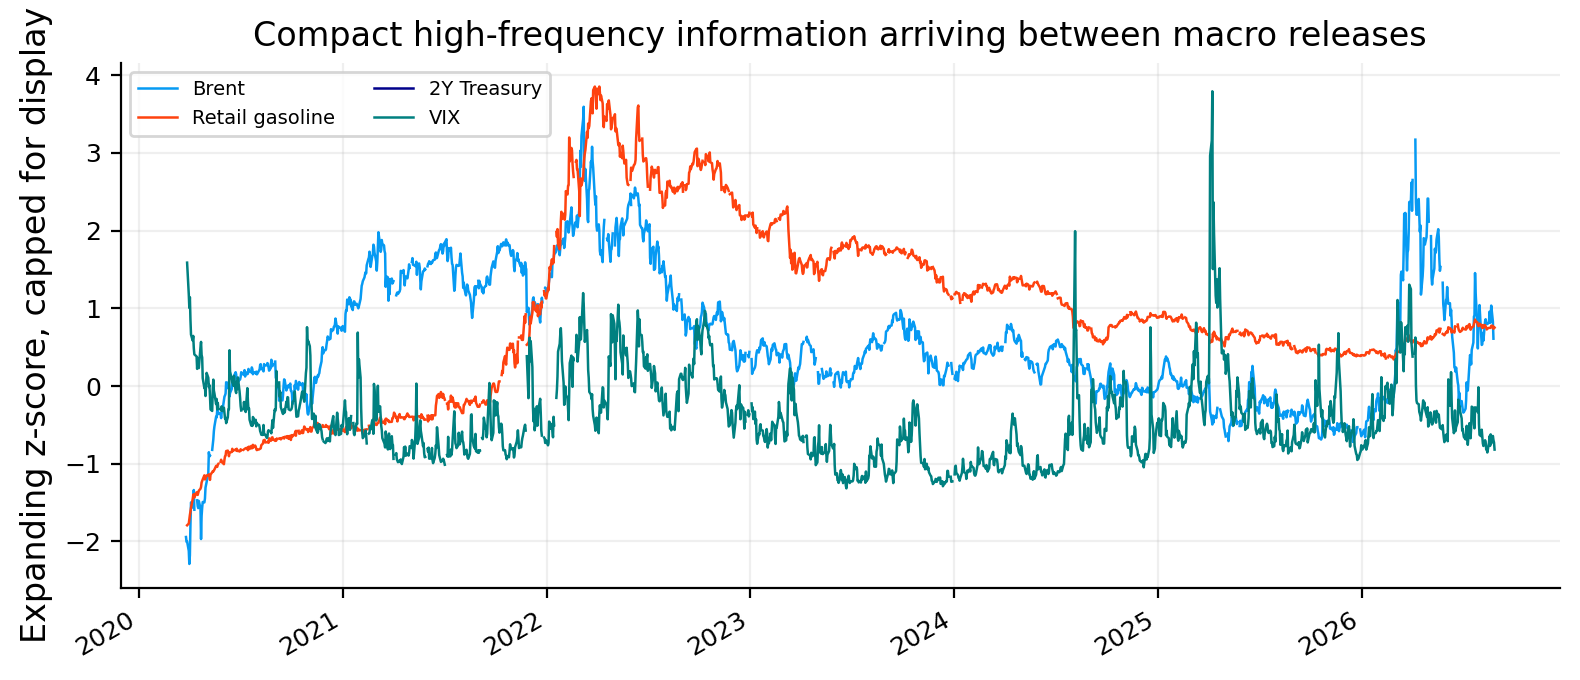

In [23]:
high_frequency = pd.read_parquet(HIGH_FREQUENCY_PATH)
high_frequency["date"] = pd.to_datetime(high_frequency["date"])
high_frequency = high_frequency.sort_values(["series_id", "date"]).reset_index(drop=True)
assert high_frequency["series_id"].nunique() == 16
assert not high_frequency.duplicated(["series_id", "date"]).any()
assert np.isfinite(high_frequency["value"]).all()

high_frequency_audit = high_frequency.groupby(["category", "series_id", "label"]).agg(
    observations=("value", "size"), first_date=("date", "min"), last_date=("date", "max"),
    median_gap_days=("date", lambda x: x.sort_values().diff().dt.days.median())).sort_index()
display(high_frequency_audit)

market_view = high_frequency[high_frequency["series_id"].isin(
    ["DCOILBRENTEU", "GASREGW", "DGS2", "VIXCLS"])].pivot(
        index="date", columns="series_id", values="value").loc["2020-01-01":]
market_z = market_view.apply(lambda series: expanding_zscore(
    series, min_history=60, clip=5))
ax = market_z.clip(-5, 5).plot(figsize=(8, 3.5), linewidth=0.9)
ax.set_title("Compact high-frequency information arriving between macro releases")
ax.set_xlabel("")
ax.set_ylabel("Expanding z-score, capped for display")
ax.legend(["Brent", "Retail gasoline", "2Y Treasury", "VIX"], ncol=2)
plt.tight_layout()
plt.show()

In [24]:
def beta_midas_weights(length, a, b):
    x = (np.arange(length) + 0.5) / length
    log_w = (a - 1) * np.log(x) + (b - 1) * np.log1p(-x)
    weights = np.exp(log_w - log_w.max())
    return weights / weights.sum()

def almon_midas_weights(length, theta_1, theta_2):
    lag = np.arange(length, dtype=float)
    log_w = theta_1 * lag + theta_2 * np.square(lag)
    weights = np.exp(log_w - log_w.max())
    return weights / weights.sum()

def fit_beta_shape(lags, target):
    complete = np.isfinite(lags).all(axis=1) & np.isfinite(target)
    x = lags[complete]
    y = np.asarray(target)[complete]
    def loss(log_shape):
        weights = beta_midas_weights(x.shape[1], *np.exp(log_shape))
        signal = x @ weights
        design = np.column_stack([np.ones(len(signal)), signal])
        fitted = design @ np.linalg.lstsq(design, y, rcond=None)[0]
        return np.mean(np.square(y - fitted))
    fitted = minimize(loss, np.log([1.5, 2.5]), method="L-BFGS-B",
                      bounds=[(np.log(0.25), np.log(10)), (np.log(0.25), np.log(10))])
    return np.exp(fitted.x), fitted.fun

synthetic_lags = rng.normal(size=(400, 12))
synthetic_weights = beta_midas_weights(12, 1.4, 4.2)
synthetic_target = synthetic_lags @ synthetic_weights + rng.normal(scale=0.15, size=400)
synthetic_shape, synthetic_loss = fit_beta_shape(synthetic_lags, synthetic_target)
recovered_weights = beta_midas_weights(12, *synthetic_shape)
midas_sanity = pd.DataFrame({
    "value": [synthetic_weights.sum(), recovered_weights.sum(),
              np.corrcoef(synthetic_weights, recovered_weights)[0, 1],
              synthetic_shape[0], synthetic_shape[1], synthetic_loss]},
    index=["True weight sum", "Recovered weight sum", "Weight correlation",
           "Recovered a", "Recovered b", "Training MSE"])
assert np.isclose(recovered_weights.sum(), 1)
assert midas_sanity.loc["Weight correlation", "value"] > 0.90
display(midas_sanity)

,value
True weight sum,1.0000
Recovered weight sum,1.0000
Weight correlation,0.9986
Recovered a,1.3133
Recovered b,3.9452
Training MSE,0.0242


In [25]:
high_frequency_wide = high_frequency.pivot(index="date", columns="series_id", values="value").sort_index()
weekly_changes = {}
for name in ["DCOILBRENTEU", "GASREGW"]:
    weekly = high_frequency_wide[name].dropna().resample("W-FRI").last()
    weekly_changes[name] = 100 * np.log(weekly.where(weekly > 0)).diff()

def recent_lags(series, as_of, length):
    values = series.loc[series.index <= pd.Timestamp(as_of)].dropna().tail(length)
    if len(values) < length:
        return np.full(length, np.nan)
    return values.iloc[::-1].to_numpy(dtype=float)

def latest_growth(known, series_id, observation_date=None):
    values = known[known["series_id"].eq(series_id)].sort_values("observation_date").set_index(
        "observation_date")["value"]
    if observation_date is not None:
        date = pd.Timestamp(observation_date)
        if date not in values.index:
            return np.nan
        values = values.loc[:date]
    if len(values) < 2 or values.iloc[-1] <= 0 or values.iloc[-2] <= 0:
        return np.nan
    return 1200 * np.log(values.iloc[-1] / values.iloc[-2])

def monthly_market_change(series, as_of, observation_date):
    available = series.loc[series.index <= pd.Timestamp(as_of)]
    month = pd.Timestamp(observation_date).to_period("M")
    current = available[available.index.to_period("M") == month]
    previous = available[available.index.to_period("M") == month - 1]
    if current.empty or previous.empty or current.mean() <= 0 or previous.mean() <= 0:
        return np.nan
    return 1200 * np.log(current.mean() / previous.mean())

def ar_forecast(history, window=60, alpha=2.0):
    values = pd.Series(history, dtype=float).dropna().tail(window)
    if len(values) < 18:
        return values.tail(12).mean()
    design = pd.concat([values.rename("y"), values.shift(1).rename("lag")], axis=1).dropna()
    model = Ridge(alpha=alpha).fit(design[["lag"]], design["y"])
    return float(model.predict(pd.DataFrame({"lag": [values.iloc[-1]]}))[0])

midas_rows = []
midas_grid = evaluation_grid[evaluation_grid["target"].isin(
    ["headline_cpi", "payroll", "real_gdp"])
    & evaluation_grid["release_date"].ge("2010-01-01")]
for row in midas_grid.itertuples():
    record = {"target": row.target, "observation_date": row.observation_date,
              "release_date": row.release_date, "evaluation_date": row.evaluation_date,
              "horizon": row.horizon, "actual": row.actual}
    if row.target == "headline_cpi":
        for name in ["DCOILBRENTEU", "GASREGW"]:
            record.update({f"{name}_{lag}": value for lag, value in enumerate(
                recent_lags(weekly_changes[name], row.evaluation_date, 12))})
    elif row.target == "payroll":
        claims = alfred_asof(row.evaluation_date, ("ICSA",)).set_index("observation_date")["value"]
        claims_change = 100 * np.log(claims.where(claims > 0)).diff()
        record.update({f"ICSA_{lag}": value for lag, value in enumerate(
            recent_lags(claims_change, row.evaluation_date, 12))})
    elif row.evaluation_date >= pd.Timestamp("2013-01-01"):
        activity = dfm_state(row.evaluation_date)["activity"]
        record.update({f"activity_{lag}": value for lag, value in enumerate(
            recent_lags(activity, row.evaluation_date, 6))})
    midas_rows.append(record)
midas_design = pd.DataFrame(midas_rows)

midas_predictors = {"Brent": ("headline_cpi", "DCOILBRENTEU", 12),
                    "Retail gasoline": ("headline_cpi", "GASREGW", 12),
                    "Initial claims": ("payroll", "ICSA", 12),
                    "DFM activity": ("real_gdp", "activity", 6)}
midas_shape_rows = []
midas_shapes = {}
for label, (target, prefix, length) in midas_predictors.items():
    sample = midas_design[midas_design["target"].eq(target)
                          & midas_design["release_date"].lt(SCORE_START)]
    columns = [f"{prefix}_{lag}" for lag in range(length)]
    complete = sample.dropna(subset=columns)
    shape, loss = fit_beta_shape(complete[columns].to_numpy(), complete["actual"].to_numpy())
    midas_shapes[prefix] = beta_midas_weights(length, *shape)
    midas_shape_rows.append({"input": label, "target": target, "lags": length,
                             "a": shape[0], "b": shape[1], "pre_sample_mse": loss,
                             "effective_lag": np.dot(np.arange(length), midas_shapes[prefix])})
midas_shape_table = pd.DataFrame(midas_shape_rows).set_index("input")

component_ids = {"core": "CPILFESL", "food": "CPIUFDSL",
                 "gasoline": "CUSR0000SETB01"}
component_frames = []
for component, series_id in component_ids.items():
    history = alfred_first_growth(series_id, component)[
        ["observation_date", "release_date", "first"]]
    component_frames.append(history.rename(columns={"release_date": f"{component}_release",
                                                     "first": component}))
component_history = component_frames[0].merge(component_frames[1], on="observation_date").merge(
    component_frames[2], on="observation_date")
headline_history = target_truth[target_truth["target"].eq("headline_cpi")][
    ["observation_date", "first"]].rename(columns={"first": "headline"})
component_history = component_history.merge(headline_history, on="observation_date")
component_history["release_date"] = component_history[
    ["core_release", "food_release", "gasoline_release"]].max(axis=1)
component_history = component_history.sort_values("observation_date")

cpi_market_rows = []
for past in component_history[component_history["observation_date"].ge("1995-01-01")].itertuples():
    for horizon in MONTHLY_DAYS:
        as_of = past.gasoline_release - pd.offsets.BDay(horizon)
        cpi_market_rows.append({
            "observation_date": past.observation_date, "horizon": horizon,
            "gas_signal": monthly_market_change(high_frequency_wide["GASREGW"], as_of,
                                                 past.observation_date),
            "oil_signal": monthly_market_change(high_frequency_wide["DCOILBRENTEU"], as_of,
                                                 past.observation_date)})
cpi_market = pd.DataFrame(cpi_market_rows)

pce_series = {"headline_pce": ["CPIAUCSL", "CPIUFDSL", "CUSR0000SETB01", "WPSFD49207"],
              "core_pce": ["CPILFESL"]}
pce_rows = []
for row in evaluation_grid[evaluation_grid["target"].isin(pce_series)].itertuples():
    series_ids = tuple(pce_series[row.target])
    known = alfred_asof(row.evaluation_date, series_ids)
    record = {"target": row.target, "observation_date": row.observation_date,
              "release_date": row.release_date, "evaluation_date": row.evaluation_date,
              "horizon": row.horizon, "actual": row.actual}
    for series_id in series_ids:
        record[f"{series_id}_current"] = latest_growth(known, series_id, row.observation_date)
        record[f"{series_id}_latest"] = latest_growth(known, series_id)
        record[f"{series_id}_available"] = float(np.isfinite(record[f"{series_id}_current"]))
    history = target_truth[target_truth["target"].eq(row.target)
                           & target_truth["release_date"].lt(row.evaluation_date)].sort_values(
                               "observation_date")["first"]
    record["last_release"] = history.iloc[-1]
    pce_rows.append(record)
pce_design = pd.DataFrame(pce_rows)
pce_availability = pce_design.assign(current_cpi_available=np.where(
    pce_design["target"].eq("core_pce"), pce_design["CPILFESL_available"],
    pce_design["CPIAUCSL_available"])).groupby(["target", "horizon"])[
        "current_cpi_available"].mean().unstack()
display(midas_shape_table, pce_availability)

,target,lags,a,b,pre_sample_mse,effective_lag
input,,,,,,
Brent,headline_cpi,12,2.3432,2.5236,5.2693,5.2748
Retail gasoline,headline_cpi,12,2.3411,5.3736,5.3394,3.1255
Initial claims,payroll,12,1.1142,1.0950,"11,491.7835",5.5502
DFM activity,real_gdp,6,10.0000,1.9270,2.3083,4.5948


horizon,1,5,10,20
target,,,,
core_pce,0.9965,0.9717,0.6431,0.0283
headline_pce,0.9965,0.9717,0.6431,0.0283


model    n      MAE       RMSE  Spearman IC  Directional Accuracy     Bias
target       horizon method                                                                                            
headline_cpi 1       MIDAS                   midas  144   1.9060     2.5423       0.7326                0.8472  -0.6575
             5       MIDAS                   midas  144   1.8499     2.4614       0.7509                0.8611  -0.7015
             10      MIDAS                   midas  144   1.8667     2.5275       0.7402                0.8750  -0.8008
             20      MIDAS                   midas  144   2.1985     3.1045       0.6070                0.8611  -0.9627
payroll      1       MIDAS                   midas  144 356.4312 1,862.1208       0.0463                0.9653 -15.5047
             5       MIDAS                   midas  144 353.4469 1,836.6199       0.0952                0.9653 -13.3700
             10      MIDAS                   midas  144 351.3212 1,809.2380       0.0705                0.9583 -13.1294
             20      MIDAS                   midas  144 365.3262 1,919.4418      -0.0133                0.9375 -17.8425
real_gdp     1       MIDAS                   midas   47   2.9679     7.7510      -0.1199                0.8511  -0.3930
             7       MIDAS                   midas   47   2.9679     7.7510      -0.1199                0.8511  -0.3930
             15      MIDAS                   midas   47   2.9679     7.7510      -0.1199                0.8511  -0.3930
             30      MIDAS                   midas   47   2.9415     7.5148      -0.1806                0.8511  -0.2577
             45      MIDAS                   midas   47   2.9419     7.5238      -0.1933                0.8511  -0.2373
             60      MIDAS                   midas   47   2.9430     7.5241      -0.1981                0.8511  -0.2381
headline_cpi 1       CPI components  component_cpi  144   1.6206     2.1238       0.7841                0.8819  -0.2172
             5       CPI components  component_cpi  144   1.6206     2.1238       0.7841                0.8819  -0.2172
             10      CPI components  component_cpi  144   1.6229     2.1301       0.7879                0.8819  -0.2291
             20      CPI components  component_cpi  144   1.6369     2.1973       0.7861                0.8681  -0.2663
core_pce     1       CPI→PCE bridge     pce_bridge  146   0.7509     0.9871       0.7333                0.9863  -0.1525
             5       CPI→PCE bridge     pce_bridge  146   0.7637     0.9998       0.7264                0.9863  -0.1615
             10      CPI→PCE bridge     pce_bridge  146   0.7764     1.0277       0.7159                0.9863  -0.1501
             20      CPI→PCE bridge     pce_bridge  146   1.0630     1.4864       0.5348                0.9658  -0.3729
headline_pce 1       CPI→PCE bridge     pce_bridge  146   1.0908     1.5041       0.7858                0.8151  -0.1366
             5       CPI→PCE bridge     pce_bridge  146   1.0968     1.5087       0.7831                0.8151  -0.1487
             10      CPI→PCE bridge     pce_bridge  146   1.2874     1.7453       0.6894                0.8014  -0.1480
             20      CPI→PCE bridge     pce_bridge  146   1.7096     2.2764       0.4858                0.8082  -0.1845

,core_weight,food_weight,gasoline_weight
observation_date,,,
2026-07-01,0.7510,0.2116,0.0374


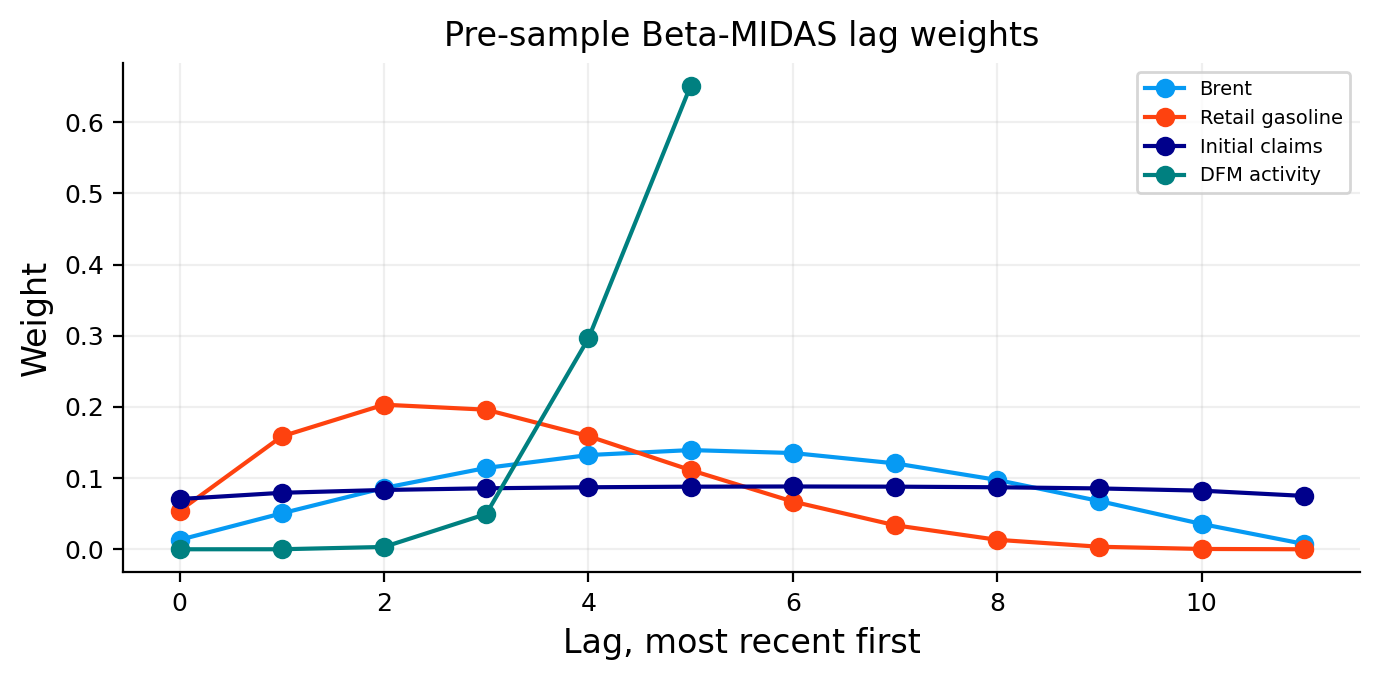

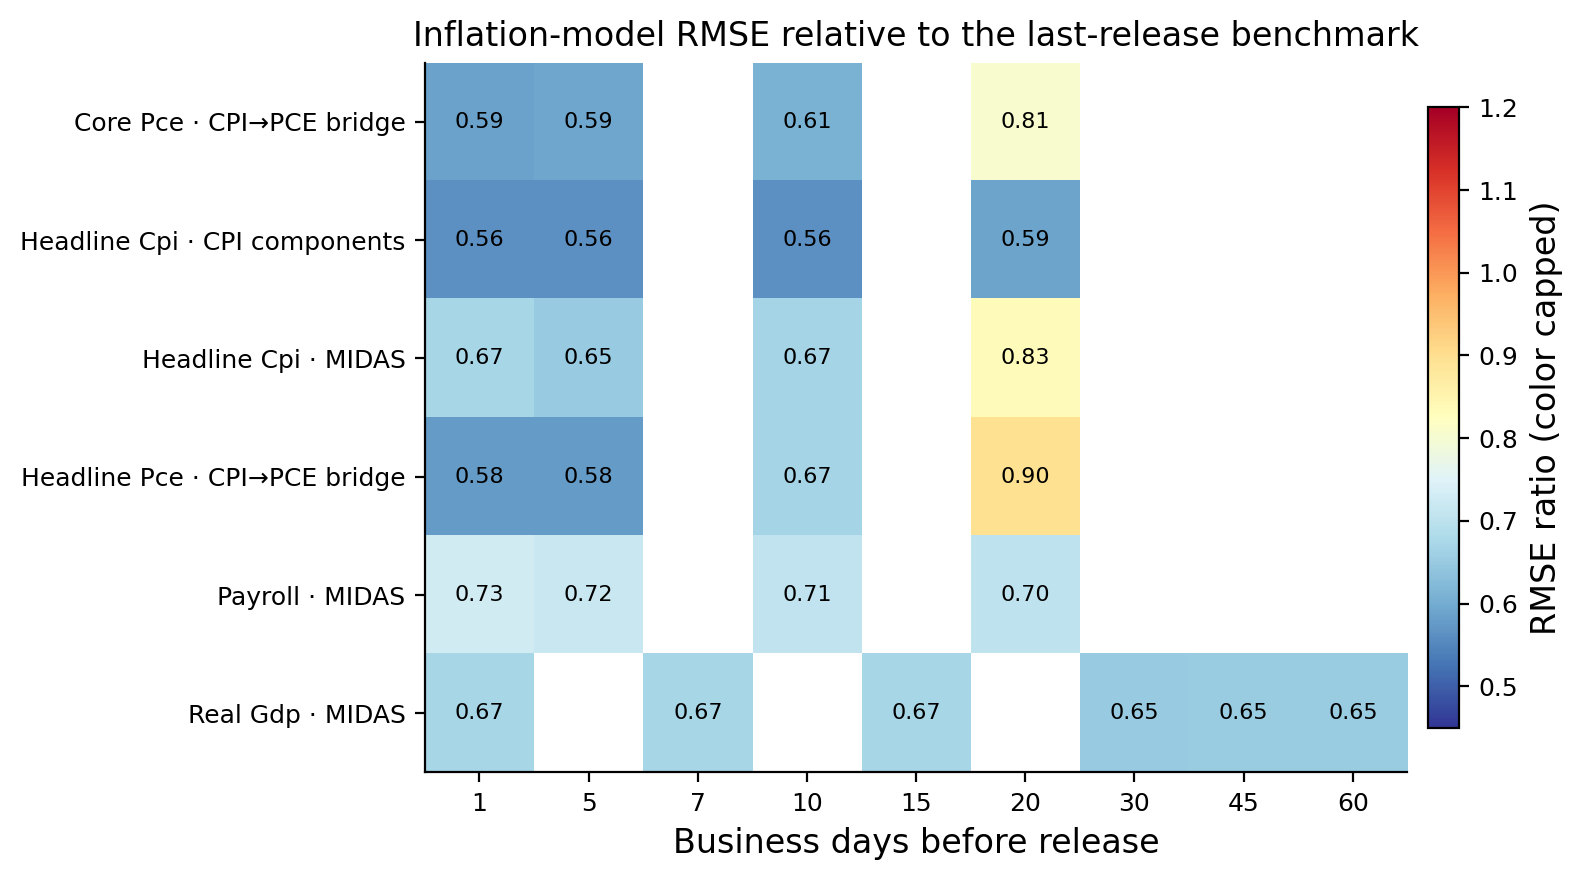

In [26]:
midas_feature_map = {"headline_cpi": ["DCOILBRENTEU", "GASREGW"],
                     "payroll": ["ICSA"], "real_gdp": ["activity"]}
for prefix, weights in midas_shapes.items():
    columns = [f"{prefix}_{lag}" for lag in range(len(weights))]
    midas_design[f"{prefix}_midas"] = midas_design[columns].to_numpy() @ weights

midas_forecast_rows = []
for row in midas_design[midas_design["release_date"].ge(SCORE_START)].itertuples(index=False):
    predictors = [f"{name}_midas" for name in midas_feature_map[row.target]]
    history = midas_design[midas_design["target"].eq(row.target)
                           & midas_design["horizon"].eq(row.horizon)
                           & midas_design["release_date"].lt(row.evaluation_date)].copy()
    history["last_release"] = history["actual"].shift(1)
    current = pd.DataFrame([{name: getattr(row, name) for name in predictors}
                            | {"last_release": history["actual"].iloc[-1]}])
    features = [*predictors, "last_release"]
    training = history[["actual", *features]].dropna()
    if len(training) >= (12 if row.target == "real_gdp" else 36):
        scaler = StandardScaler().fit(training[features])
        target_median = training["actual"].median()
        target_scale = max(1.4826 * (training["actual"] - target_median).abs().median(), 1e-6)
        sample_weight = 1 / (1 + np.square((training["actual"] - target_median) / (4 * target_scale)))
        model = Ridge(alpha=3.0).fit(scaler.transform(training[features]), training["actual"],
                                     sample_weight=sample_weight)
        prediction = float(model.predict(scaler.transform(current[features]))[0])
        residual = training["actual"] - model.predict(scaler.transform(training[features]))
        sigma = residual.tail(60).std(ddof=1)
    else:
        prediction = history["actual"].tail(12).mean()
        sigma = history["actual"].tail(24).std(ddof=1)
    midas_forecast_rows.append({"target": row.target, "observation_date": row.observation_date,
                                "release_date": row.release_date,
                                "evaluation_date": row.evaluation_date,
                                "horizon": row.horizon, "actual": row.actual,
                                "midas": prediction, "midas_sigma": sigma})
midas_forecasts = pd.DataFrame(midas_forecast_rows)

component_rows = []
weight_prior = np.array([0.80, 0.14, 0.06])
for row in evaluation_grid[evaluation_grid["target"].eq("headline_cpi")
                           & evaluation_grid["release_date"].ge(SCORE_START)].itertuples():
    history = component_history[component_history["release_date"].lt(row.evaluation_date)]
    core = ar_forecast(history["core"], window=72, alpha=3.0)
    food = history["food"].tail(12).mean()
    gas_signal = monthly_market_change(high_frequency_wide["GASREGW"], row.evaluation_date,
                                       row.observation_date)
    oil_signal = monthly_market_change(high_frequency_wide["DCOILBRENTEU"], row.evaluation_date,
                                       row.observation_date)
    gas_training = history.assign(last_gas=history["gasoline"].shift(1)).dropna(
        subset=["gasoline", "last_gas"])
    market_history = cpi_market[cpi_market["horizon"].eq(row.horizon)].set_index("observation_date")
    gas_training = gas_training.join(market_history, on="observation_date").dropna(
        subset=["gas_signal", "oil_signal"])
    if len(gas_training) >= 36 and np.isfinite(gas_signal) and np.isfinite(oil_signal):
        gas_model = Ridge(alpha=5.0).fit(
            gas_training[["last_gas", "gas_signal", "oil_signal"]], gas_training["gasoline"])
        gasoline = float(gas_model.predict(pd.DataFrame({
            "last_gas": [history["gasoline"].iloc[-1]], "gas_signal": [gas_signal],
            "oil_signal": [oil_signal]}))[0])
    else:
        gasoline = ar_forecast(history["gasoline"], window=48, alpha=4.0)
    weight_sample = history.dropna(subset=["headline", "core", "food", "gasoline"]).tail(120)
    x = weight_sample[["core", "food", "gasoline"]].to_numpy()
    y = weight_sample["headline"].to_numpy()
    weights = np.linalg.solve(x.T @ x + 250 * np.eye(3), x.T @ y + 250 * weight_prior)
    weights = np.maximum(weights, 0)
    weights /= weights.sum()
    prediction = float(np.dot(weights, [core, food, gasoline]))
    prior_errors = pd.DataFrame(component_rows)
    prior_errors = prior_errors[prior_errors["horizon"].eq(row.horizon)
                                & prior_errors["release_date"].lt(row.evaluation_date)] \
        if len(prior_errors) else prior_errors
    sigma = (prior_errors["component_cpi"] - prior_errors["actual"]).tail(60).std(ddof=1) \
        if len(prior_errors) >= 12 else history["headline"].tail(36).std(ddof=1)
    component_rows.append({"target": row.target, "observation_date": row.observation_date,
                           "release_date": row.release_date, "evaluation_date": row.evaluation_date,
                           "horizon": row.horizon, "actual": row.actual,
                           "component_cpi": prediction, "component_cpi_sigma": sigma,
                           "core_forecast": core, "food_forecast": food,
                           "gasoline_forecast": gasoline, "core_weight": weights[0],
                           "food_weight": weights[1], "gasoline_weight": weights[2]})
component_cpi_forecasts = pd.DataFrame(component_rows)

pce_bridge_rows = []
for row in pce_design[pce_design["release_date"].ge(SCORE_START)].itertuples(index=False):
    history = pce_design[pce_design["target"].eq(row.target)
                         & pce_design["horizon"].eq(row.horizon)
                         & pce_design["release_date"].lt(row.evaluation_date)].copy()
    main_series = "CPILFESL" if row.target == "core_pce" else "CPIAUCSL"
    current_available = bool(getattr(row, f"{main_series}_available"))
    history = history[history[f"{main_series}_available"].eq(float(current_available))]
    features = ["last_release", *[f"{name}_latest" for name in pce_series[row.target]]]
    if current_available:
        features += [f"{name}_current" for name in pce_series[row.target]]
    training = history[["actual", *features]].dropna()
    current = pd.DataFrame([{name: getattr(row, name) for name in features}])
    if len(training) >= 30 and current.notna().all(axis=None):
        scaler = StandardScaler().fit(training[features])
        model = Ridge(alpha=4.0).fit(scaler.transform(training[features]), training["actual"])
        prediction = float(model.predict(scaler.transform(current))[0])
        residual = training["actual"] - model.predict(scaler.transform(training[features]))
        sigma = residual.tail(60).std(ddof=1)
    else:
        prediction = row.last_release
        sigma = training["actual"].tail(36).std(ddof=1)
    pce_bridge_rows.append({"target": row.target, "observation_date": row.observation_date,
                            "release_date": row.release_date, "evaluation_date": row.evaluation_date,
                            "horizon": row.horizon, "actual": row.actual,
                            "pce_bridge": prediction, "pce_bridge_sigma": sigma,
                            "current_cpi_available": current_available})
pce_bridge_forecasts = pd.DataFrame(pce_bridge_rows)

inflation_scores = []
for label, frame, prediction in [
        ("MIDAS", midas_forecasts, "midas"),
        ("CPI components", component_cpi_forecasts, "component_cpi"),
        ("CPI→PCE bridge", pce_bridge_forecasts, "pce_bridge")]:
    for (target, horizon), sample in frame.groupby(["target", "horizon"]):
        scores = forecast_metrics(sample, y_col="actual", prediction_cols=[prediction]).reset_index()
        scores["method"] = label
        scores["target"] = target
        scores["horizon"] = horizon
        inflation_scores.append(scores)
inflation_scores = pd.concat(inflation_scores, ignore_index=True)
latest_component_weights = component_cpi_forecasts.sort_values("evaluation_date").tail(1).set_index(
    "observation_date")[["core_weight", "food_weight", "gasoline_weight"]]
display(inflation_scores.set_index(["target", "horizon", "method"]), latest_component_weights)

fig, ax = plt.subplots(figsize=(7, 3.5))
for label, (_, prefix, _) in midas_predictors.items():
    ax.plot(np.arange(len(midas_shapes[prefix])), midas_shapes[prefix], marker="o", label=label)
ax.set_title("Pre-sample Beta-MIDAS lag weights")
ax.set_xlabel("Lag, most recent first")
ax.set_ylabel("Weight")
ax.legend()
plt.tight_layout()
plt.show()

inflation_relative = inflation_scores.merge(
    baseline_scores[baseline_scores["model"].eq("last_release")][
        ["target", "horizon", "RMSE"]].rename(columns={"RMSE": "baseline_RMSE"}),
    on=["target", "horizon"], how="left")
inflation_relative["RMSE ratio"] = inflation_relative["RMSE"] / inflation_relative["baseline_RMSE"]
inflation_heat = inflation_relative.pivot_table(
    index=["target", "method"], columns="horizon", values="RMSE ratio").sort_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
image = ax.imshow(np.ma.masked_invalid(inflation_heat.to_numpy()), aspect="auto",
                  cmap="RdYlBu_r", vmin=0.45, vmax=1.20)
ax.set_xticks(np.arange(len(inflation_heat.columns)))
ax.set_xticklabels(inflation_heat.columns)
ax.set_yticks(np.arange(len(inflation_heat.index)))
ax.set_yticklabels([f"{target.replace('_', ' ').title()} · {method}"
                    for target, method in inflation_heat.index])
for y, key in enumerate(inflation_heat.index):
    for x, horizon in enumerate(inflation_heat.columns):
        value = inflation_heat.loc[key, horizon]
        if pd.notna(value):
            ax.text(x, y, f"{value:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Inflation-model RMSE relative to the last-release benchmark")
ax.set_xlabel("Business days before release")
ax.grid(False)
fig.colorbar(image, ax=ax, fraction=0.03, pad=0.02, label="RMSE ratio (color capped)")
plt.tight_layout()
plt.show()

In [27]:
SYSTEM_COLUMNS = ["activity", "headline_cpi", "core_cpi", "headline_pce",
                  "core_pce", "payroll", "unemployment", "policy"]

@lru_cache(maxsize=256)
def monthly_system_asof(as_of):
    date = pd.Timestamp(as_of)
    factors = dfm_state(str(date.date()))[["activity"]]
    known = target_truth[target_truth["target"].isin(SYSTEM_COLUMNS)
                         & target_truth["release_date"].le(date)
                         & target_truth["observation_frequency"].eq("monthly")]
    releases = known.pivot_table(index="observation_date", columns="target",
                                 values="first", aggfunc="last")
    policy = high_frequency[high_frequency["series_id"].eq("DFF")
                            & high_frequency["date"].le(date)].set_index("date")["value"]
    policy = policy.groupby(policy.index.to_period("M")).mean()
    policy.index = policy.index.to_timestamp()
    monthly = factors.join(releases, how="outer").join(policy.rename("policy"), how="outer")
    monthly.index = monthly.index.to_period("M").to_timestamp()
    monthly = monthly.groupby(monthly.index).last().sort_index().loc["2000-01-01":]
    return monthly.reindex(columns=SYSTEM_COLUMNS)

latest_system = monthly_system_asof(str(target_truth["release_date"].max().date()))
system_availability = macro_availability_table(latest_system)
display(system_availability)

,first_date,last_date,observations,available_share
column,,,,
activity,2000-01-01,2026-06-01,318,0.9938
headline_cpi,2000-01-01,2026-07-01,317,0.9906
core_cpi,2000-01-01,2026-07-01,317,0.9906
headline_pce,2000-01-01,2026-07-01,319,0.9969
core_pce,2000-01-01,2026-07-01,319,0.9969
payroll,2000-01-01,2026-07-01,317,0.9906
unemployment,2000-01-01,2026-07-01,318,0.9938
policy,2000-01-01,2026-08-01,320,1.0000


In [28]:
BVAR_LAGS = 2
BVAR_TIGHTNESS = 0.20
BVAR_DRAWS = 300
BVAR_MAX_STEPS = 12

def minnesota_var(monthly, lags=BVAR_LAGS, tightness=BVAR_TIGHTNESS):
    sample = monthly.dropna().copy()
    center = sample.mean()
    scale = sample.std(ddof=0).replace(0, 1)
    z = (sample - center) / scale
    y = z.iloc[lags:].to_numpy()
    x = np.column_stack([np.ones(len(y)), *[
        z.shift(lag).iloc[lags:].to_numpy() for lag in range(1, lags + 1)]])
    prior_mean = np.zeros((x.shape[1], y.shape[1]))
    persistent = [sample.columns.get_loc(name) for name in ["unemployment", "policy"]]
    for index in persistent:
        prior_mean[1 + index, index] = 0.5
    precision = np.zeros(x.shape[1])
    precision[0] = 1e-6
    for lag in range(1, lags + 1):
        start = 1 + (lag - 1) * y.shape[1]
        precision[start:start + y.shape[1]] = np.square(lag / tightness)
    prior_precision = np.diag(precision)
    posterior_v = np.linalg.inv(x.T @ x + prior_precision)
    coefficients = posterior_v @ (x.T @ y + prior_precision @ prior_mean)
    residual = y - x @ coefficients
    covariance = residual.T @ residual / (len(residual) - x.shape[1])
    covariance = 0.90 * covariance + 0.10 * np.diag(np.diag(covariance))
    return {"columns": list(sample.columns), "center": center, "scale": scale,
            "z": z, "coefficients": coefficients, "posterior_v": posterior_v,
            "covariance": covariance, "lags": lags}

def posterior_paths(fitted, steps=BVAR_MAX_STEPS, draws=BVAR_DRAWS):
    coefficients = fitted["coefficients"]
    left = np.linalg.cholesky(fitted["posterior_v"] + 1e-10 * np.eye(len(coefficients)))
    right = np.linalg.cholesky(fitted["covariance"] + 1e-10 * np.eye(len(fitted["columns"])))
    normal_draws = rng.normal(size=(draws, coefficients.shape[0], coefficients.shape[1]))
    coefficient_draws = coefficients + np.einsum("ij,djk,kl->dil", left, normal_draws, right.T)
    history = np.repeat(fitted["z"].iloc[-fitted["lags"]:].to_numpy()[None, :, :], draws, axis=0)
    simulations = []
    for _ in range(steps):
        x = np.concatenate([np.ones((draws, 1)), *[
            history[:, -lag, :] for lag in range(1, fitted["lags"] + 1)]], axis=1)
        conditional_mean = np.einsum("dk,dkm->dm", x, coefficient_draws)
        shock = rng.multivariate_normal(np.zeros(len(fitted["columns"])),
                                        fitted["covariance"], size=draws)
        next_value = conditional_mean + shock
        simulations.append(next_value)
        history = np.concatenate([history[:, 1:, :], next_value[:, None, :]], axis=1)
    standardized = np.stack(simulations, axis=1)
    return standardized * fitted["scale"].to_numpy()[None, None, :] \
        + fitted["center"].to_numpy()[None, None, :]

def quarter_average(values, quarter):
    return values[values.index.to_period("Q") == quarter].mean()

bvar_configuration = pd.DataFrame({
    "value": [BVAR_LAGS, BVAR_TIGHTNESS, BVAR_DRAWS, BVAR_MAX_STEPS,
              "0.5 on own first lag", "10% diagonal covariance shrinkage",
              "Separate grouped-factor GDP bridge"]},
    index=["VAR lags", "Minnesota tightness", "Posterior paths", "Maximum monthly horizon",
           "Persistent-variable prior", "Innovation covariance",
           "GDP observation aggregation"])
display(bvar_configuration)

,value
VAR lags,2
Minnesota tightness,0.2000
Posterior paths,300
Maximum monthly horizon,12
Persistent-variable prior,0.5 on own first lag
Innovation covariance,10% diagonal covariance shrinkage
GDP observation aggregation,Separate grouped-factor GDP bridge


In [29]:
bvar_cache = {}

def fitted_bvar_asof(as_of):
    monthly = monthly_system_asof(str(pd.Timestamp(as_of).date())).dropna()
    factors = dfm_state(str(pd.Timestamp(as_of).date()))
    key = (monthly.index.max(), factors.attrs["snapshot"])
    if key not in bvar_cache:
        fitted = minnesota_var(monthly)
        paths = posterior_paths(fitted)
        bvar_cache[key] = (fitted, paths, monthly, factors)
    return bvar_cache[key]

def summarize_draws(draws):
    q10, q25, q75, q90 = np.quantile(draws, [0.10, 0.25, 0.75, 0.90])
    return {"bvar": draws.mean(), "bvar_sigma": draws.std(ddof=1),
            "bvar_q10": q10, "bvar_q25": q25, "bvar_q75": q75, "bvar_q90": q90}

bvar_rows = []
for row in evaluation_grid[evaluation_grid["release_date"].ge(SCORE_START)].itertuples():
    fitted, paths, monthly, factors = fitted_bvar_asof(row.evaluation_date)
    if row.target == "real_gdp":
        quarter = row.observation_date.to_period("Q")
        target_months = pd.period_range(quarter.start_time, quarter.end_time, freq="M").to_timestamp()
        activity_draws = []
        activity_index = fitted["columns"].index("activity")
        for month in target_months:
            if month in factors.index and month <= factors.index.max():
                activity_draws.append(np.full(BVAR_DRAWS, factors.loc[month, "activity"]))
            else:
                step = max(1, (month.to_period("M") - monthly.index.max().to_period("M")).n)
                activity_draws.append(paths[:, min(step, BVAR_MAX_STEPS) - 1, activity_index])
        current_activity = np.mean(activity_draws, axis=0)
        gdp_history = target_truth[target_truth["target"].eq("real_gdp")
                                   & target_truth["release_date"].lt(row.evaluation_date)].copy()
        gdp_history["activity"] = gdp_history["observation_date"].map(
            lambda date: quarter_average(factors["activity"], date.to_period("Q")))
        gdp_history["lag"] = gdp_history["first"].shift(1)
        training = gdp_history.dropna(subset=["first", "activity", "lag"])
        scaler = StandardScaler().fit(training[["activity", "lag"]])
        target_median = training["first"].median()
        target_scale = max(1.4826 * (training["first"] - target_median).abs().median(), 1e-6)
        sample_weight = 1 / (1 + np.square((training["first"] - target_median) / (4 * target_scale)))
        model = Ridge(alpha=2.0).fit(scaler.transform(training[["activity", "lag"]]),
                                     training["first"], sample_weight=sample_weight)
        fitted_values = model.predict(scaler.transform(training[["activity", "lag"]]))
        residual_sigma = max((training["first"] - fitted_values).std(ddof=1), 0.50)
        current = pd.DataFrame({"activity": current_activity,
                                "lag": gdp_history["first"].iloc[-1]})
        draws = model.predict(scaler.transform(current)) + rng.normal(
            scale=residual_sigma, size=BVAR_DRAWS)
    else:
        column = fitted["columns"].index(row.target)
        step = max(1, (row.observation_date.to_period("M")
                       - monthly.index.max().to_period("M")).n)
        draws = paths[:, min(step, BVAR_MAX_STEPS) - 1, column]
    bvar_rows.append({"target": row.target, "observation_date": row.observation_date,
                      "release_date": row.release_date, "evaluation_date": row.evaluation_date,
                      "horizon": row.horizon, "actual": row.actual, **summarize_draws(draws)})
bvar_forecasts = pd.DataFrame(bvar_rows)

policy_monthly = high_frequency[high_frequency["series_id"].eq("DFF")].set_index("date")["value"]
policy_monthly = policy_monthly.groupby(policy_monthly.index.to_period("M")).mean()
policy_monthly.index = policy_monthly.index.to_timestamp()
policy_rows = []
for date in pd.date_range(SCORE_START, policy_monthly.index.max() - pd.offsets.MonthEnd(12), freq="ME"):
    fitted, paths, monthly, _ = fitted_bvar_asof(date)
    policy_index = fitted["columns"].index("policy")
    for horizon in (3, 6, 12):
        target_date = date.to_period("M").to_timestamp() + pd.offsets.MonthBegin(horizon)
        actual = policy_monthly.get(target_date, np.nan)
        bvar_draws = paths[:, horizon - 1, policy_index]
        history = monthly.copy()
        history["future_policy"] = history["policy"].shift(-horizon)
        training = history.dropna()
        features = ["activity", "core_cpi", "unemployment", "policy"]
        scaler = StandardScaler().fit(training[features])
        taylor = Ridge(alpha=4.0).fit(scaler.transform(training[features]), training["future_policy"])
        taylor_mean = float(taylor.predict(scaler.transform(monthly[features].iloc[[-1]]))[0])
        taylor_sigma = (training["future_policy"]
                        - taylor.predict(scaler.transform(training[features]))).std(ddof=1)
        random_walk_sigma = monthly["policy"].diff().std(ddof=1) * np.sqrt(horizon)
        policy_rows.append({"evaluation_date": date, "target_date": target_date,
                            "horizon": horizon, "actual": actual,
                            "bvar": bvar_draws.mean(), "bvar_sigma": bvar_draws.std(ddof=1),
                            "taylor": taylor_mean, "taylor_sigma": taylor_sigma,
                            "random_walk": monthly["policy"].iloc[-1],
                            "random_walk_sigma": random_walk_sigma})
policy_forecasts = pd.DataFrame(policy_rows)

latest_bvar = bvar_forecasts.sort_values("evaluation_date").groupby("target").tail(1).set_index("target")[[
    "observation_date", "evaluation_date", "horizon", "actual", "bvar",
    "bvar_q10", "bvar_q90", "bvar_sigma"]]
latest_bvar.loc["Information-state cache", "bvar"] = len(bvar_cache)
display(latest_bvar)

,observation_date,evaluation_date,horizon,actual,bvar,bvar_q10,bvar_q90,bvar_sigma
target,,,,,,,,
real_gdp,2026-04-01,2026-07-29,1.0000,1.5005,2.3515,-4.2056,9.1704,5.3630
payroll,2026-07-01,2026-08-06,1.0000,-23.0000,-517.0077,"-2,078.5785","1,106.9742","1,303.6043"
unemployment,2026-07-01,2026-08-06,1.0000,4.1000,4.6188,3.7408,5.4836,0.6784
core_cpi,2026-07-01,2026-08-11,1.0000,2.6161,0.9495,-0.7434,2.8318,1.4089
headline_cpi,2026-07-01,2026-08-11,1.0000,0.8876,-1.6793,-6.0529,2.8577,3.5592
core_pce,2026-07-01,2026-08-25,1.0000,2.9426,0.3239,-1.7766,2.3441,1.6129
headline_pce,2026-07-01,2026-08-25,1.0000,1.8699,-1.2009,-4.1938,1.9236,2.5361
Information-state cache,NaT,NaT,NaN,NaN,193.0000,NaN,NaN,NaN


observations     CRPS  log_score  coverage_80  sharpness_80
target       horizon                                                             
core_cpi     1                 144   0.9842    -2.2263       0.7917        3.2650
             5                 144   0.9843    -2.2270       0.7917        3.2670
             10                144   1.1497    -2.5108       0.7708        3.4524
             20                144   1.1650    -2.5405       0.7569        3.5039
core_pce     1                 146   0.8702    -1.9076       0.8288        3.9655
             5                 146   0.8698    -1.9067       0.8288        3.9598
             10                146   0.8688    -1.9045       0.8288        3.9628
             20                146   0.8806    -1.9247       0.8356        4.0006
headline_cpi 1                 144   1.8432    -2.6387       0.8889        9.6191
             5                 144   1.8452    -2.6377       0.8889        9.6264
             10                144   2.0990    -2.7578       0.8472       10.1943
             20                144   2.1202    -2.7751       0.8472       10.4083
headline_pce 1                 146   1.2943    -2.2832       0.8836        6.7554
             5                 146   1.2944    -2.2832       0.8836        6.7549
             10                146   1.2960    -2.2841       0.8836        6.7541
             20                146   1.3312    -2.3064       0.8699        6.8939
payroll      1                 144 442.6291   -79.7284       0.9097    1,908.1088
             5                 144 420.5605   -80.7313       0.9236    1,920.6607
             10                144 426.6849  -107.3062       0.9306    1,929.7992
             20                144 426.5342  -107.3057       0.9306    1,931.9305
real_gdp     1                  47   2.7146    -6.6162       0.9149        8.8386
             7                  47   2.7461    -7.2074       0.9149        8.8097
             15                 47   2.7406    -6.9009       0.9149        8.7745
             30                 47   2.7334    -6.3744       0.9149        8.6751
             45                 47   2.7319    -7.0367       0.9149        8.8431
             60                 47   2.7320    -6.3953       0.9149        8.9700
unemployment 1                 145   0.2986    -8.5853       0.7517        1.2014
             5                 145   0.4401   -11.7812       0.6414        1.4343
             10                145   0.4778   -11.1625       0.6207        1.5817
             20                145   0.4791   -11.1665       0.6207        1.5920

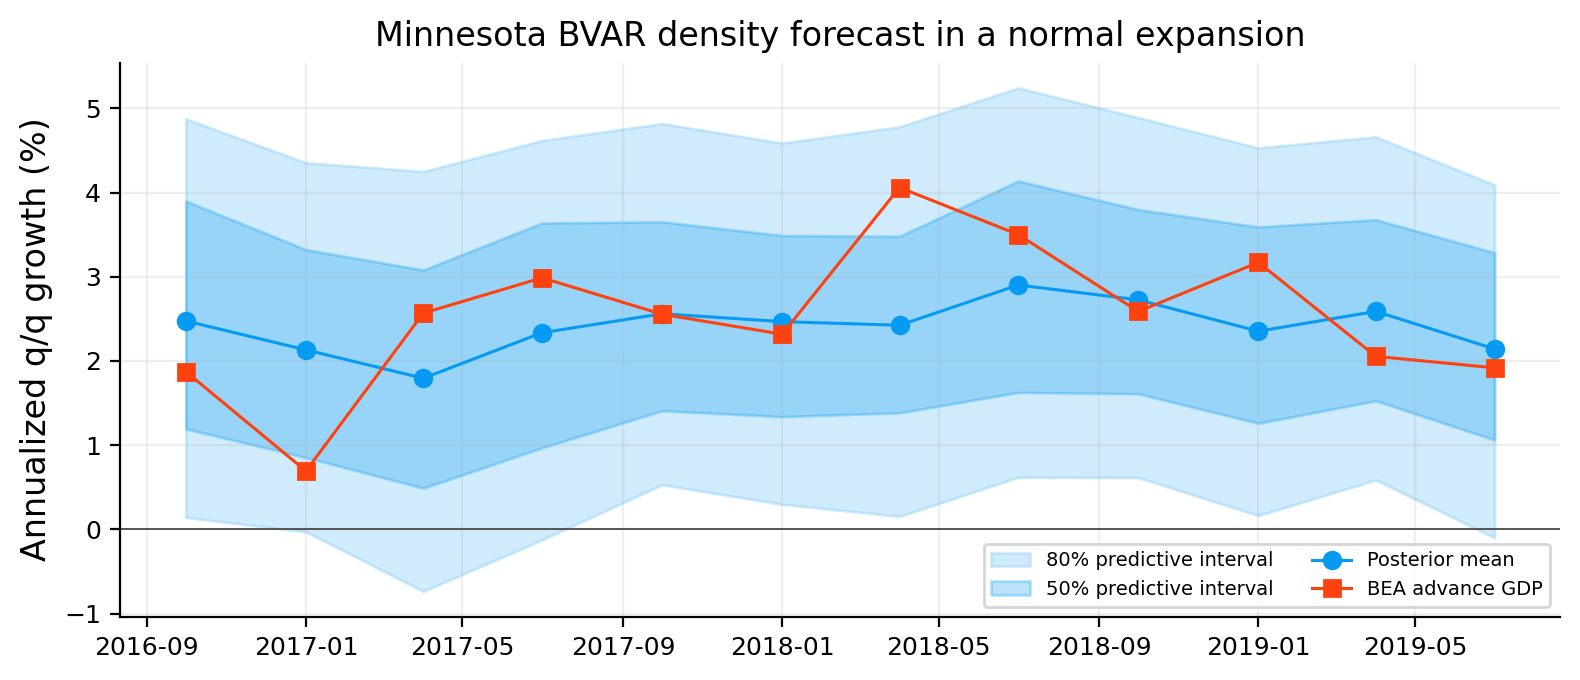

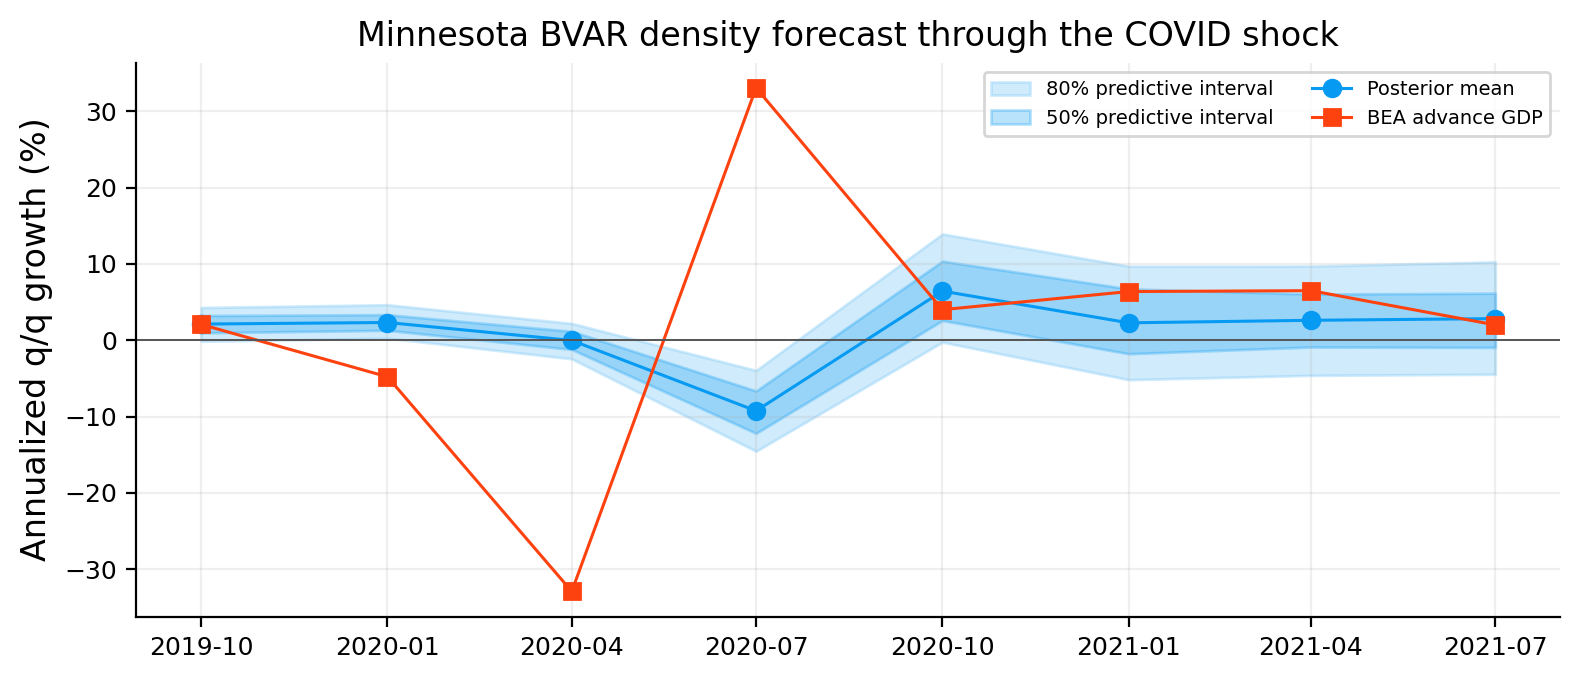

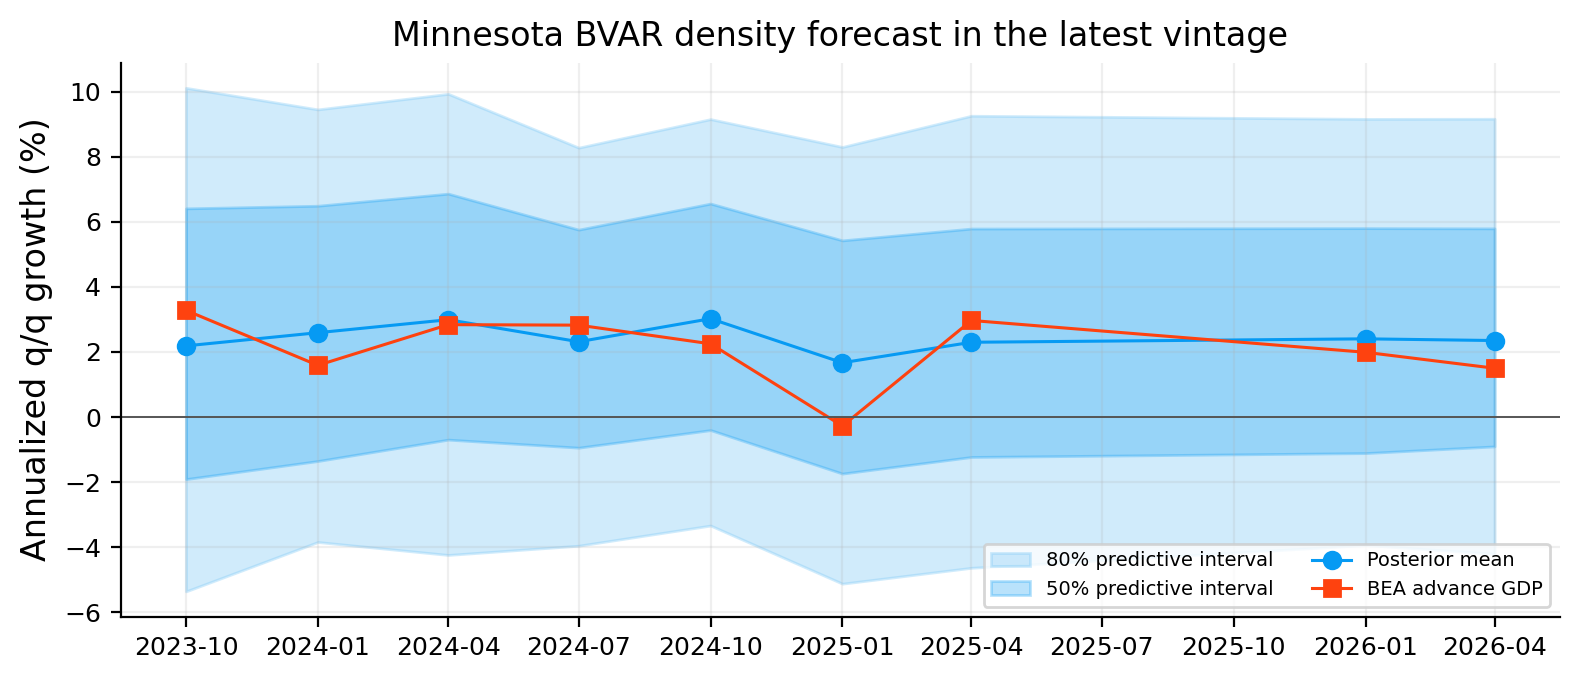

In [30]:
def gaussian_crps(actual, mean, sigma):
    sigma = np.maximum(np.asarray(sigma, dtype=float), 1e-8)
    z = (np.asarray(actual, dtype=float) - np.asarray(mean, dtype=float)) / sigma
    return sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))

density_rows = []
for (target, horizon), sample in bvar_forecasts.groupby(["target", "horizon"]):
    sigma = sample["bvar_sigma"].clip(lower=1e-6)
    density_rows.append({"target": target, "horizon": horizon, "observations": len(sample),
                         "CRPS": gaussian_crps(sample["actual"], sample["bvar"], sigma).mean(),
                         "log_score": -gaussian_nll(sample["actual"], sample["bvar"], np.square(sigma)),
                         "coverage_80": interval_coverage(sample["actual"], sample["bvar_q10"],
                                                          sample["bvar_q90"]),
                         "sharpness_80": interval_width(sample["bvar_q10"], sample["bvar_q90"])})
bvar_density_scores = pd.DataFrame(density_rows).set_index(["target", "horizon"])
display(bvar_density_scores)

def plot_gdp_fan(start, end, title):
    sample = bvar_forecasts[bvar_forecasts["target"].eq("real_gdp")
                            & bvar_forecasts["horizon"].eq(1)
                            & bvar_forecasts["release_date"].between(start, end)].sort_values(
                                "observation_date")
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.fill_between(sample["observation_date"], sample["bvar_q10"], sample["bvar_q90"],
                    color=palette[7], alpha=0.35, label="80% predictive interval")
    ax.fill_between(sample["observation_date"], sample["bvar_q25"], sample["bvar_q75"],
                    color=palette[0], alpha=0.28, label="50% predictive interval")
    ax.plot(sample["observation_date"], sample["bvar"], color=palette[0], marker="o",
            linewidth=1.1, label="Posterior mean")
    ax.plot(sample["observation_date"], sample["actual"], color=palette[1], marker="s",
            linewidth=1.1, label="BEA advance GDP")
    ax.axhline(0, color="#555555", linewidth=0.7)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Annualized q/q growth (%)")
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()

plot_gdp_fan("2017-01-01", "2019-12-31", "Minnesota BVAR density forecast in a normal expansion")
plot_gdp_fan("2020-01-01", "2021-12-31", "Minnesota BVAR density forecast through the COVID shock")
plot_gdp_fan("2024-01-01", "2026-12-31", "Minnesota BVAR density forecast in the latest vintage")

In [31]:
individual_forecasts = []
forecast_sources = [
    ("Last release", baseline_forecasts, "last_release", None),
    ("AR(1)", baseline_forecasts, "ar1", None),
    ("Bridge", bridge_forecasts, "bridge", "bridge_sigma"),
    ("Grouped DFM", dfm_forecasts, "dfm", "dfm_sigma"),
    ("MIDAS", midas_forecasts, "midas", "midas_sigma"),
    ("CPI components", component_cpi_forecasts, "component_cpi", "component_cpi_sigma"),
    ("CPI→PCE bridge", pce_bridge_forecasts, "pce_bridge", "pce_bridge_sigma"),
    ("BVAR", bvar_forecasts, "bvar", "bvar_sigma")]
for name, source, mean_name, sigma_name in forecast_sources:
    columns = ["target", "observation_date", "release_date", "evaluation_date",
               "horizon", "actual", mean_name] + ([sigma_name] if sigma_name else [])
    frame = source[columns].rename(columns={mean_name: "mean"}).copy()
    if sigma_name:
        frame = frame.rename(columns={sigma_name: "sigma"})
    else:
        error = frame["mean"] - frame["actual"]
        frame["sigma"] = error.groupby([frame["target"], frame["horizon"]]).transform(
            lambda values: values.expanding(min_periods=12).std(ddof=1).shift(1))
    frame["model"] = name
    individual_forecasts.append(frame)
individual_forecasts = pd.concat(individual_forecasts, ignore_index=True).dropna(subset=["mean"])

dma_rows = []
weight_rows = []
forecast_keys = ["target", "observation_date", "release_date", "evaluation_date", "horizon", "actual"]
for key, candidates in individual_forecasts.groupby(forecast_keys, sort=True):
    target, observation_date, release_date, evaluation_date, horizon, actual = key
    if release_date < SCORE_START:
        continue
    truth_history = target_truth[target_truth["target"].eq(target)
                                 & target_truth["release_date"].lt(evaluation_date)]["first"].tail(60)
    history_median = truth_history.median()
    history_scale = 1.4826 * (truth_history - history_median).abs().median()
    history_scale = max(history_scale, truth_history.std(ddof=1) / 3, 1e-6)
    losses = {}
    for model_name in candidates["model"]:
        history = individual_forecasts[individual_forecasts["target"].eq(target)
                                       & individual_forecasts["horizon"].eq(horizon)
                                       & individual_forecasts["model"].eq(model_name)
                                       & individual_forecasts["release_date"].lt(evaluation_date)].tail(36)
        losses[model_name] = np.square(history["mean"] - history["actual"]).mean() \
            / np.square(history_scale) if len(history) >= 8 else np.nan
    losses = pd.Series(losses).dropna()
    if losses.empty:
        fallback = candidates[candidates["model"].isin(["Last release", "AR(1)"])]["model"]
        weights = pd.Series(1 / len(fallback), index=fallback)
    else:
        weights = np.exp(-0.5 * (losses - losses.min())).clip(lower=0.02)
        weights /= weights.sum()
    candidates = candidates.set_index("model").loc[weights.index]
    combined_mean = candidates["mean"].clip(history_median - 8 * history_scale,
                                              history_median + 8 * history_scale)
    combined_sigma = candidates["sigma"].fillna(history_scale).clip(lower=0.10 * history_scale)
    mean = float(np.dot(weights, combined_mean))
    variance = float(np.dot(weights, np.square(combined_sigma)
                            + np.square(combined_mean)) - mean ** 2)
    dma_rows.append({"target": target, "observation_date": observation_date,
                     "release_date": release_date, "evaluation_date": evaluation_date,
                     "horizon": horizon, "actual": actual, "dma": mean,
                     "dma_sigma": np.sqrt(max(variance, 1e-8)),
                     "dma_q10": mean + norm.ppf(0.10) * np.sqrt(max(variance, 1e-8)),
                     "dma_q90": mean + norm.ppf(0.90) * np.sqrt(max(variance, 1e-8))})
    for model_name, weight in weights.items():
        weight_rows.append({"target": target, "observation_date": observation_date,
                            "evaluation_date": evaluation_date, "horizon": horizon,
                            "model": model_name, "weight": weight})
dma_forecasts = pd.DataFrame(dma_rows)
dma_weights = pd.DataFrame(weight_rows)

policy_dma_rows = []
policy_weight_rows = []
for row in policy_forecasts.itertuples():
    losses = {}
    for model_name in ["bvar", "taylor", "random_walk"]:
        history = policy_forecasts[policy_forecasts["horizon"].eq(row.horizon)
                                   & policy_forecasts["target_date"].lt(row.evaluation_date)].tail(36)
        scale = history["actual"].std(ddof=1)
        losses[model_name] = np.square(history[model_name] - history["actual"]).mean() \
            / max(np.square(scale), 1e-8) if len(history) >= 8 else np.nan
    losses = pd.Series(losses).dropna()
    if losses.empty:
        weights = pd.Series({"random_walk": 1.0})
    else:
        weights = np.exp(-0.5 * (losses - losses.min())).clip(lower=0.03)
        weights /= weights.sum()
    means = pd.Series({model_name: getattr(row, model_name) for model_name in weights.index})
    sigmas = pd.Series({model_name: getattr(row, f"{model_name}_sigma") for model_name in weights.index})
    mean = float(np.dot(weights, means))
    variance = float(np.dot(weights, np.square(sigmas) + np.square(means)) - mean ** 2)
    policy_dma_rows.append({"evaluation_date": row.evaluation_date,
                            "target_date": row.target_date, "horizon": row.horizon,
                            "actual": row.actual, "dma": mean,
                            "dma_sigma": np.sqrt(max(variance, 1e-8))})
    for model_name, weight in weights.items():
        policy_weight_rows.append({"evaluation_date": row.evaluation_date,
                                   "horizon": row.horizon, "model": model_name, "weight": weight})
policy_dma = pd.DataFrame(policy_dma_rows)
policy_dma_weights = pd.DataFrame(policy_weight_rows)

latest_weights = dma_weights.sort_values("evaluation_date").groupby(
    ["target", "horizon", "model"]).tail(1).pivot_table(
        index=["target", "horizon"], columns="model", values="weight", fill_value=0)
display(latest_weights)

model                 AR(1)   BVAR  Bridge  CPI components  CPI→PCE bridge  Grouped DFM  Last release  MIDAS
target       horizon                                                                                        
core_cpi     1       0.2554 0.2538  0.0000          0.0000          0.0000       0.2599        0.2309 0.0000
             5       0.2553 0.2539  0.0000          0.0000          0.0000       0.2599        0.2309 0.0000
             10      0.2643 0.2384  0.0000          0.0000          0.0000       0.2584        0.2390 0.0000
             20      0.2639 0.2375  0.0000          0.0000          0.0000       0.2586        0.2400 0.0000
core_pce     1       0.2001 0.2047  0.0000          0.0000          0.2143       0.1985        0.1824 0.0000
             5       0.1996 0.2043  0.0000          0.0000          0.2154       0.1987        0.1820 0.0000
             10      0.1989 0.2041  0.0000          0.0000          0.2180       0.1977        0.1813 0.0000
             20      0.1940 0.2150  0.0000          0.0000          0.2241       0.2028        0.1641 0.0000
headline_cpi 1       0.1647 0.1639  0.0000          0.2085          0.0000       0.1121        0.1408 0.2101
             5       0.1652 0.1622  0.0000          0.2093          0.0000       0.1125        0.1413 0.2096
             10      0.1649 0.1497  0.0000          0.2100          0.0000       0.1301        0.1409 0.2044
             20      0.1716 0.1588  0.0000          0.2192          0.0000       0.1187        0.1423 0.1894
headline_pce 1       0.1905 0.1922  0.0000          0.0000          0.2506       0.1948        0.1719 0.0000
             5       0.1916 0.1933  0.0000          0.0000          0.2522       0.1901        0.1729 0.0000
             10      0.1918 0.1925  0.0000          0.0000          0.2540       0.1885        0.1731 0.0000
             20      0.2009 0.2052  0.0000          0.0000          0.2275       0.1902        0.1763 0.0000
payroll      1       0.2484 0.0612  0.0000          0.0000          0.0000       0.1872        0.2428 0.2605
             5       0.2487 0.0720  0.0000          0.0000          0.0000       0.1749        0.2431 0.2612
             10      0.2429 0.0782  0.0000          0.0000          0.0000       0.1776        0.2374 0.2639
             20      0.2359 0.0752  0.0000          0.0000          0.0000       0.1710        0.2622 0.2556
real_gdp     1       0.0182 0.0182  0.9091          0.0000          0.0000       0.0182        0.0182 0.0182
             7       0.0182 0.0182  0.9091          0.0000          0.0000       0.0182        0.0182 0.0182
             15      0.0182 0.0182  0.9091          0.0000          0.0000       0.0182        0.0182 0.0182
             30      0.0182 0.0182  0.9091          0.0000          0.0000       0.0182        0.0182 0.0182
             45      0.0182 0.0182  0.9091          0.0000          0.0000       0.0182        0.0182 0.0182
             60      0.0174 0.0174  0.8722          0.0000          0.0000       0.0580        0.0174 0.0174
unemployment 1       0.2572 0.2466  0.0000          0.0000          0.0000       0.2385        0.2577 0.0000
             5       0.2602 0.2380  0.0000          0.0000          0.0000       0.2411        0.2607 0.0000
             10      0.2613 0.2332  0.0000          0.0000          0.0000       0.2435        0.2619 0.0000
             20      0.2617 0.2336  0.0000          0.0000          0.0000       0.2423        0.2624 0.0000

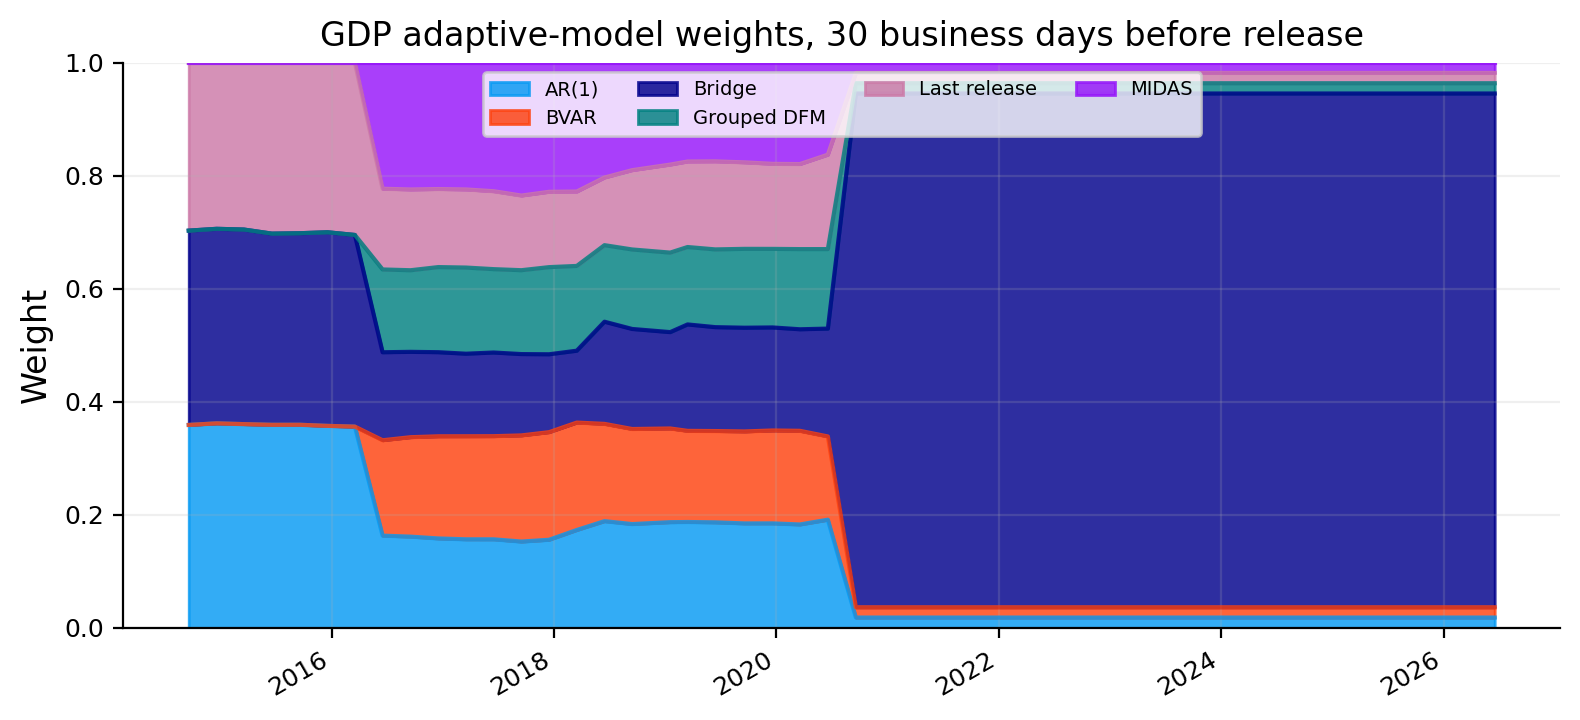

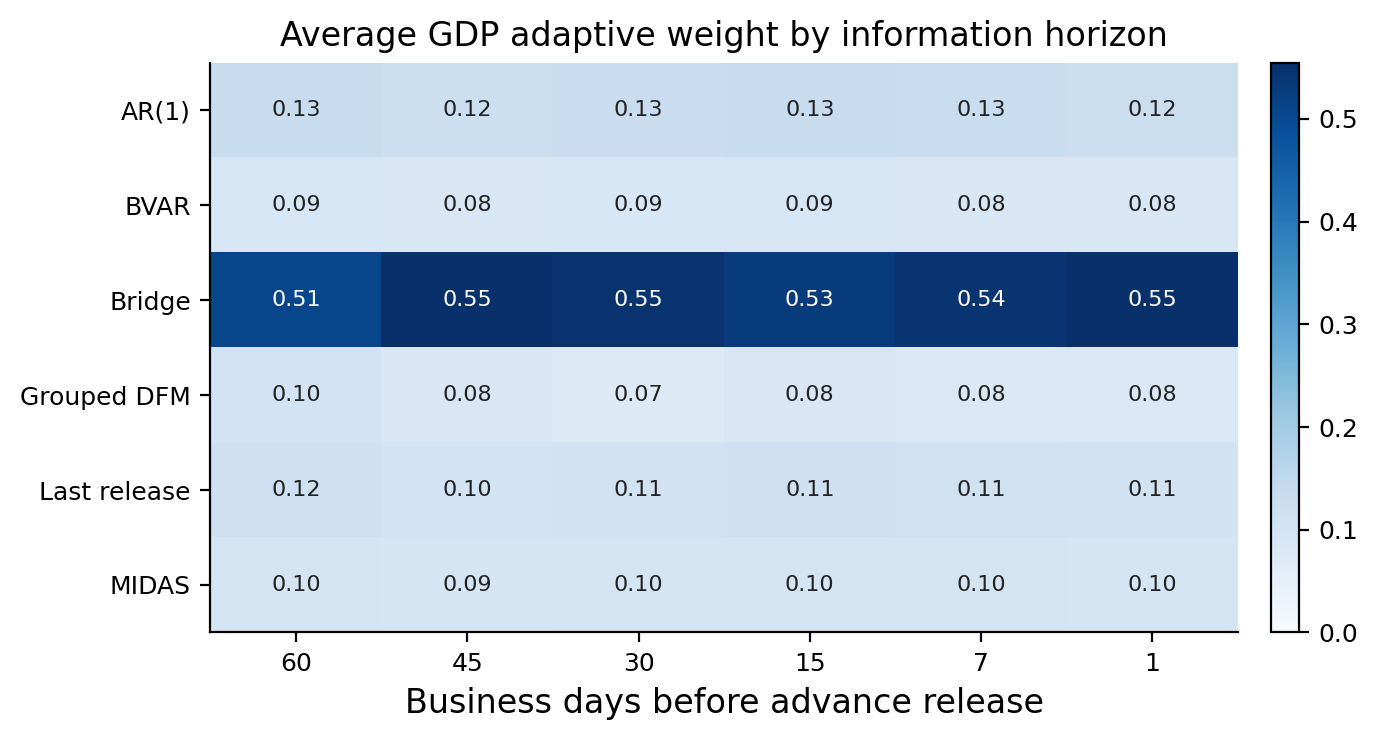

In [32]:
gdp_weight_path = dma_weights[dma_weights["target"].eq("real_gdp")
                              & dma_weights["horizon"].eq(30)
                              & dma_weights["evaluation_date"].ge(SCORE_START)].pivot_table(
    index="evaluation_date", columns="model", values="weight")
ax = gdp_weight_path.plot.area(figsize=(8, 3.7), alpha=0.82)
ax.set_ylim(0, 1)
ax.set_title("GDP adaptive-model weights, 30 business days before release")
ax.set_xlabel("")
ax.set_ylabel("Weight")
ax.legend(ncol=4, loc="upper center")
plt.tight_layout()
plt.show()

gdp_horizon_weights = dma_weights[dma_weights["target"].eq("real_gdp")
                                  & dma_weights["evaluation_date"].ge(SCORE_START)].groupby(
    ["horizon", "model"])["weight"].mean().unstack(fill_value=0).sort_index(ascending=False)
fig, ax = plt.subplots(figsize=(7, 3.8))
image = ax.imshow(gdp_horizon_weights.T, aspect="auto", cmap="Blues", vmin=0,
                  vmax=gdp_horizon_weights.to_numpy().max())
ax.set_xticks(np.arange(len(gdp_horizon_weights)))
ax.set_xticklabels(gdp_horizon_weights.index)
ax.set_yticks(np.arange(len(gdp_horizon_weights.columns)))
ax.set_yticklabels(gdp_horizon_weights.columns)
for y, model in enumerate(gdp_horizon_weights.columns):
    for x, horizon in enumerate(gdp_horizon_weights.index):
        value = gdp_horizon_weights.loc[horizon, model]
        ax.text(x, y, f"{value:.2f}", ha="center", va="center", fontsize=8,
                color="white" if value > 0.45 else "#222222")
ax.set_title("Average GDP adaptive weight by information horizon")
ax.set_xlabel("Business days before advance release")
ax.grid(False)
fig.colorbar(image, ax=ax, fraction=0.035, pad=0.03)
plt.tight_layout()
plt.show()

n    MAE   RMSE  Spearman IC  Directional Accuracy    Bias    selected_model  mean_median_gap
target       model                                                                                                        
headline_cpi spf_mean       49 1.6891 2.2355       0.5336                0.8980 -0.2936    CPI components           0.1188
             spf_median     49 1.7366 2.2874       0.5401                0.8980 -0.2716    CPI components           0.1188
             project_model  48 2.2611 3.0010       0.5883                0.9167 -0.2869    CPI components           0.1188
real_gdp     spf_mean       46 1.6354 2.7683       0.3721                0.9130 -0.0205  Completed bridge           0.1093
             spf_median     46 1.5920 2.7703       0.3756                0.9130 -0.0477  Completed bridge           0.1093
             project_model  44 2.3702 4.6952       0.2072                0.8182  0.0845  Completed bridge           0.1093
unemployment spf_mean       49 0.1646 0.4562       0.9801                1.0000  0.1223       Grouped DFM           0.0311
             spf_median     49 0.1582 0.4817       0.9843                1.0000  0.1141       Grouped DFM           0.0311
             project_model  48 0.4086 1.2713       0.9429                1.0000  0.0008       Grouped DFM           0.0311

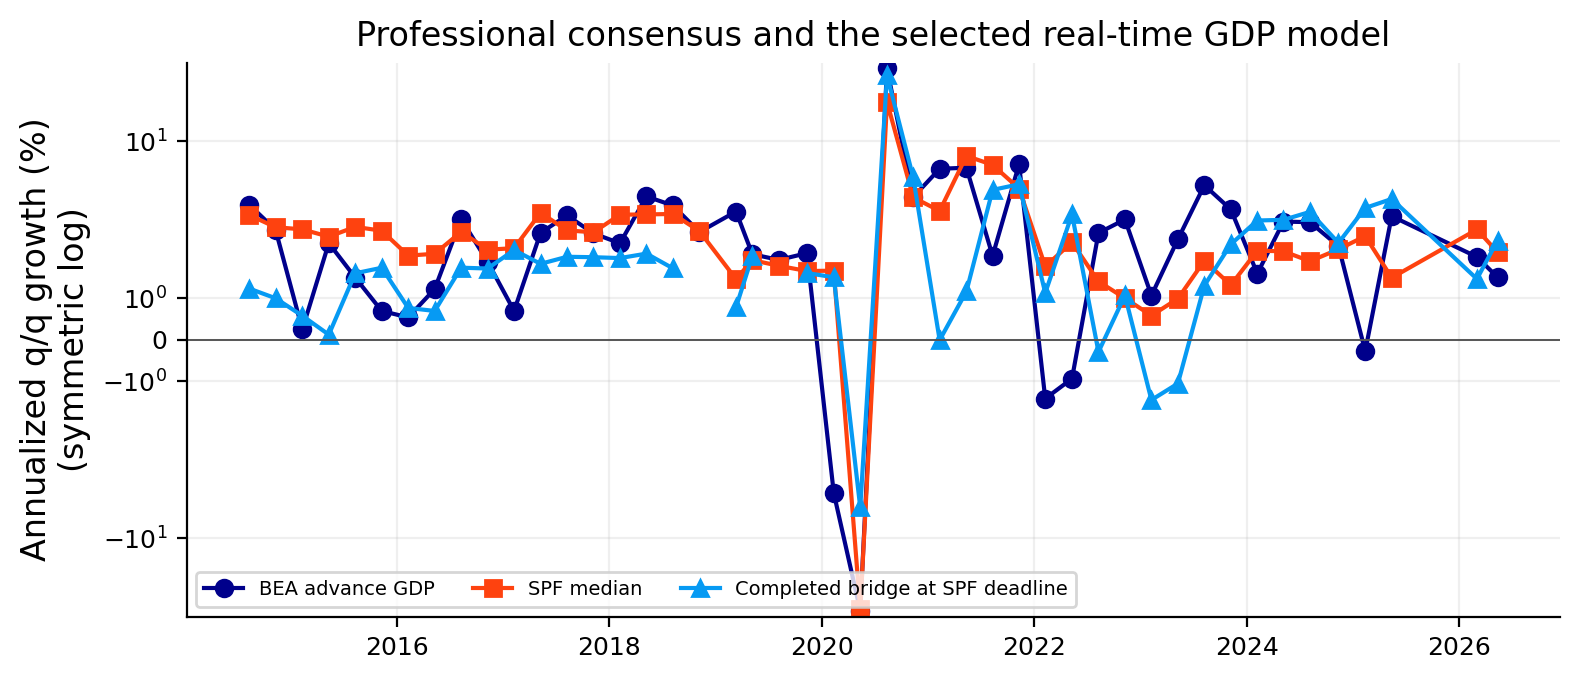

In [33]:
spf = pd.read_parquet(SPF_PATH)
spf["deadline_date"] = pd.to_datetime(spf["deadline_date"])
spf["release_date"] = pd.to_datetime(spf["release_date"])
spf_choice = {"real_gdp": ("RGDP", "growth", "drgdp2"),
              "headline_cpi": ("CPI", "level", "CPI2"),
              "unemployment": ("UNEMP", "level", "UNEMP2")}
project_sources = {"real_gdp": (bridge_forecasts, "bridge", "Completed bridge"),
                   "headline_cpi": (component_cpi_forecasts, "component_cpi", "CPI components"),
                   "unemployment": (dfm_forecasts, "dfm", "Grouped DFM")}
spf_rows = []
for target, (variable, measure, horizon) in spf_choice.items():
    selected = spf[spf["variable"].eq(variable) & spf["measure"].eq(measure)
                   & spf["forecast_horizon"].eq(horizon)].pivot_table(
                       index=["survey_year", "survey_quarter", "deadline_date", "release_date"],
                       columns="statistic", values="forecast_value", aggfunc="last").reset_index()
    model_source, prediction, model_name = project_sources[target]
    for row in selected.itertuples():
        quarter = pd.Period(year=int(row.survey_year), quarter=int(row.survey_quarter), freq="Q")
        truth = target_truth[target_truth["target"].eq(target)
                             & target_truth["observation_date"].dt.to_period("Q").eq(quarter)]
        actual = truth["first"].iloc[0] if target == "real_gdp" and len(truth) \
            else truth["first"].mean()
        model = model_source[model_source["target"].eq(target)
                             & model_source["observation_date"].dt.to_period("Q").eq(quarter)
                             & model_source["evaluation_date"].le(row.deadline_date)]
        model_value = model.sort_values("evaluation_date").groupby(
            "observation_date").tail(1)[prediction].mean()
        spf_rows.append({"target": target, "survey_period": str(quarter),
                         "deadline_date": row.deadline_date, "actual": actual,
                         "spf_mean": row.mean, "spf_median": row.median,
                         "mean_median_gap": abs(row.mean - row.median),
                         "project_model": model_value, "selected_model": model_name})
spf_comparison = pd.DataFrame(spf_rows).dropna(subset=["actual"])

spf_scores = []
for target, sample in spf_comparison[spf_comparison["deadline_date"].ge(SCORE_START)].groupby("target"):
    scores = forecast_metrics(sample, y_col="actual",
                              prediction_cols=["spf_mean", "spf_median", "project_model"]).reset_index()
    scores["target"] = target
    scores["selected_model"] = sample["selected_model"].iloc[0]
    scores["mean_median_gap"] = sample["mean_median_gap"].mean()
    spf_scores.append(scores)
spf_scores = pd.concat(spf_scores, ignore_index=True)
display(spf_scores.set_index(["target", "model"]))

spf_gdp = spf_comparison[spf_comparison["target"].eq("real_gdp")
                         & spf_comparison["deadline_date"].ge(SCORE_START)].set_index("deadline_date")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(spf_gdp.index, spf_gdp["actual"], color=palette[2], marker="o", label="BEA advance GDP")
ax.plot(spf_gdp.index, spf_gdp["spf_median"], color=palette[1], marker="s", label="SPF median")
ax.plot(spf_gdp.index, spf_gdp["project_model"], color=palette[0], marker="^",
        label="Completed bridge at SPF deadline")
ax.axhline(0, color="#555555", linewidth=0.7)
ax.set_title("Professional consensus and the selected real-time GDP model")
ax.set_xlabel("")
ax.set_yscale("symlog", linthresh=3, linscale=0.8)
ax.set_ylabel("Annualized q/q growth (%)\n(symmetric log)")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

observations       RMSE      MAE      bias     CRPS
target       model                                                                
core_cpi     AR(1)                      576     1.8577   1.3035   -0.3998      NaN
             Adaptive average           576     1.8163   1.3032   -0.3149   0.9270
             BVAR                       576     2.1223   1.4339   -0.4849   1.0708
             Grouped DFM                576     1.9140   1.3377   -0.4660   0.9753
             Last release               576     1.9403   1.4295   -0.0093      NaN
core_pce     AR(1)                      584     1.5572   1.1559    0.2391      NaN
             Adaptive average           584     1.3347   0.9492   -0.1917   0.7004
             BVAR                       584     1.6361   1.1686   -0.5106   0.8724
             CPI→PCE bridge             584     1.1445   0.8385   -0.2092   0.6151
             Grouped DFM                584     1.6374   1.1569   -0.5130   0.8572
             Last release               584     1.7272   1.2723   -0.0095      NaN
headline_cpi AR(1)                      576     3.3218   2.4169   -0.2988      NaN
             Adaptive average           576     2.7555   2.0373   -0.2971   1.5240
             BVAR                       576     3.6613   2.6396   -0.5690   1.9769
             CPI components             576     2.1440   1.6253   -0.2324   1.1900
             Grouped DFM                576     5.0336   3.6879   -0.0699   3.0876
             Last release               576     3.7690   2.8523   -0.0237      NaN
             MIDAS                      576     2.6715   1.9553   -0.7806   1.4379
headline_pce AR(1)                      584     2.3136   1.7511    0.3028      NaN
             Adaptive average           584     2.0523   1.5592   -0.0882   1.1306
             BVAR                       584     2.3521   1.7545   -0.4693   1.3040
             CPI→PCE bridge             584     1.7865   1.2961   -0.1545   0.9074
             Grouped DFM                584     2.8521   2.0606   -0.1687   1.6195
             Last release               584     2.5908   1.9372    0.0028      NaN
payroll      AR(1)                      576 2,919.4034 517.1908 -190.6647      NaN
             Adaptive average           576 1,896.6777 371.0153  -31.8231 504.0632
             BVAR                       576 1,966.2316 441.0165  -94.2049 429.1022
             Grouped DFM                576 1,787.0945 344.1406   11.6313 478.5549
             Last release               576 2,599.8349 467.7361    1.6597      NaN
             MIDAS                      576 1,857.3008 356.6314  -14.9616 508.4591
real_gdp     AR(1)                      282     9.1674   3.0543   -0.3116      NaN
             Adaptive average           282     5.7775   2.4320    0.3375   2.0111
             BVAR                       282     8.0966   2.9500   -0.1223   2.7331
             Bridge                     282     2.8862   1.7766   -0.0008   1.3640
             Grouped DFM                282     6.6542   2.6987    0.3558   2.4976
             Last release               282    11.5294   4.1865   -0.0276      NaN
             MIDAS                      282     7.6368   2.9550   -0.3187   2.8182
unemployment AR(1)                      580     0.9979   0.2735    0.0373      NaN
             Adaptive average           580     0.9972   0.2826    0.0303   0.2764
             BVAR                       580     1.3165   0.5098    0.2315   0.4239
             Grouped DFM                580     0.9806   0.2886    0.0552   0.2817
             Last release               580     1.0056   0.2690    0.0131      NaN

observations   RMSE    bias
target       model            period                                 
core_cpi     AR(1)            COVID                 96 3.4140 -0.8211
                              Post-COVID           216 1.6894 -0.6721
                              Pre-COVID            264 0.9778 -0.0237
             Adaptive average COVID                 96 3.3148 -0.7103
                              Post-COVID           216 1.6409 -0.5416
...                                                ...    ...     ...
unemployment Grouped DFM      Post-COVID           220 0.2319  0.1423
                              Pre-COVID            264 0.1766  0.1212
             Last release     COVID                 96 2.4517 -0.0646
                              Post-COVID           220 0.1422  0.0050
                              Pre-COVID            264 0.1378  0.0481

[126 rows x 3 columns]

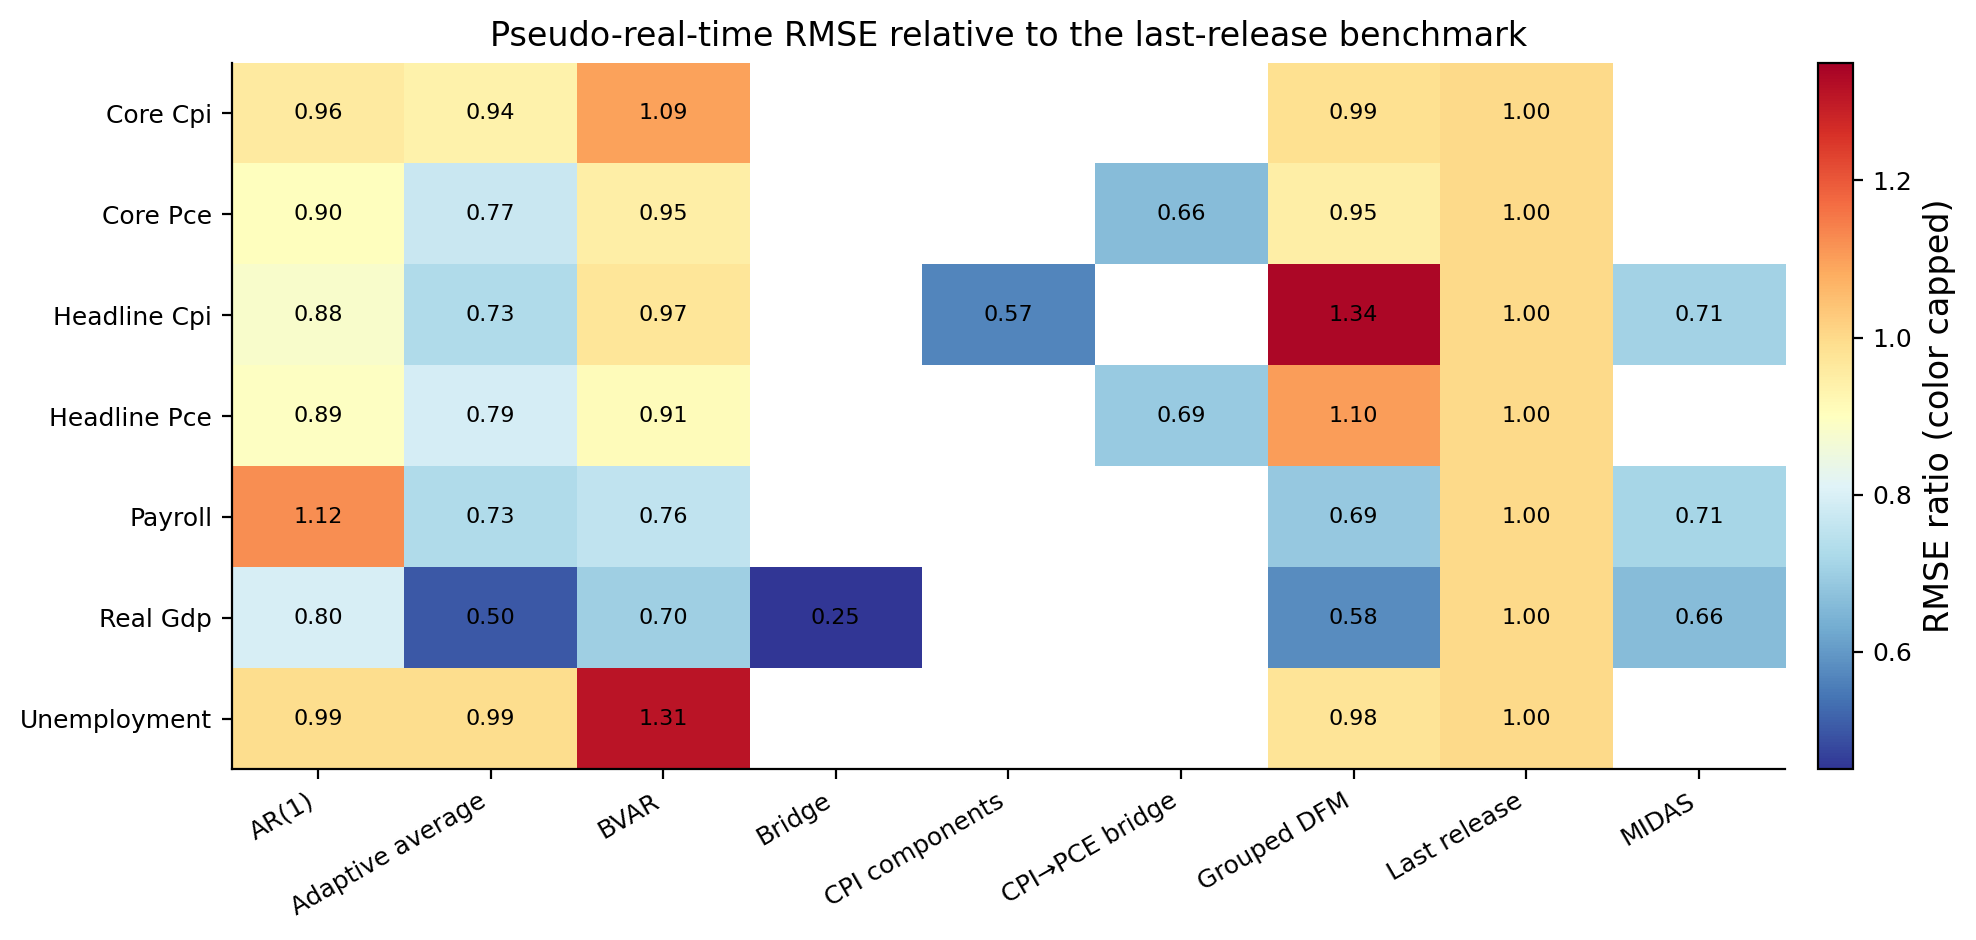

In [34]:
score_frames = []
for model, source, prediction, sigma in [
        ("Last release", baseline_forecasts, "last_release", None),
        ("AR(1)", baseline_forecasts, "ar1", None),
        ("Bridge", bridge_forecasts, "bridge", "bridge_sigma"),
        ("Grouped DFM", dfm_forecasts, "dfm", "dfm_sigma"),
        ("MIDAS", midas_forecasts, "midas", "midas_sigma"),
        ("CPI components", component_cpi_forecasts, "component_cpi", "component_cpi_sigma"),
        ("CPI→PCE bridge", pce_bridge_forecasts, "pce_bridge", "pce_bridge_sigma"),
        ("BVAR", bvar_forecasts, "bvar", "bvar_sigma"),
        ("Adaptive average", dma_forecasts, "dma", "dma_sigma")]:
    columns = ["target", "observation_date", "release_date", "evaluation_date",
               "horizon", "actual", prediction] + ([sigma] if sigma else [])
    frame = source[columns].rename(columns={prediction: "prediction"}).copy()
    frame["sigma"] = frame[sigma] if sigma else np.nan
    frame["model"] = model
    score_frames.append(frame)
score_frame = pd.concat(score_frames, ignore_index=True).dropna(subset=["prediction"])
score_frame = score_frame[score_frame["release_date"].ge(SCORE_START)].reset_index(drop=True)
score_frame["period"] = np.select(
    [score_frame["release_date"].lt("2020-01-01"),
     score_frame["release_date"].between("2020-01-01", "2021-12-31")],
    ["Pre-COVID", "COVID"], default="Post-COVID")

score_rows = []
for (target, model), sample in score_frame.groupby(["target", "model"]):
    error = sample["prediction"] - sample["actual"]
    density = sample["sigma"].notna()
    score_rows.append({"target": target, "model": model, "observations": len(sample),
                       "RMSE": np.sqrt(np.mean(np.square(error))), "MAE": error.abs().mean(),
                       "bias": error.mean(),
                       "CRPS": gaussian_crps(sample.loc[density, "actual"],
                                              sample.loc[density, "prediction"],
                                              sample.loc[density, "sigma"]).mean()
                       if density.any() else np.nan})
scorecard = pd.DataFrame(score_rows).set_index(["target", "model"])

period_rows = []
for (target, model, period), sample in score_frame.groupby(["target", "model", "period"]):
    error = sample["prediction"] - sample["actual"]
    period_rows.append({"target": target, "model": model, "period": period,
                        "observations": len(sample), "RMSE": np.sqrt(np.mean(np.square(error))),
                        "bias": error.mean()})
period_scorecard = pd.DataFrame(period_rows).set_index(["target", "model", "period"])
display(scorecard, period_scorecard)

rmse_table = scorecard["RMSE"].unstack("model")
relative_rmse = rmse_table.div(rmse_table["Last release"], axis=0)
fig, ax = plt.subplots(figsize=(10, 4.8))
image = ax.imshow(relative_rmse, aspect="auto", cmap="RdYlBu_r", vmin=0.45, vmax=1.35)
ax.set_xticks(np.arange(len(relative_rmse.columns)))
ax.set_xticklabels(relative_rmse.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(len(relative_rmse.index)))
ax.set_yticklabels(relative_rmse.index.str.replace("_", " ").str.title())
for y, target in enumerate(relative_rmse.index):
    for x, model in enumerate(relative_rmse.columns):
        value = relative_rmse.loc[target, model]
        if pd.notna(value):
            ax.text(x, y, f"{value:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Pseudo-real-time RMSE relative to the last-release benchmark")
ax.grid(False)
fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02, label="RMSE ratio (color capped)")
plt.tight_layout()
plt.show()

,,estimate (prev),impact of revisions,impact of news,total impact,estimate (new)
impact date,impacted variable,,,,,
2026-09,real_gdp,1.6996,0.0855,0.1778,0.2633,1.9629


,,update_date,observed,model_forecast,standardized_news,gdp_impact
updated variable,family,,,,,
INDPRO,Output and activity,2026-07,0.1960,-0.0238,0.2199,0.3047
PAYEMS,Labor,2026-07,-1.2977,0.3691,-1.6668,-0.2857
UNRATE,Labor,2026-07,-0.6745,-0.1324,-0.5421,0.0773
CPIAUCSL,Prices,2026-07,2.0590,0.4622,1.5969,0.0722
GS10,Rates and credit,2026-07,0.7264,-0.0061,0.7325,0.0179
HOUST,Housing,2026-07,-0.1750,-0.0111,-0.1639,-0.0096
FEDFUNDS,Rates and credit,2026-07,0.0000,-0.0917,0.0917,0.0020
PERMIT,Housing,2026-07,0.0759,-0.0116,0.0874,-0.0010


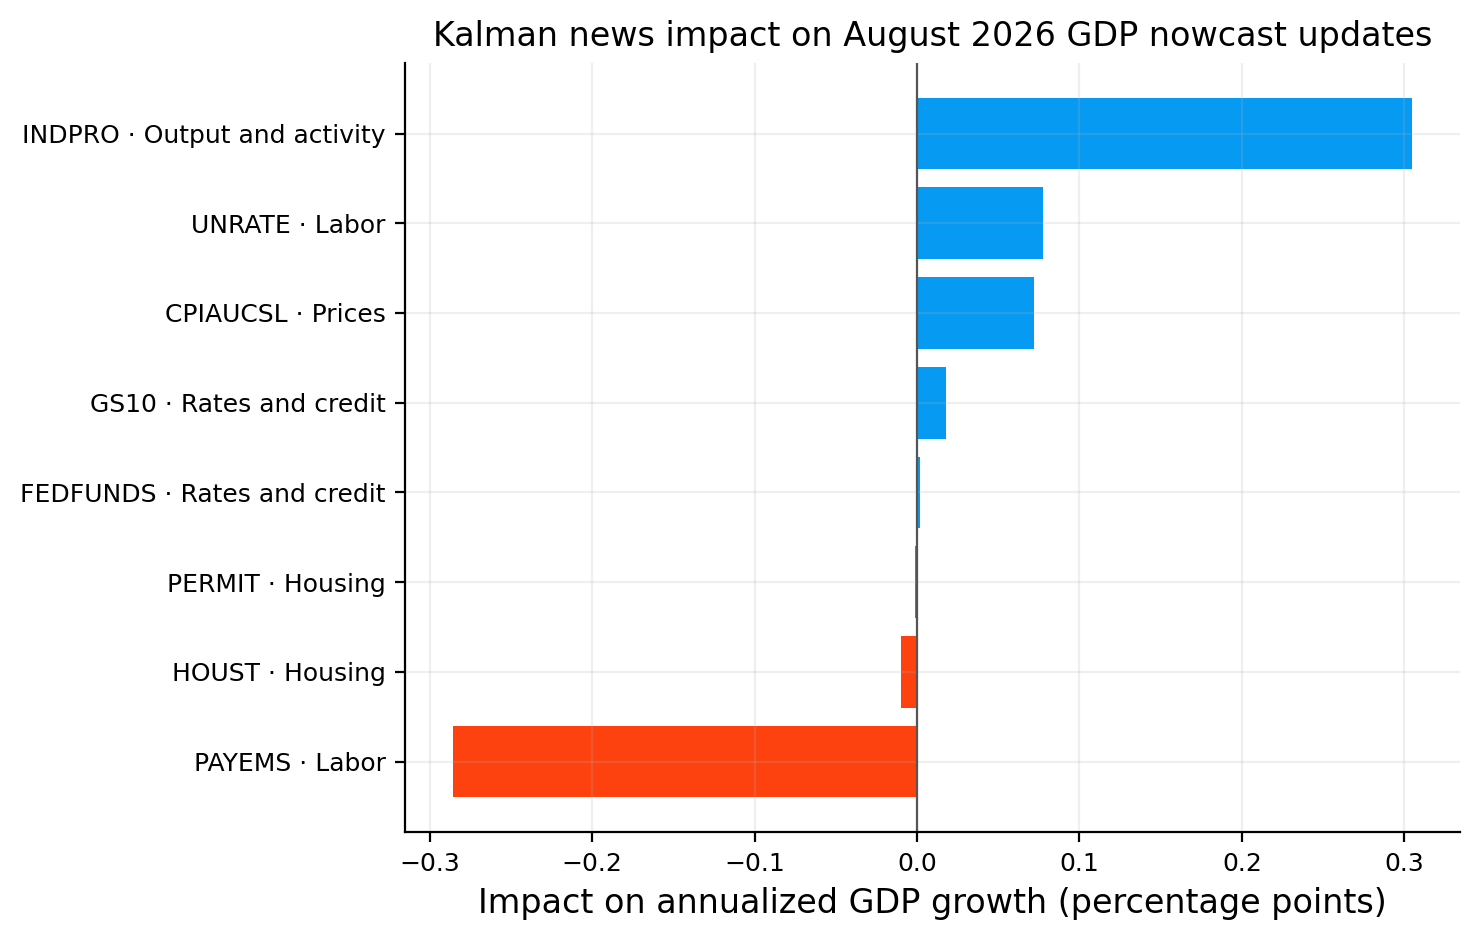

In [35]:
after_date = min(alfred["realtime_start"].max(), evaluation_grid["evaluation_date"].max())
before_date = after_date.to_period("M").start_time
impact_month = after_date.to_period("Q").end_time.to_period("M").to_timestamp()
before_result, news_regime = dfm_model_asof(before_date, impact_month, exact_releases=True)
after_result, _ = dfm_model_asof(after_date, impact_month, exact_releases=True)
state_news = after_result.news(
    before_result, impact_date=impact_month.to_period("M"), impacted_variable="real_gdp",
    comparison_type="previous", original_scale=False)

news_details = state_news.details_by_impact.reset_index()
news_details["family"] = news_details["updated variable"].map(fred_family)
news_details["gdp_impact"] = news_details["impact"] * news_regime["gdp_scale"]
news_details["gdp_weight"] = news_details["weight"] * news_regime["gdp_scale"]
news_ranking = news_details.groupby(["updated variable", "family"]).agg(
    update_date=("update date", "max"), observed=("observed", "last"),
    model_forecast=("forecast (prev)", "last"), standardized_news=("news", "last"),
    gdp_impact=("gdp_impact", "sum")).sort_values("gdp_impact", key=abs, ascending=False)

impact_summary = state_news.impacts.reset_index()
for name in ["estimate (prev)", "impact of revisions", "impact of news",
             "total impact", "estimate (new)"]:
    impact_summary[name] = (impact_summary[name] * news_regime["gdp_scale"]
                            + news_regime["gdp_location"]
                            if name in ["estimate (prev)", "estimate (new)"]
                            else impact_summary[name] * news_regime["gdp_scale"])
display(impact_summary.set_index(["impact date", "impacted variable"]), news_ranking.head(12))

top_news = news_ranking.head(12).sort_values("gdp_impact")
fig, ax = plt.subplots(figsize=(7.5, 4.8))
colors = [palette[0] if value >= 0 else palette[1] for value in top_news["gdp_impact"]]
labels = [f"{series} · {family}" for series, family in top_news.index]
ax.barh(labels, top_news["gdp_impact"], color=colors)
ax.axvline(0, color="#555555", linewidth=0.8)
ax.set_title(f"Kalman news impact on {after_date:%B %Y} GDP nowcast updates")
ax.set_xlabel("Impact on annualized GDP growth (percentage points)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

,value
Rows,299249
First observation,2023-03-29 00:00:00
Latest observation,2026-08-27 00:00:00
Reference windows,26
Median probability mass,1.0000
5th percentile probability mass,0.9998
95th percentile probability mass,1.0002


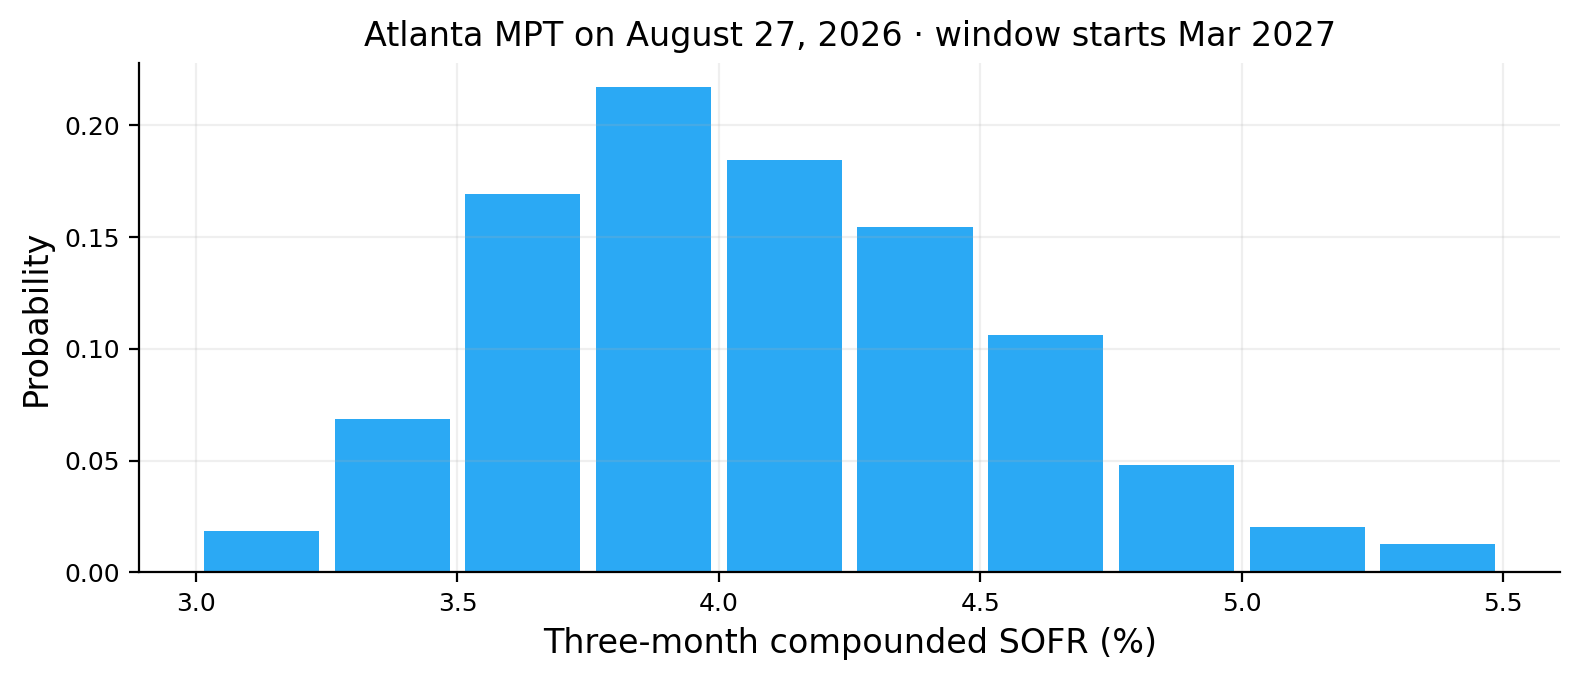

In [36]:
mpt = pd.read_parquet(MPT_PATH)
mpt[["date", "reference_start"]] = mpt[["date", "reference_start"]].apply(pd.to_datetime)
assert mpt["date"].notna().all() and mpt["reference_start"].notna().all()
assert not mpt.duplicated(["date", "reference_start", "field"]).any()

probability_bins = mpt[mpt["field"].str.match(r"Prob: \d+bps - \d+bps")].copy()
bounds = probability_bins["field"].str.extract(r"Prob: (\d+)bps - (\d+)bps").astype(float)
probability_bins["rate"] = bounds.mean(axis=1) / 100
probability_bins["probability"] = probability_bins["value"] / 100
probability_mass = probability_bins.groupby(["date", "reference_start"])["probability"].sum()
assert probability_mass.median() > 0.95

def mpt_window_end(reference_start):
    month = pd.Timestamp(reference_start) + pd.DateOffset(months=3)
    first = pd.Timestamp(month.year, month.month, 1)
    return pd.date_range(first, first + pd.offsets.MonthEnd(0), freq="W-WED")[2]

sofr = high_frequency_wide["SOFR"].dropna()
dff = high_frequency_wide["DFF"].dropna()

def sofr_business_days(start, end):
    known = sofr.index[(sofr.index >= start) & (sofr.index < end)]
    future_start = max(pd.Timestamp(start), sofr.index.max() + pd.offsets.BDay(1))
    future = pd.bdate_range(future_start, pd.Timestamp(end) - pd.Timedelta(days=1))
    return pd.DatetimeIndex(sorted(set(known).union(future)))

def compound_sofr(daily_rates, dates, end):
    next_dates = np.r_[dates[1:].to_numpy(), np.datetime64(end)]
    day_counts = (next_dates - dates.to_numpy()).astype("timedelta64[D]").astype(float)
    accumulation = np.prod(1 + daily_rates * day_counts / 36_000, axis=1)
    return (accumulation - 1) * 36_000 / day_counts.sum()

mpt_audit = pd.DataFrame({
    "value": [len(mpt), mpt["date"].min(), mpt["date"].max(),
              mpt["reference_start"].nunique(), probability_mass.median(),
              probability_mass.quantile(0.05), probability_mass.quantile(0.95)]},
    index=["Rows", "First observation", "Latest observation", "Reference windows",
           "Median probability mass", "5th percentile probability mass",
           "95th percentile probability mass"])
display(mpt_audit)

latest_mpt_date = probability_bins["date"].max()
comparable_bins = probability_bins[probability_bins["date"].eq(latest_mpt_date)
                                   & probability_bins["reference_start"].le(
                                       latest_mpt_date + pd.DateOffset(months=9))]
latest_reference = comparable_bins.groupby("reference_start").size().idxmax()
latest_distribution = probability_bins[probability_bins["date"].eq(latest_mpt_date)
                                       & probability_bins["reference_start"].eq(latest_reference)]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(latest_distribution["rate"], latest_distribution["probability"], width=0.22,
       color=palette[0], alpha=0.85)
ax.set_title(f"Atlanta MPT on {latest_mpt_date:%B %d, %Y} · window starts {latest_reference:%b %Y}")
ax.set_xlabel("Three-month compounded SOFR (%)")
ax.set_ylabel("Probability")
plt.tight_layout()
plt.show()

,windows,RMSE,MAE,bias
model,,,,
macro,12,0.5682,0.4674,-0.3861
market,12,0.5000,0.4458,-0.4011
last_sofr,12,0.2524,0.1758,0.1049


,observations,mean_gap,gap_mae,mean_wasserstein,macro_dispersion,market_dispersion
lead_group,,,,,,
0–3 months,171,-0.1200,0.5945,0.6766,0.4288,0.0801
4–6 months,174,0.2608,1.1843,1.2264,0.5552,0.1262
7–9 months,151,0.1046,1.5658,1.5989,0.6360,0.2336


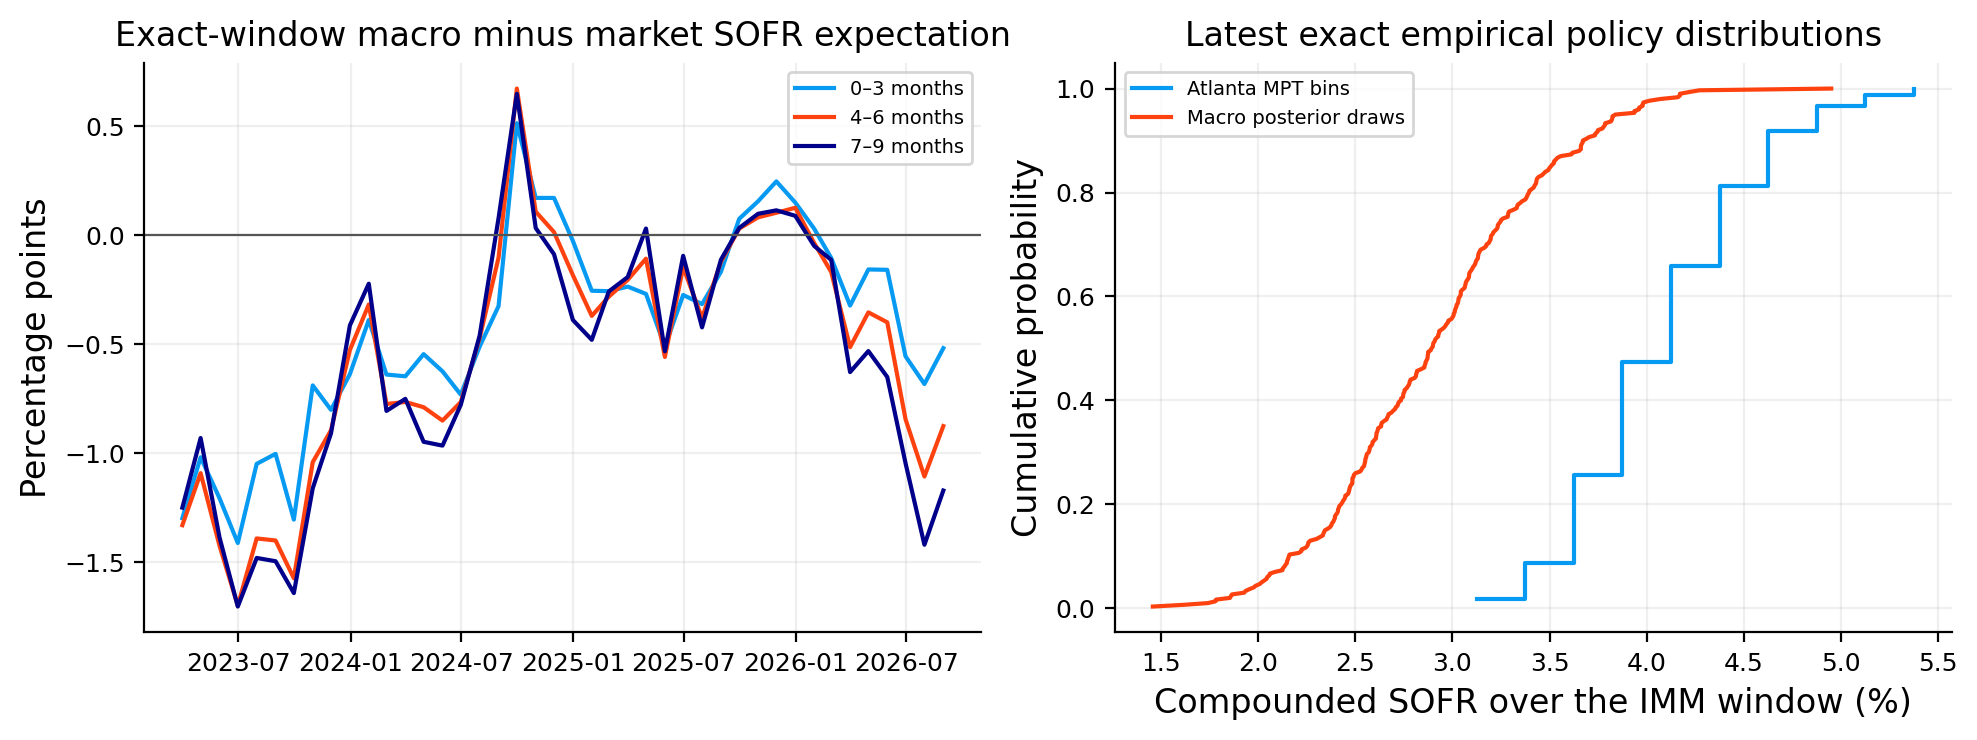

In [37]:
sofr_policy_cache = {}

def policy_paths(as_of):
    date = pd.Timestamp(as_of).normalize()
    if date not in sofr_policy_cache:
        fitted, _, monthly, _ = fitted_bvar_asof(date)
        paths = posterior_paths(fitted, steps=18, draws=BVAR_DRAWS)
        sofr_policy_cache[date] = fitted, paths, monthly
    return sofr_policy_cache[date]

def sofr_window_draws(as_of, reference_start):
    date = pd.Timestamp(as_of)
    start = pd.Timestamp(reference_start)
    end = mpt_window_end(start)
    fitted, paths, monthly = policy_paths(date)
    policy_index = fitted["columns"].index("policy")
    basis_history = pd.concat([sofr.rename("sofr"), dff.rename("dff")], axis=1,
                              sort=False).loc[:date].dropna()
    basis = (basis_history["sofr"] - basis_history["dff"]).tail(60).median()
    dates = sofr_business_days(start, end)
    daily = []
    for day in dates:
        if day <= date and day in sofr.index:
            daily.append(np.full(BVAR_DRAWS, sofr.loc[day]))
        else:
            step = max(1, (day.to_period("M") - monthly.index.max().to_period("M")).n)
            daily.append(paths[:, min(step, paths.shape[1]) - 1, policy_index] + basis)
    return compound_sofr(np.column_stack(daily), dates, end)

month_end_bins = probability_bins.sort_values("date").groupby(
    [probability_bins["date"].dt.to_period("M"), "reference_start", "field"]).tail(1)
monthly_pairs = month_end_bins[["date", "reference_start"]].drop_duplicates().sort_values(
    ["date", "reference_start"])
monthly_pairs = monthly_pairs[monthly_pairs["reference_start"].le(
    monthly_pairs["date"] + pd.DateOffset(months=9))]

policy_gap_rows = []
for row in monthly_pairs.itertuples(index=False):
    market = month_end_bins[month_end_bins["date"].eq(row.date)
                            & month_end_bins["reference_start"].eq(row.reference_start)]
    probability = market["probability"].to_numpy(copy=True)
    probability /= probability.sum()
    market_rates = market["rate"].to_numpy()
    draws = sofr_window_draws(row.date, row.reference_start)
    market_mean = np.average(market_rates, weights=probability)
    market_sigma = np.sqrt(np.average(np.square(market_rates - market_mean), weights=probability))
    lead = max(0, round((row.reference_start - row.date).days / 30.4375))
    policy_gap_rows.append({"date": row.date, "reference_start": row.reference_start,
                            "reference_end": mpt_window_end(row.reference_start),
                            "lead_months": lead, "macro_mean": draws.mean(),
                            "macro_sigma": draws.std(ddof=1), "market_mean": market_mean,
                            "market_sigma": market_sigma, "macro_market_gap": draws.mean() - market_mean,
                            "wasserstein": wasserstein_distance(
                                draws, market_rates, v_weights=probability)})
policy_gap = pd.DataFrame(policy_gap_rows)
policy_gap["lead_group"] = pd.cut(policy_gap["lead_months"], [-1, 3, 6, 9],
                                  labels=["0–3 months", "4–6 months", "7–9 months"])
policy_gap_summary = policy_gap.groupby("lead_group", observed=False).agg(
    observations=("date", "size"), mean_gap=("macro_market_gap", "mean"),
    gap_mae=("macro_market_gap", lambda values: values.abs().mean()),
    mean_wasserstein=("wasserstein", "mean"),
    macro_dispersion=("macro_sigma", "mean"), market_dispersion=("market_sigma", "mean"))

def realized_compounded_sofr(reference_start):
    start = pd.Timestamp(reference_start)
    end = mpt_window_end(start)
    if end > sofr.index.max():
        return np.nan
    dates = sofr_business_days(start, end)
    values = sofr.reindex(dates)
    return compound_sofr(values.to_numpy()[None, :], dates, end)[0] if values.notna().all() else np.nan

policy_score_rows = []
for reference_start, available in month_end_bins.groupby("reference_start"):
    actual = realized_compounded_sofr(reference_start)
    if not np.isfinite(actual):
        continue
    eligible = available[available["date"].le(reference_start - pd.Timedelta(days=30))]
    if eligible.empty:
        continue
    origin = eligible["date"].max()
    market = available[available["date"].eq(origin)]
    probability = market["probability"].to_numpy(copy=True)
    probability /= probability.sum()
    policy_score_rows.append({"reference_start": reference_start, "origin": origin,
                              "actual": actual,
                              "macro": sofr_window_draws(origin, reference_start).mean(),
                              "market": np.average(market["rate"], weights=probability),
                              "last_sofr": sofr.loc[:origin].iloc[-1]})
policy_score_frame = pd.DataFrame(policy_score_rows)
policy_power_rows = []
for model_name in ["macro", "market", "last_sofr"]:
    error = policy_score_frame[model_name] - policy_score_frame["actual"]
    policy_power_rows.append({"model": model_name, "windows": len(error),
                              "RMSE": np.sqrt(np.mean(np.square(error))),
                              "MAE": error.abs().mean(), "bias": error.mean()})
policy_power = pd.DataFrame(policy_power_rows).set_index("model")
display(policy_power, policy_gap_summary)

latest_gap = policy_gap.sort_values(["date", "reference_start"]).iloc[-1]
latest_market = month_end_bins[month_end_bins["date"].eq(latest_gap["date"])
                               & month_end_bins["reference_start"].eq(latest_gap["reference_start"])]
latest_probability = latest_market["probability"].to_numpy(copy=True)
latest_probability /= latest_probability.sum()
latest_draws = np.sort(sofr_window_draws(latest_gap["date"], latest_gap["reference_start"]))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for lead_group, sample in policy_gap.groupby("lead_group", observed=False):
    monthly_gap = sample.set_index("date")["macro_market_gap"].resample("ME").last()
    axes[0].plot(monthly_gap.index, monthly_gap, label=str(lead_group))
axes[0].axhline(0, color="#555555", linewidth=0.8)
axes[0].set_title("Exact-window macro minus market SOFR expectation")
axes[0].set_xlabel("")
axes[0].set_ylabel("Percentage points")
axes[0].legend()
market_order = np.argsort(latest_market["rate"].to_numpy())
market_rates = latest_market["rate"].to_numpy()[market_order]
market_cdf = np.cumsum(latest_probability[market_order])
axes[1].step(market_rates, market_cdf, where="post", label="Atlanta MPT bins")
axes[1].plot(latest_draws, (np.arange(len(latest_draws)) + 1) / len(latest_draws),
             label="Macro posterior draws")
axes[1].set_title("Latest exact empirical policy distributions")
axes[1].set_xlabel("Compounded SOFR over the IMM window (%)")
axes[1].set_ylabel("Cumulative probability")
axes[1].legend()
plt.tight_layout()
plt.show()

events  beta_bp_per_sigma  robust_se  p_value  adjusted_r2                                       event_window
release    driver       maturity                                                                                                               
CPI        headline     2Y           119             2.0435     0.5854   0.0005       0.0788  close-to-close; release bundles and other same...
                        5Y           119             2.0893     0.5984   0.0005       0.0806  close-to-close; release bundles and other same...
                        10Y          119             1.3320     0.5128   0.0094       0.0408  close-to-close; release bundles and other same...
                        2s10s        119            -0.7115     0.4517   0.1153       0.0231  close-to-close; release bundles and other same...
GDP        headline     2Y            67            -0.5281     0.4713   0.2625       0.0009  close-to-close; release bundles and other same...
                        5Y            67            -0.6125     0.5304   0.2482      -0.0010  close-to-close; release bundles and other same...
                        10Y           67            -0.4784     0.5130   0.3510      -0.0073  close-to-close; release bundles and other same...
                        2s10s         67             0.0497     0.3932   0.8994      -0.0152  close-to-close; release bundles and other same...
Employment payroll      2Y           118             0.1034     0.1401   0.4605      -0.0138  close-to-close; release bundles and other same...
           unemployment 2Y           118            -0.3678     0.4260   0.3879      -0.0138  close-to-close; release bundles and other same...
           wages        2Y           118             0.2844     0.6412   0.6574      -0.0138  close-to-close; release bundles and other same...
           revision     2Y           118             0.7367     0.5298   0.1643      -0.0138  close-to-close; release bundles and other same...
           payroll      5Y           118             0.1930     0.1486   0.1940      -0.0032  close-to-close; release bundles and other same...
           unemployment 5Y           118            -0.6556     0.4537   0.1484      -0.0032  close-to-close; release bundles and other same...
           wages        5Y           118             0.6596     0.6076   0.2777      -0.0032  close-to-close; release bundles and other same...
           revision     5Y           118             0.7518     0.4193   0.0730      -0.0032  close-to-close; release bundles and other same...
           payroll      10Y          118             0.2411     0.1572   0.1252       0.0052  close-to-close; release bundles and other same...
           unemployment 10Y          118            -0.8322     0.4819   0.0842       0.0052  close-to-close; release bundles and other same...
           wages        10Y          118             0.6643     0.5559   0.2320       0.0052  close-to-close; release bundles and other same...
           revision     10Y          118             0.6273     0.3243   0.0531       0.0052  close-to-close; release bundles and other same...
           payroll      2s10s        118             0.1377     0.0978   0.1590      -0.0060  close-to-close; release bundles and other same...
           unemployment 2s10s        118            -0.4644     0.2997   0.1213      -0.0060  close-to-close; release bundles and other same...
           wages        2s10s        118             0.3800     0.3385   0.2617      -0.0060  close-to-close; release bundles and other same...
           revision     2s10s        118            -0.1094     0.3243   0.7359      -0.0060  close-to-close; release bundles and other same...

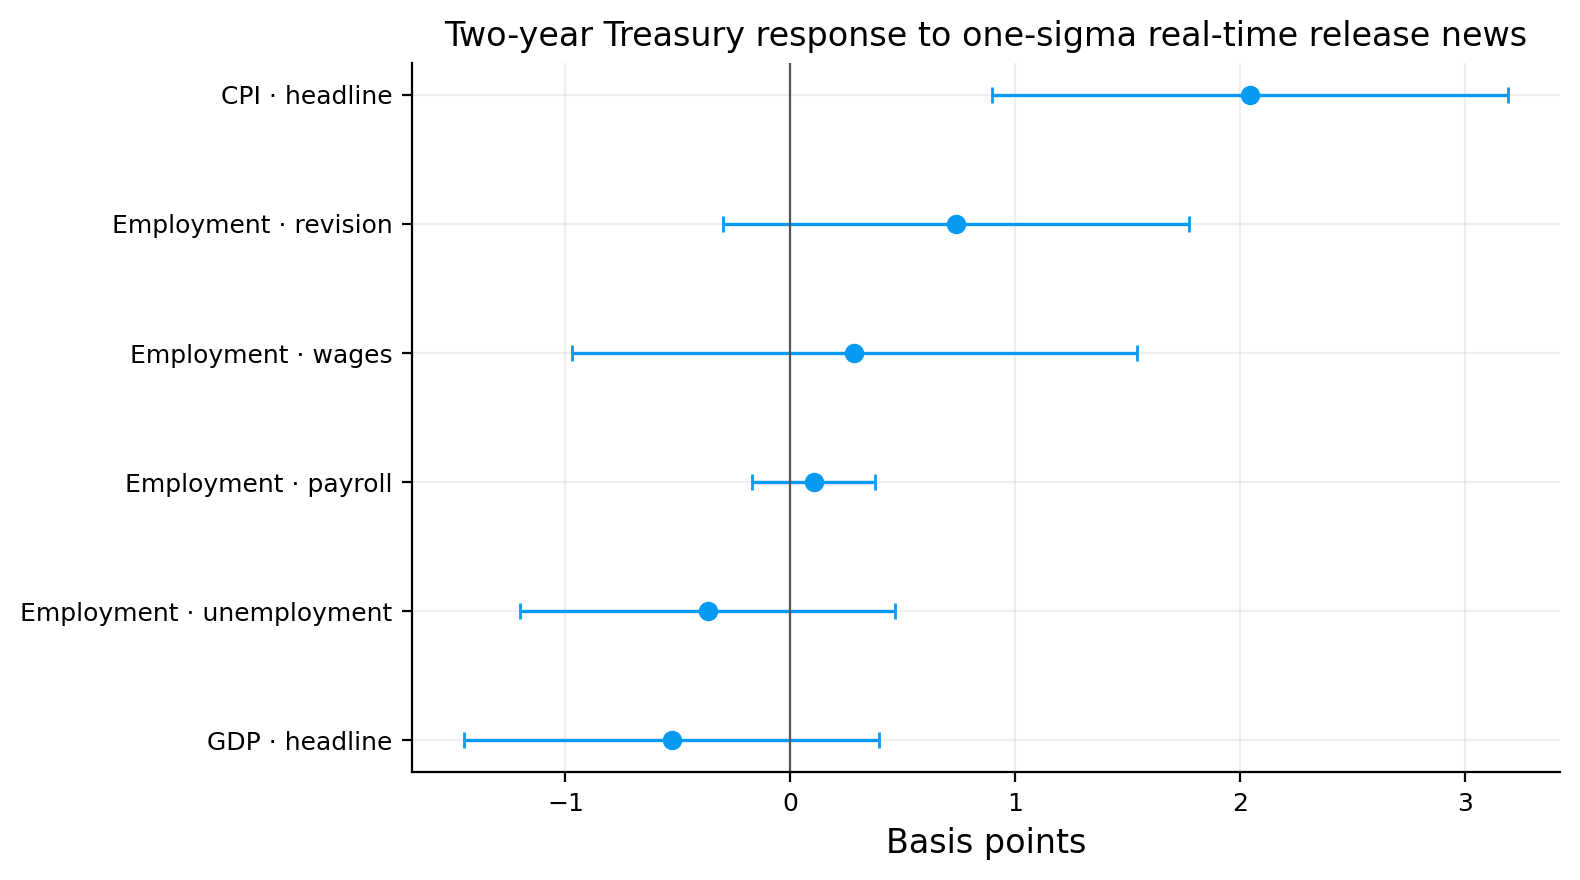

In [38]:
treasury = load_par_yields_csv(TREASURY_PATH)
treasury = treasury[["2Y", "5Y", "10Y"]].dropna().sort_index()
treasury["2s10s"] = treasury["10Y"] - treasury["2Y"]

def treasury_reaction(release_date):
    position = treasury.index.searchsorted(pd.Timestamp(release_date))
    if position == 0 or position >= len(treasury):
        return pd.Series(dtype=float)
    return 10_000 * (treasury.iloc[position] - treasury.iloc[position - 1])

event_rows = []
for release, source, prediction in [
        ("CPI", component_cpi_forecasts, "component_cpi"),
        ("GDP", bridge_forecasts, "bridge")]:
    forecasts = source[source["horizon"].eq(1)].sort_values("release_date").copy()
    forecasts["forecast_error"] = forecasts["actual"] - forecasts[prediction]
    error_scale = forecasts["forecast_error"].expanding(min_periods=24).std(ddof=1).shift(1)
    forecasts["model_news"] = (forecasts["forecast_error"] / error_scale).clip(-5, 5)
    for row in forecasts.itertuples():
        reaction = treasury_reaction(row.release_date)
        if reaction.empty:
            continue
        event_rows.append({"release": release, "driver": "headline",
                           "observation_date": row.observation_date,
                           "release_date": row.release_date, "model_news": row.model_news,
                           **reaction.to_dict()})
simple_events = pd.DataFrame(event_rows)

employment = midas_forecasts[midas_forecasts["target"].eq("payroll")
                             & midas_forecasts["horizon"].eq(1)][
    ["observation_date", "release_date", "actual", "midas"]].rename(
        columns={"actual": "payroll_actual", "midas": "payroll_forecast"})
unemployment = dfm_forecasts[dfm_forecasts["target"].eq("unemployment")
                             & dfm_forecasts["horizon"].eq(1)][
    ["observation_date", "release_date", "actual", "dfm"]].rename(
        columns={"actual": "unemployment_actual", "dfm": "unemployment_forecast"})

wages = alfred_first_growth("AWHAETP", "wage").sort_values("observation_date")
wage_forecasts = []
for row in wages.itertuples():
    history = wages[wages["release_date"].lt(row.release_date)]["first"].dropna()
    if len(history) >= 24:
        design = pd.concat([history.rename("y"), history.shift(1).rename("lag")], axis=1).dropna()
        model = LinearRegression().fit(design[["lag"]], design["y"])
        forecast = float(model.predict(pd.DataFrame({"lag": [history.iloc[-1]]}))[0])
    else:
        forecast = history.tail(12).mean()
    wage_forecasts.append(forecast)
wages["wage_forecast"] = wage_forecasts
wages = wages.rename(columns={"first": "wage_actual"})

employment = employment.merge(unemployment, on=["observation_date", "release_date"]).merge(
    wages[["observation_date", "release_date", "wage_actual", "wage_forecast"]],
    on=["observation_date", "release_date"]).sort_values("release_date")
revisions = []
for row in employment.itertuples():
    previous_month = row.observation_date - pd.DateOffset(months=1)
    before = alfred_asof(row.release_date - pd.Timedelta(days=1), ("PAYEMS",)).set_index(
        "observation_date")["value"]
    after = alfred_asof(row.release_date, ("PAYEMS",)).set_index("observation_date")["value"]
    revisions.append(after.get(previous_month, np.nan) - before.get(previous_month, np.nan))
employment["payroll_revision"] = revisions

surprises = {"payroll": employment["payroll_actual"] - employment["payroll_forecast"],
             "unemployment": -(employment["unemployment_actual"]
                               - employment["unemployment_forecast"]),
             "wages": employment["wage_actual"] - employment["wage_forecast"],
             "revision": employment["payroll_revision"]}
for name, values in surprises.items():
    scale = values.expanding(min_periods=24).std(ddof=1).shift(1)
    employment[f"{name}_news"] = values / scale
for maturity in treasury:
    employment[maturity] = [treasury_reaction(date).get(maturity, np.nan)
                            for date in employment["release_date"]]
employment = employment.dropna(subset=[f"{name}_news" for name in surprises]
                                 + list(treasury.columns))

reaction_rows = []
for release, sample in simple_events.groupby("release"):
    for maturity in treasury:
        sample = sample.dropna(subset=[maturity, "model_news"])
        fitted = OLS(sample[maturity], add_constant(sample[["model_news"]])).fit(cov_type="HC1")
        reaction_rows.append({"release": release, "driver": "headline", "maturity": maturity,
                              "events": len(sample), "beta_bp_per_sigma": fitted.params["model_news"],
                              "robust_se": fitted.bse["model_news"],
                              "p_value": fitted.pvalues["model_news"],
                              "adjusted_r2": fitted.rsquared_adj})
for maturity in treasury:
    features = [f"{name}_news" for name in surprises]
    fitted = OLS(employment[maturity], add_constant(employment[features])).fit(cov_type="HC1")
    for feature in features:
        reaction_rows.append({"release": "Employment", "driver": feature.replace("_news", ""),
                              "maturity": maturity, "events": len(employment),
                              "beta_bp_per_sigma": fitted.params[feature],
                              "robust_se": fitted.bse[feature],
                              "p_value": fitted.pvalues[feature],
                              "adjusted_r2": fitted.rsquared_adj})
reaction_table = pd.DataFrame(reaction_rows).set_index(["release", "driver", "maturity"])
reaction_table["event_window"] = "close-to-close; release bundles and other same-day news remain"
display(reaction_table)

two_year = reaction_table.xs("2Y", level="maturity").reset_index().sort_values(
    "beta_bp_per_sigma")
fig, ax = plt.subplots(figsize=(8, 4.5))
positions = np.arange(len(two_year))
ax.errorbar(two_year["beta_bp_per_sigma"], positions,
            xerr=1.96 * two_year["robust_se"], fmt="o", capsize=3, linewidth=1.2)
ax.axvline(0, color="#555555", linewidth=0.8)
ax.set_yticks(positions)
ax.set_yticklabels(two_year["release"] + " · " + two_year["driver"])
ax.set_title("Two-year Treasury response to one-sigma real-time release news")
ax.set_xlabel("Basis points")
ax.set_ylabel("")
plt.tight_layout()
plt.show()